# Interaction — 콘텐츠가 다음 행동으로 이어졌는가

질문 이용이 완료, 결과 확인, 관계 행동과 재방문으로 이어지는지 분석한다.

- 2023년 5월 질문 DB: 질문세트와 투표 기록의 후속 행동
- 2023-07-18~08-10 Hackle: 방문 내 실제 이벤트 경로와 단기 재방문
- 두 데이터는 기간·모집단·계측 방식이 달라 직접 비교하지 않는다.


## 분석 기준

- 질문 상태와 Ping 값은 현재 스냅샷이다.
- 질문세트의 10개 질문조각에 투표 기록이 있으면 완료 대리지표로 정의한다.
- Hackle 사용자 분석은 식별 가능한 비운영 사용자만 포함한다.
- 방문은 30분 무활동 기준으로 구분한다.
- 공식 시간대가 불명확해 원시 시각을 유지한다.
- 관측 결과는 인과효과로 해석하지 않는다.


In [1]:
from pathlib import Path
import json, math, warnings
import numpy as np
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from scipy import stats
from sklearn.cluster import MiniBatchKMeans
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid', font='Malgun Gothic')

ROOT = Path.cwd()
WORK = ROOT / 'analysis' / 'interaction_deep_dive'
OUTPUT = WORK / 'outputs'
FIG = OUTPUT / 'figures'
TABLE = OUTPUT / 'tables'
CACHE = OUTPUT / 'cache'
for p in (OUTPUT, FIG, TABLE, CACHE): p.mkdir(parents=True, exist_ok=True)

from analysis.interaction_deep_dive.interaction_core import build_interaction_caches
cache_paths = build_interaction_caches(force=False)

con = duckdb.connect()
con.execute('PRAGMA threads=8')
con.execute('PRAGMA memory_limit="8GB"')
for name, path in cache_paths.items():
    con.execute(f"CREATE OR REPLACE VIEW {name} AS SELECT * FROM read_parquet('{path.as_posix()}')")

def save_table(df, name):
    path = TABLE / f'{name}.csv'
    df.to_csv(path, index=False, encoding='utf-8-sig')
    return df

def savefig(name):
    path = FIG / f'{name}.png'
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches='tight')
    plt.show()
    return path

COLORS = ['#5B5BD6', '#9B87F5', '#2CB67D', '#FF9F43', '#EF5DA8', '#64748B']
print('준비 완료:', WORK)

[cache] keep hackle_event_core: hackle_event_core.parquet


[cache] keep hackle_visit_core: hackle_visit_core.parquet


[cache] keep hackle_user_daily: hackle_user_daily.parquet


[cache] keep question_set_all: question_set_all.parquet


[cache] keep question_set_may: question_set_may.parquet


[cache] keep question_piece_may: question_piece_may.parquet


[cache] keep vote_may: vote_may.parquet


준비 완료: C:\Users\lucy5\Desktop\team7\analysis\interaction_deep_dive


## 1. 분석 범위와 데이터 품질


In [2]:
scope = con.execute("""
SELECT '5월 질문세트' AS source_name, COUNT(*) AS row_count, COUNT(DISTINCT owner_user_id) AS users,
       MIN(set_created_at) min_at, MAX(set_created_at) max_at FROM question_set_may
UNION ALL
SELECT '5월 질문조각', COUNT(*), COUNT(DISTINCT owner_user_id), MIN(piece_created_at), MAX(piece_created_at) FROM question_piece_may
UNION ALL
SELECT '5월 투표', COUNT(*), COUNT(DISTINCT voter_user_id), MIN(vote_at), MAX(vote_at) FROM vote_may
UNION ALL
SELECT 'Hackle 이벤트', COUNT(*), COUNT(DISTINCT user_id), MIN(event_at), MAX(event_at) FROM hackle_event_core
UNION ALL
SELECT 'Hackle 30분 방문', COUNT(*), COUNT(DISTINCT user_id), MIN(visit_start), MAX(visit_end) FROM hackle_visit_core
""").df()
display(save_table(scope, '00_scope'))

identity = con.execute("""
SELECT identity_status,
       COUNT(*) events,
       COUNT(DISTINCT visit_id) visits,
       COUNT(DISTINCT user_id) identified_users,
       COUNT(*)/SUM(COUNT(*)) OVER() AS event_share
FROM hackle_event_core GROUP BY 1 ORDER BY events DESC
""").df()
display(save_table(identity, '01_hackle_identity_coverage'))

,source_name,row_count,users,min_at,max_at
0,5월 질문세트,143158,4909,2023-05-01 03:40:07,2023-05-31 23:52:46
1,5월 질문조각,1144964,4907,2023-05-01 03:40:07,2023-05-31 23:52:46
2,5월 투표,1104681,4797,2023-05-01 03:37:42,2023-05-31 23:59:57
3,Hackle 이벤트,11441319,140663,2023-07-18 00:00:00,2023-08-10 23:59:59
4,Hackle 30분 방문,896009,140663,2023-07-18 00:00:00,2023-08-10 23:59:59


,identity_status,events,visits,identified_users,event_share
0,IDENTIFIED_SERVICE_USER,7764134,626987,140663,0.6786
1,AMBIGUOUS_NOT_ASSIGNED,3439628,228101,0,0.3006
2,UNMATCHED_OR_NONNUMERIC,203182,25339,0,0.0178
3,MISSING_USER_ID,34375,15582,0,0.0030


In [3]:
qa = con.execute("""
SELECT 'question_set_may' AS object_name, COUNT(*) AS row_count,
       SUM(owner_user_id IS NULL) missing_user,
       SUM(set_created_at IS NULL) missing_time,
       SUM(eligible_set_flag<>1 OR eligible_set_flag IS NULL) ineligible
FROM question_set_may
UNION ALL SELECT 'question_piece_may', COUNT(*), SUM(owner_user_id IS NULL),
       SUM(piece_created_at IS NULL), SUM(eligible_piece_flag<>1 OR eligible_piece_flag IS NULL)
FROM question_piece_may
UNION ALL SELECT 'vote_may', COUNT(*), SUM(voter_user_id IS NULL),
       SUM(vote_at IS NULL), SUM(eligible_vote_flag<>1 OR eligible_vote_flag IS NULL)
FROM vote_may
UNION ALL SELECT 'hackle_event_core', COUNT(*), SUM(user_id IS NULL),
       SUM(event_at IS NULL), SUM(visit_id IS NULL)
FROM hackle_event_core
UNION ALL SELECT 'hackle_visit_core', COUNT(*), SUM(user_id IS NULL),
       SUM(visit_start IS NULL), SUM(visit_id IS NULL)
FROM hackle_visit_core
""").df()
display(save_table(qa, '02_missing_and_eligibility_qa'))

,object_name,row_count,missing_user,missing_time,ineligible
0,question_set_may,143158,0.0000,0.0000,0.0000
1,question_piece_may,1144964,0.0000,0.0000,0.0000
2,vote_may,1104681,0.0000,0.0000,0.0000
3,hackle_event_core,11441319,"3,677,185.0000",0.0000,0.0000
4,hackle_visit_core,896009,"269,022.0000",0.0000,0.0000


## 2. 2023년 5월 질문 행동

5월 질문세트를 기준으로 질문 완료 대리지표와 7일 후속 행동을 확인한다.


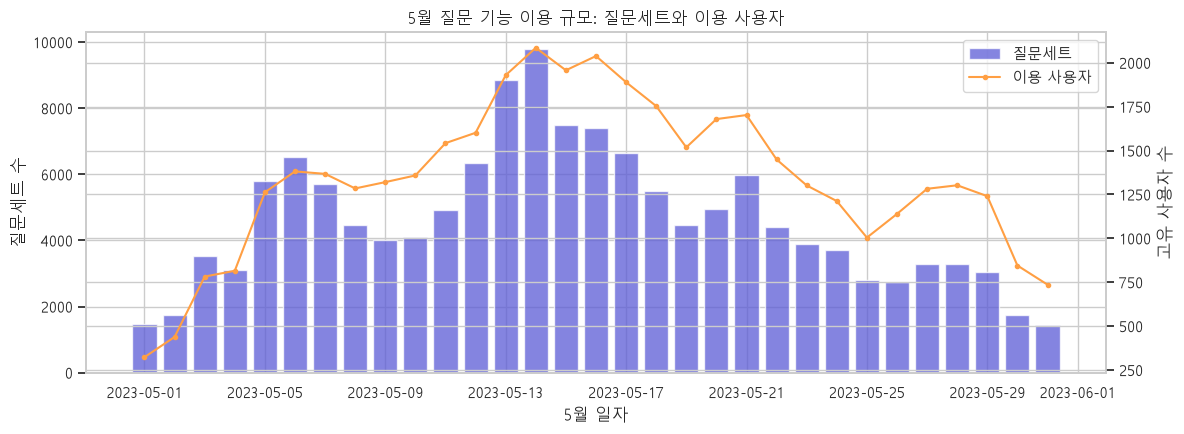

WindowsPath('C:/Users/lucy5/Desktop/team7/analysis/interaction_deep_dive/outputs/figures/10_may_daily_interaction.png')

In [4]:
con.execute("""
CREATE OR REPLACE TEMP VIEW may_set_metrics AS
WITH p AS (
  SELECT question_set_id,
         COUNT(*) AS mapped_pieces,
         SUM(CASE WHEN vote_exists=1 THEN 1 ELSE 0 END) AS voted_pieces,
         SUM(CASE WHEN raw_is_skipped=1 THEN 1 ELSE 0 END) AS skip_history_pieces,
         COUNT(DISTINCT question_position) AS distinct_positions,
         AVG(candidate_count) AS avg_candidate_count,
         MIN(vote_at) AS first_vote_at,
         MAX(vote_at) AS last_vote_at
  FROM question_piece_may
  WHERE eligible_piece_flag=1 AND question_set_id IS NOT NULL
  GROUP BY 1
)
SELECT q.*,
       COALESCE(p.mapped_pieces,0) mapped_pieces,
       COALESCE(p.voted_pieces,0) voted_pieces,
       COALESCE(p.skip_history_pieces,0) skip_history_pieces,
       COALESCE(p.distinct_positions,0) distinct_positions,
       p.avg_candidate_count, p.first_vote_at, p.last_vote_at,
       CASE WHEN COALESCE(p.voted_pieces,0)>0 THEN 1 ELSE 0 END any_vote_flag,
       CASE WHEN COALESCE(p.mapped_pieces,0)>=10 AND COALESCE(p.voted_pieces,0)>=10 THEN 1 ELSE 0 END completed_10_proxy,
       COALESCE(p.voted_pieces,0)/NULLIF(COALESCE(p.mapped_pieces,0),0) vote_coverage
FROM question_set_may q LEFT JOIN p USING(question_set_id)
WHERE q.eligible_set_flag=1
""")

daily = con.execute("""
SELECT CAST(set_created_at AS DATE) AS activity_day,
       COUNT(*) question_sets,
       COUNT(DISTINCT owner_user_id) users,
       SUM(voted_pieces) vote_records,
       AVG(completed_10_proxy) complete10_rate
FROM may_set_metrics GROUP BY 1 ORDER BY 1
""").df()
save_table(daily, '10_may_daily_interaction')
fig, ax1 = plt.subplots(figsize=(12,4.5))
ax1.bar(daily.activity_day, daily.question_sets, color=COLORS[0], alpha=.75, label='질문세트')
ax1.set_ylabel('질문세트 수'); ax1.set_xlabel('5월 일자')
ax2 = ax1.twinx()
ax2.plot(daily.activity_day, daily.users, color=COLORS[3], marker='o', ms=3, label='이용 사용자')
ax2.set_ylabel('고유 사용자 수')
ax1.set_title('5월 질문 기능 이용 규모: 질문세트와 이용 사용자')
lines, labels = ax1.get_legend_handles_labels(); lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines+lines2, labels+labels2, loc='upper right')
savefig('10_may_daily_interaction')

### 2.1 질문세트와 투표 기록


,stage_order,stage,sets,share_of_created,conditional_rate
0,1,생성된 질문세트,"143,158.0000",1.0000,1.0000
1,2,질문조각 연결,"141,717.0000",0.9899,0.9899
2,3,1개 이상 투표 기록,"139,211.0000",0.9724,0.9823
3,4,10개 투표 완료 대리,"47,464.0000",0.3315,0.3410


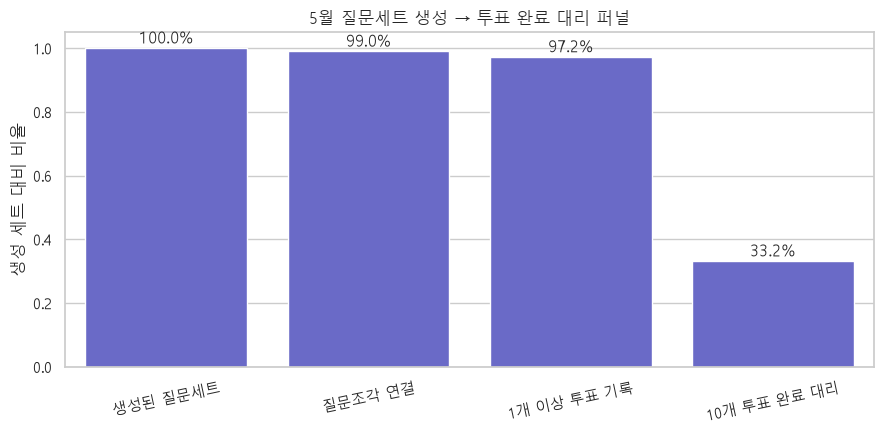

WindowsPath('C:/Users/lucy5/Desktop/team7/analysis/interaction_deep_dive/outputs/figures/11_may_question_set_funnel.png')

In [5]:
funnel = con.execute("""
WITH b AS (SELECT * FROM may_set_metrics)
SELECT * FROM (VALUES
  (1, '생성된 질문세트', (SELECT COUNT(*) FROM b)),
  (2, '질문조각 연결', (SELECT SUM(mapped_pieces>0) FROM b)),
  (3, '1개 이상 투표 기록', (SELECT SUM(any_vote_flag) FROM b)),
  (4, '10개 투표 완료 대리', (SELECT SUM(completed_10_proxy) FROM b))
) t(stage_order, stage, sets)
""").df()
funnel['share_of_created'] = funnel.sets / funnel.sets.iloc[0]
funnel['conditional_rate'] = funnel.sets / funnel.sets.shift(1)
funnel.loc[0, 'conditional_rate'] = 1.0
display(save_table(funnel, '11_may_question_set_funnel'))
plt.figure(figsize=(9,4.5))
ax=sns.barplot(data=funnel, x='stage', y='share_of_created', color=COLORS[0])
ax.set_ylim(0,1.05); ax.set_ylabel('생성 세트 대비 비율'); ax.set_xlabel('')
ax.set_title('5월 질문세트 생성 → 투표 완료 대리 퍼널')
for p,v in zip(ax.patches, funnel.share_of_created): ax.text(p.get_x()+p.get_width()/2,v+.015,f'{v:.1%}',ha='center')
plt.xticks(rotation=12)
savefig('11_may_question_set_funnel')

,question_position,available_pieces,voted_pieces,vote_record_rate,skip_history_rate,users
0,1,116886,"114,302.0000",0.9779,0.0017,4894
1,2,115965,"113,274.0000",0.9768,0.0014,4892
2,3,115355,"112,604.0000",0.9762,0.0010,4894
3,4,114936,"112,125.0000",0.9755,0.0009,4900
4,5,114604,"111,755.0000",0.9751,0.0005,4897
5,6,113972,"111,083.0000",0.9747,0.0004,4896
6,7,113945,"111,026.0000",0.9744,0.0003,4897
7,8,113134,"110,201.0000",0.9741,0.0001,4894
8,9,112543,"109,594.0000",0.9738,0.0001,4893
9,10,113624,"110,672.0000",0.9740,0.0002,4899


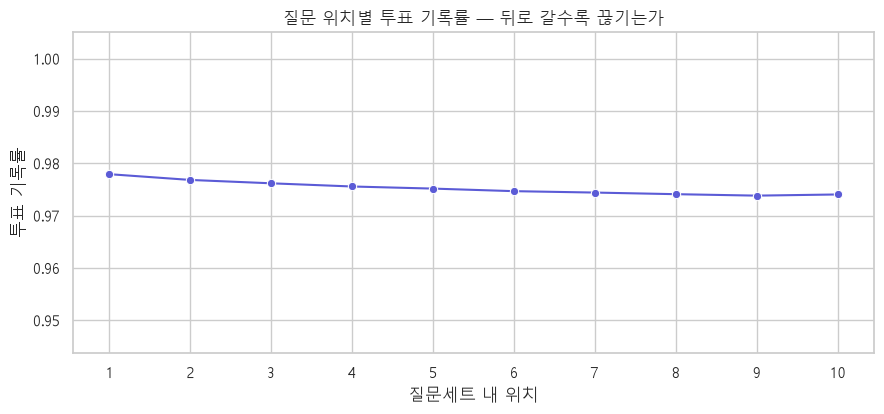

WindowsPath('C:/Users/lucy5/Desktop/team7/analysis/interaction_deep_dive/outputs/figures/12_may_position_vote_rate.png')

In [6]:
position = con.execute("""
SELECT question_position,
       COUNT(*) available_pieces,
       SUM(vote_exists=1) voted_pieces,
       AVG(CAST(vote_exists=1 AS INTEGER)) vote_record_rate,
       AVG(CAST(raw_is_skipped=1 AS INTEGER)) skip_history_rate,
       COUNT(DISTINCT owner_user_id) users
FROM question_piece_may
WHERE eligible_piece_flag=1 AND question_position BETWEEN 1 AND 10
GROUP BY 1 ORDER BY 1
""").df()
display(save_table(position, '12_may_position_behavior'))
plt.figure(figsize=(9,4.3))
ax=sns.lineplot(data=position, x='question_position', y='vote_record_rate', marker='o', color=COLORS[0])
ax.set_ylim(max(0,position.vote_record_rate.min()-.03),1.005)
ax.set_xlabel('질문세트 내 위치'); ax.set_ylabel('투표 기록률')
ax.set_title('질문 위치별 투표 기록률 — 뒤로 갈수록 끊기는가')
ax.set_xticks(range(1,11))
savefig('12_may_position_vote_rate')

### 2.2 다음 질문세트 생성


,index,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
0,may_sets,"4,909.0000",29.1624,23.9556,1.0000,12.0000,23.0000,39.0000,60.0000,76.0000,112.0000,209.0000
1,voted_pieces,"4,909.0000",227.4671,206.3114,0.0000,81.0000,173.0000,315.0000,491.0000,637.2000,972.8400,"1,683.0000"
2,complete10_rate,"4,909.0000",0.2842,0.2709,0.0000,0.0204,0.2222,0.5000,0.7059,0.8000,0.9000,1.0000


,구분,users,share
0,5월 질문세트 1회,127,0.0259
1,5월 질문세트 2~4회,308,0.0627
2,5월 질문세트 5회 이상,4474,0.9114


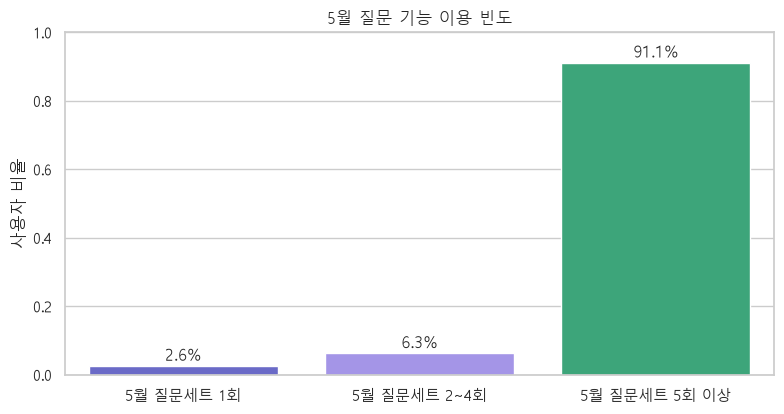

WindowsPath('C:/Users/lucy5/Desktop/team7/analysis/interaction_deep_dive/outputs/figures/13_may_user_frequency_groups.png')

In [7]:
user_usage = con.execute("""
SELECT owner_user_id,
       COUNT(*) may_sets,
       SUM(voted_pieces) voted_pieces,
       AVG(completed_10_proxy) complete10_rate,
       MIN(set_created_at) first_may_set_at,
       MAX(set_created_at) last_may_set_at
FROM may_set_metrics GROUP BY 1
""").df()
usage_summary = user_usage[['may_sets','voted_pieces','complete10_rate']].describe(percentiles=[.25,.5,.75,.9,.95,.99]).T.reset_index()
display(save_table(usage_summary, '13_may_user_usage_summary'))
one_shot = pd.DataFrame({
    '구분':['5월 질문세트 1회','5월 질문세트 2~4회','5월 질문세트 5회 이상'],
    'users':[(user_usage.may_sets==1).sum(), user_usage.may_sets.between(2,4).sum(), (user_usage.may_sets>=5).sum()]
})
one_shot['share']=one_shot.users/one_shot.users.sum()
display(save_table(one_shot, '14_may_user_frequency_groups'))
plt.figure(figsize=(8,4.3))
ax=sns.barplot(data=one_shot,x='구분',y='share',palette=COLORS[:3])
ax.set_ylim(0,1); ax.set_ylabel('사용자 비율'); ax.set_xlabel('')
ax.set_title('5월 질문 기능 이용 빈도')
for p,v in zip(ax.patches,one_shot.share): ax.text(p.get_x()+p.get_width()/2,v+.015,f'{v:.1%}',ha='center')
savefig('13_may_user_frequency_groups')

,window,next_set_rate
0,24시간,0.9338
1,72시간,0.9644
2,7일,0.9703


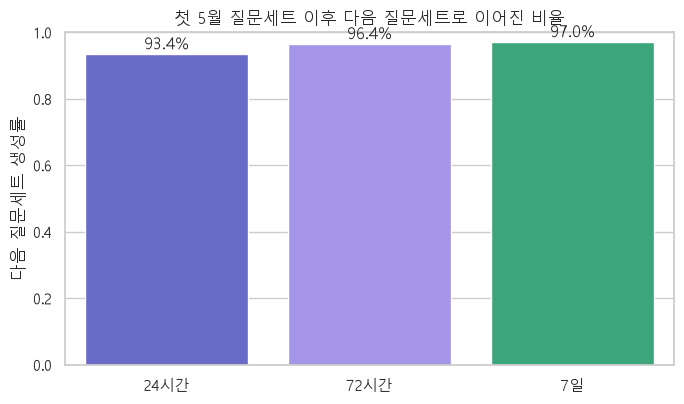

WindowsPath('C:/Users/lucy5/Desktop/team7/analysis/interaction_deep_dive/outputs/figures/14_may_next_question_set_rates.png')

In [8]:
followup = con.execute("""
WITH seq AS (
  SELECT owner_user_id, question_set_id, set_created_at,
         LEAD(set_created_at) OVER(PARTITION BY owner_user_id ORDER BY set_created_at, question_set_id) next_set_at
  FROM question_set_all
  WHERE eligible_set_flag=1 AND owner_user_id IS NOT NULL AND set_created_at IS NOT NULL
), first_may AS (
  SELECT m.*, ROW_NUMBER() OVER(PARTITION BY owner_user_id ORDER BY set_created_at, question_set_id) rn
  FROM may_set_metrics m
)
SELECT f.owner_user_id, f.question_set_id, f.set_created_at, f.mapped_pieces, f.voted_pieces,
       f.vote_coverage, f.skip_history_pieces, f.avg_candidate_count, f.completed_10_proxy,
       s.next_set_at,
       date_diff('second', f.set_created_at, s.next_set_at)/3600.0 AS hours_to_next,
       CASE WHEN s.next_set_at<=f.set_created_at+INTERVAL 24 HOUR THEN 1 ELSE 0 END next_24h,
       CASE WHEN s.next_set_at<=f.set_created_at+INTERVAL 72 HOUR THEN 1 ELSE 0 END next_72h,
       CASE WHEN s.next_set_at<=f.set_created_at+INTERVAL 7 DAY THEN 1 ELSE 0 END next_7d
FROM first_may f JOIN seq s USING(owner_user_id, question_set_id, set_created_at)
WHERE f.rn=1
""").df()
rates = pd.DataFrame({'window':['24시간','72시간','7일'],
                      'next_set_rate':[followup.next_24h.mean(),followup.next_72h.mean(),followup.next_7d.mean()]})
display(save_table(rates, '15_may_next_question_set_rates'))
plt.figure(figsize=(7,4.2))
ax=sns.barplot(data=rates,x='window',y='next_set_rate',palette=COLORS[:3])
ax.set_ylim(0,1); ax.set_ylabel('다음 질문세트 생성률'); ax.set_xlabel('')
ax.set_title('첫 5월 질문세트 이후 다음 질문세트로 이어진 비율')
for p,v in zip(ax.patches,rates.next_set_rate): ax.text(p.get_x()+p.get_width()/2,v+.015,f'{v:.1%}',ha='center')
savefig('14_may_next_question_set_rates')

,completed_10_proxy,users,next_24h,next_72h,next_7d,group
0,0,4085,0.9266,0.9591,0.9655,10개 미완료
1,1,824,0.9697,0.9903,0.9939,10개 완료 대리


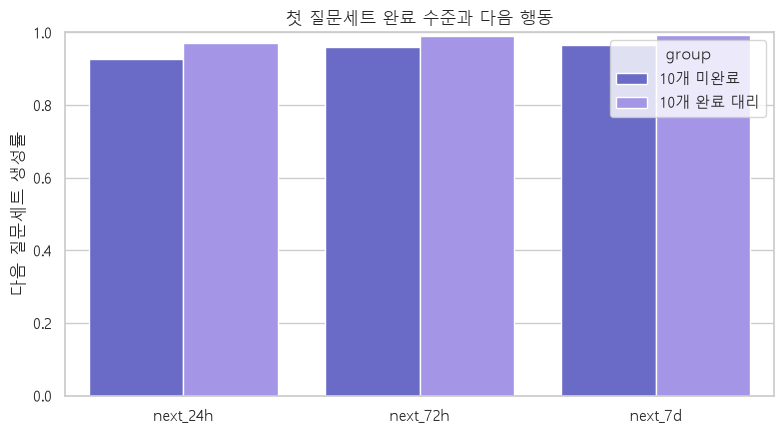

완료 대리 × 7일 내 다음 질문세트: chi2=18.26, p=1.93e-05 (연관성 검정)


In [9]:
completion_follow = followup.groupby('completed_10_proxy').agg(
    users=('owner_user_id','nunique'), next_24h=('next_24h','mean'),
    next_72h=('next_72h','mean'), next_7d=('next_7d','mean')).reset_index()
completion_follow['group']=completion_follow.completed_10_proxy.map({0:'10개 미완료',1:'10개 완료 대리'})
display(save_table(completion_follow, '16_completion_and_next_action'))
plot_df=completion_follow.melt(id_vars='group',value_vars=['next_24h','next_72h','next_7d'],var_name='window',value_name='rate')
plt.figure(figsize=(8,4.5))
ax=sns.barplot(data=plot_df,x='window',y='rate',hue='group',palette=COLORS[:2])
ax.set_ylim(0,1); ax.set_ylabel('다음 질문세트 생성률'); ax.set_xlabel('')
ax.set_title('첫 질문세트 완료 수준과 다음 행동')
savefig('15_completion_and_next_action')

table2x2=pd.crosstab(followup.completed_10_proxy,followup.next_7d)
chi2,p,_,_=stats.chi2_contingency(table2x2)
print(f'완료 대리 × 7일 내 다음 질문세트: chi2={chi2:.2f}, p={p:.3g} (연관성 검정)')

### 2.3 투표 수신과 Ping 상태


In [10]:
ping_status = con.execute("""
SELECT vote_status, ping_answer_status,
       COUNT(*) votes,
       AVG(CAST(ping_read=1 AS INTEGER)) current_read_rate,
       AVG(CAST(ping_answered=1 AS INTEGER)) current_answer_rate,
       AVG(ping_open_count) current_mean_open_count,
       SUM(ping_report_count>0) reported_votes
FROM vote_may WHERE eligible_vote_flag=1
GROUP BY 1,2 ORDER BY votes DESC
""").df()
display(save_table(ping_status, '17_ping_current_state'))

ping_overall = con.execute("""
SELECT COUNT(*) votes, COUNT(DISTINCT chosen_user_id) recipients,
       AVG(CAST(ping_read=1 AS INTEGER)) current_read_rate,
       AVG(CAST(ping_answered=1 AS INTEGER)) current_answer_rate,
       AVG(ping_open_count) current_mean_open_count,
       SUM(ping_report_count>0) reported_votes
FROM vote_may WHERE eligible_vote_flag=1
""").df()
display(save_table(ping_overall, '18_ping_overall'))

,vote_status,ping_answer_status,votes,current_read_rate,current_answer_rate,current_mean_open_count,reported_votes
0,C,N,944458,0.5081,0.0000,0.0000,0.0000
1,C,A,97816,1.0000,1.0000,0.0000,94.0000
2,I,N,44061,0.9358,0.0000,1.2481,31.0000
3,I,A,10265,1.0000,1.0000,1.3288,35.0000
4,C,P,6211,1.0000,1.0000,0.0000,3.0000
5,I,P,1323,1.0000,1.0000,1.3522,3.0000
6,B,N,498,0.5181,0.0000,0.1667,1.0000
7,B,A,46,1.0000,1.0000,0.6522,0.0000
8,B,P,3,1.0000,1.0000,2.0000,0.0000


,votes,recipients,current_read_rate,current_answer_rate,current_mean_open_count,reported_votes
0,1104681,14691,0.5766,0.1047,0.0639,167.0000


,receipt_band,users,current_read_rate,next_set_24h,next_set_7d
0,1회,1788,0.5884,0.0045,0.0056
1,2~3회,1939,0.7055,0.0062,0.0077
2,4~10회,2703,0.8147,0.0203,0.0274
3,11회 이상,8261,0.9512,0.5140,0.5543


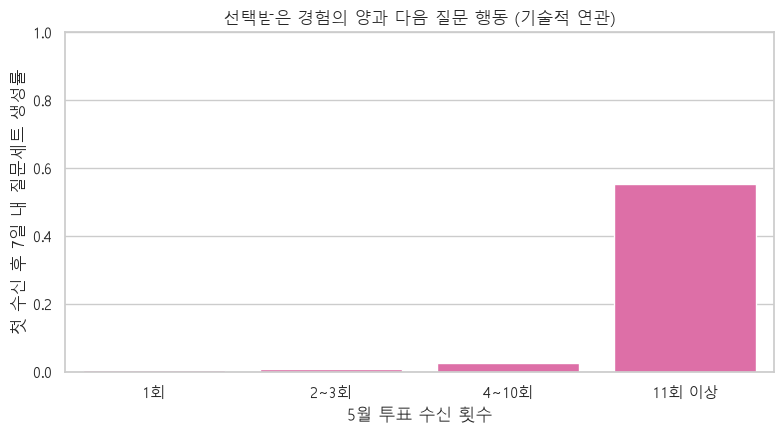

WindowsPath('C:/Users/lucy5/Desktop/team7/analysis/interaction_deep_dive/outputs/figures/16_received_vote_dose_followup.png')

In [11]:
receipt_follow = con.execute("""
WITH r AS (
  SELECT chosen_user_id user_id, MIN(vote_at) first_received_at,
         COUNT(*) received_votes,
         MAX(ping_read=1) any_ping_read_current,
         MAX(ping_answered=1) any_ping_answered_current
  FROM vote_may WHERE eligible_vote_flag=1 AND chosen_user_id IS NOT NULL
  GROUP BY 1
), q AS (
  SELECT r.*,
         MIN(s.set_created_at) FILTER(WHERE s.set_created_at>r.first_received_at) next_set_after_receipt
  FROM r LEFT JOIN question_set_all s ON s.owner_user_id=r.user_id AND s.eligible_set_flag=1
  GROUP BY ALL
)
SELECT *, date_diff('hour',first_received_at,next_set_after_receipt) hours_to_next_set,
       CASE WHEN next_set_after_receipt<=first_received_at+INTERVAL 24 HOUR THEN 1 ELSE 0 END next_set_24h,
       CASE WHEN next_set_after_receipt<=first_received_at+INTERVAL 7 DAY THEN 1 ELSE 0 END next_set_7d
FROM q
""").df()
receipt_follow['receipt_band']=pd.cut(receipt_follow.received_votes,[0,1,3,10,np.inf],labels=['1회','2~3회','4~10회','11회 이상'])
receipt_dose=receipt_follow.groupby('receipt_band',observed=True).agg(
    users=('user_id','nunique'), current_read_rate=('any_ping_read_current','mean'),
    next_set_24h=('next_set_24h','mean'),next_set_7d=('next_set_7d','mean')).reset_index()
display(save_table(receipt_dose, '19_received_vote_dose_and_followup'))
plt.figure(figsize=(8,4.5))
ax=sns.barplot(data=receipt_dose,x='receipt_band',y='next_set_7d',color=COLORS[4])
ax.set_ylim(0,1); ax.set_xlabel('5월 투표 수신 횟수'); ax.set_ylabel('첫 수신 후 7일 내 질문세트 생성률')
ax.set_title('선택받은 경험의 양과 다음 질문 행동 (기술적 연관)')
savefig('16_received_vote_dose_followup')

### 2.4 첫 질문세트와 7일 후속 행동


,feature,standardized_coef,odds_ratio_per_1sd
0,vote_coverage,2.3852,10.8614
2,skip_history_pieces,-1.0952,0.3345
3,avg_candidate_count,-0.2264,0.7974
4,completed_10_proxy,-0.1238,0.8836
1,mapped_pieces,0.1070,1.1130


설명용 동일표본 AUC=0.920. 인과효과가 아니라 다음 행동과의 조건부 연관성이다.


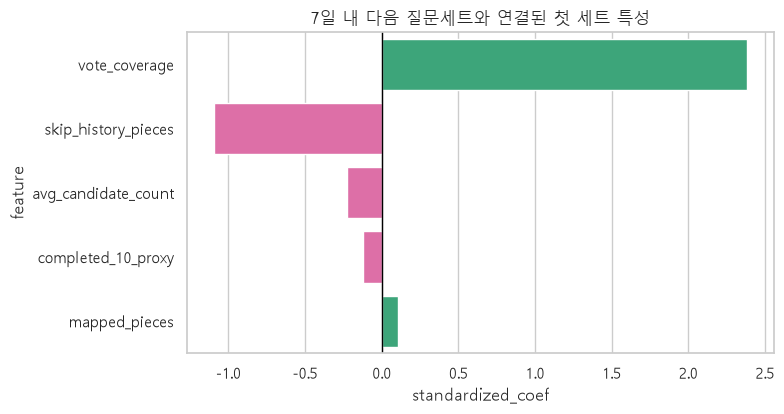

WindowsPath('C:/Users/lucy5/Desktop/team7/analysis/interaction_deep_dive/outputs/figures/17_may_followup_model_coefficients.png')

In [12]:
model_may=followup.copy()
features=['vote_coverage','mapped_pieces','skip_history_pieces','avg_candidate_count','completed_10_proxy']
X=model_may[features].replace([np.inf,-np.inf],np.nan)
y=model_may.next_7d.astype(int)
pipe=Pipeline([('imp',SimpleImputer(strategy='median')),('scale',StandardScaler()),
               ('model',LogisticRegression(max_iter=3000,class_weight='balanced'))])
pipe.fit(X,y)
pred=pipe.predict_proba(X)[:,1]
may_auc=roc_auc_score(y,pred)
coefs=pd.DataFrame({'feature':features,'standardized_coef':pipe.named_steps['model'].coef_[0]})
coefs['odds_ratio_per_1sd']=np.exp(coefs.standardized_coef)
coefs=coefs.sort_values('standardized_coef',key=abs,ascending=False)
display(save_table(coefs,'20_may_followup_model_coefficients'))
print(f'설명용 동일표본 AUC={may_auc:.3f}. 인과효과가 아니라 다음 행동과의 조건부 연관성이다.')
plt.figure(figsize=(8,4.3))
sns.barplot(data=coefs,x='standardized_coef',y='feature',palette=[COLORS[2] if x>0 else COLORS[4] for x in coefs.standardized_coef])
plt.axvline(0,color='black',lw=1); plt.title('7일 내 다음 질문세트와 연결된 첫 세트 특성')
savefig('17_may_followup_model_coefficients')

## 3. 2023-07-18~08-10 Hackle 행동

방문 안의 화면 이동, 질문·결과 행동과 다음 방문을 분석한다.


### 3.1 이벤트 사전과 계측 범위


In [13]:
event_dict = con.execute("""
SELECT event_key, COUNT(*) events, COUNT(DISTINCT visit_id) visits,
       COUNT(DISTINCT user_id) users
FROM hackle_event_core GROUP BY 1 ORDER BY events DESC
""").df()
display(save_table(event_dict,'30_hackle_event_dictionary'))
key_check=pd.DataFrame({
    '계측 항목':['질문 시작','질문 열기/응답 상호작용','질문 완료','질문 스킵','공식 Ping 열람','알림센터','알림 상세'],
    'event_key':['click_question_start','click_question_open','complete_question','skip_question','open_ping','click_appbar_alarm_center','click_notice_detail']
}).merge(event_dict[['event_key','events','visits']],on='event_key',how='left').fillna(0)
display(save_table(key_check,'31_hackle_interaction_key_check'))
if key_check.loc[key_check.event_key.eq('open_ping'),'events'].iloc[0]==0:
    display(Markdown('> **계측 경고:** 마트 정의의 공식 `open_ping` 이벤트가 실제 로그에는 0건이다. 따라서 알림센터와 알림 상세를 결과 확인 **대리 경로**로 별도 분석하며 Ping 열람으로 등치하지 않는다.'))

,event_key,events,visits,users
0,view_lab_tap,1266665,399239,103351
1,view_timeline_tap,1194508,379099,97665
2,$session_start,1036852,879208,140425
3,launch_app,986388,829955,140589
4,click_question_open,816801,223501,70514
5,click_bottom_navigation_questions,769163,317770,98723
6,click_bottom_navigation_profile,653507,339624,96339
7,$session_end,649658,605601,104507
8,click_bottom_navigation_timeline,536051,278369,86893
9,skip_question,454981,110591,25668


,계측 항목,event_key,events,visits
0,질문 시작,click_question_start,"220,385.0000","202,072.0000"
1,질문 열기/응답 상호작용,click_question_open,"816,801.0000","223,501.0000"
2,질문 완료,complete_question,"154,105.0000","150,143.0000"
3,질문 스킵,skip_question,"454,981.0000","110,591.0000"
4,공식 Ping 열람,open_ping,0.0000,0.0000
5,알림센터,click_appbar_alarm_center,"253,541.0000","191,220.0000"
6,알림 상세,click_notice_detail,"229,358.0000","129,925.0000"


> **계측 경고:** 마트 정의의 공식 `open_ping` 이벤트가 실제 로그에는 0건이다. 따라서 알림센터와 알림 상세를 결과 확인 **대리 경로**로 별도 분석하며 Ping 열람으로 등치하지 않는다.

In [14]:
con.execute("""
CREATE OR REPLACE TEMP VIEW hackle_event_labeled AS
SELECT *, CASE
  WHEN event_key IN ('$session_start','launch_app') THEN '01_진입'
  WHEN event_key IN ('click_bottom_navigation_questions','view_questions_tap','click_question_ask') THEN '02_질문화면'
  WHEN event_key='click_question_start' THEN '03_질문시작'
  WHEN event_key='click_question_open' THEN '04_질문상호작용'
  WHEN event_key='complete_question' THEN '05_질문완료'
  WHEN event_key='skip_question' THEN '06_질문스킵'
  WHEN event_key='click_appbar_alarm_center' THEN '07_알림센터'
  WHEN event_key='click_notice_detail' THEN '08_알림상세'
  WHEN event_key IN ('view_timeline_tap','click_bottom_navigation_timeline') THEN '09_타임라인'
  WHEN event_key IN ('view_lab_tap','click_bottom_navigation_lab') THEN '10_랩'
  WHEN event_key IN ('view_profile_tap','click_bottom_navigation_profile') THEN '11_프로필'
  WHEN event_key IN ('click_appbar_friend_plus','click_friend_invite','click_invite_friend','click_autoadd_contact') THEN '12_친구행동'
  WHEN event_key IN ('click_appbar_chat_rooms','click_timeline_chat_start','click_community_chat') THEN '13_대화'
  WHEN event_key IN ('view_shop','click_purchase','complete_purchase') THEN '14_상점'
  WHEN event_key IN ('view_login','view_signup','complete_signup') THEN '15_가입'
  WHEN event_key IN ('$session_end') THEN '98_세션종료'
  ELSE '99_기타' END AS category
FROM hackle_event_core
""")
con.execute("""
CREATE OR REPLACE TEMP VIEW hackle_visit_interaction AS
WITH e AS (
  SELECT visit_id,
     SUM(category='02_질문화면') question_surface_events,
     SUM(category='03_질문시작') question_start_events,
     SUM(category='04_질문상호작용') question_open_events,
     SUM(category='05_질문완료') question_complete_events,
     SUM(category='06_질문스킵') question_skip_events,
     SUM(category='07_알림센터') alarm_center_events,
     SUM(category='08_알림상세') notice_detail_events,
     SUM(category IN ('09_타임라인','10_랩','11_프로필')) browse_events,
     SUM(category='12_친구행동') friend_events,
     SUM(category='13_대화') chat_events,
     COUNT(DISTINCT category) interaction_category_count
  FROM hackle_event_labeled GROUP BY 1
)
SELECT v.*, e.* EXCLUDE(visit_id),
       (question_surface_events>0)::INT question_surface_flag,
       (question_start_events>0)::INT question_start_flag,
       (question_open_events>0)::INT question_open_flag,
       (question_complete_events>0)::INT question_complete_flag,
       (question_skip_events>0)::INT question_skip_flag,
       (alarm_center_events>0)::INT alarm_center_flag,
       (notice_detail_events>0)::INT notice_detail_flag,
       (browse_events>0)::INT browse_flag,
       (friend_events>0)::INT friend_flag,
       (chat_events>0)::INT chat_flag
FROM hackle_visit_core v JOIN e USING(visit_id)
""")
print('방문 단위 상호작용 뷰 생성 완료')

방문 단위 상호작용 뷰 생성 완료


### 3.2 방문 깊이와 질문 행동


,visits,identified_users,median_events,p90_events,median_seconds,p90_seconds,question_surface_visit_rate,question_start_visit_rate,question_complete_visit_rate,question_skip_visit_rate,notice_detail_visit_rate
0,896009,140663,8.0000,28.0000,39.0000,495.0000,0.3881,0.2255,0.1676,0.1234,0.1450


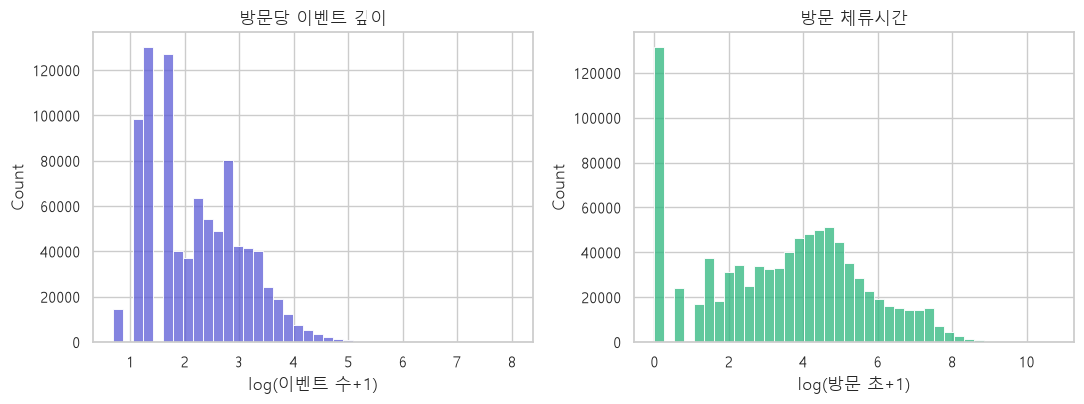

WindowsPath('C:/Users/lucy5/Desktop/team7/analysis/interaction_deep_dive/outputs/figures/30_hackle_visit_depth_duration.png')

In [15]:
visit_summary=con.execute("""
SELECT COUNT(*) visits, COUNT(DISTINCT user_id) identified_users,
       median(event_count) median_events, quantile_cont(event_count,.9) p90_events,
       median(duration_seconds) median_seconds, quantile_cont(duration_seconds,.9) p90_seconds,
       AVG(question_surface_flag) question_surface_visit_rate,
       AVG(question_start_flag) question_start_visit_rate,
       AVG(question_complete_flag) question_complete_visit_rate,
       AVG(question_skip_flag) question_skip_visit_rate,
       AVG(notice_detail_flag) notice_detail_visit_rate
FROM hackle_visit_interaction
""").df()
display(save_table(visit_summary,'32_hackle_visit_summary'))
visit_dist=con.execute("""
SELECT event_count,duration_seconds FROM hackle_visit_interaction
WHERE event_count IS NOT NULL AND duration_seconds IS NOT NULL
""").df()
fig,axs=plt.subplots(1,2,figsize=(11,4.2))
sns.histplot(np.log1p(visit_dist.event_count),bins=40,color=COLORS[0],ax=axs[0]); axs[0].set_xlabel('log(이벤트 수+1)'); axs[0].set_title('방문당 이벤트 깊이')
sns.histplot(np.log1p(visit_dist.duration_seconds.clip(lower=0)),bins=40,color=COLORS[2],ax=axs[1]); axs[1].set_xlabel('log(방문 초+1)'); axs[1].set_title('방문 체류시간')
savefig('30_hackle_visit_depth_duration')

### 3.3 질문 시작·완료·결과 도달


,stage_order,stage,visits,all_visit_rate
0,1,전체 방문,"896,009.0000",1.0000
1,2,질문 화면,"347,774.0000",0.3881
2,3,질문 시작,"202,072.0000",0.2255
3,4,질문 상호작용,"316,639.0000",0.3534
4,5,질문 완료,"150,143.0000",0.1676
5,6,알림 상세,"129,925.0000",0.1450


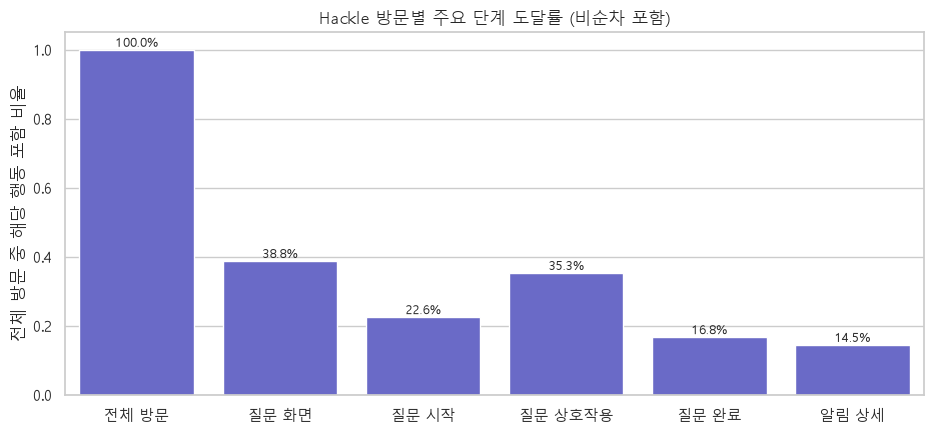

WindowsPath('C:/Users/lucy5/Desktop/team7/analysis/interaction_deep_dive/outputs/figures/31_hackle_stage_reach.png')

In [16]:
reach=con.execute("""
SELECT * FROM (VALUES
  (1,'전체 방문',(SELECT COUNT(*) FROM hackle_visit_interaction)),
  (2,'질문 화면',(SELECT SUM(question_surface_flag) FROM hackle_visit_interaction)),
  (3,'질문 시작',(SELECT SUM(question_start_flag) FROM hackle_visit_interaction)),
  (4,'질문 상호작용',(SELECT SUM(question_open_flag OR question_skip_flag OR question_complete_flag) FROM hackle_visit_interaction)),
  (5,'질문 완료',(SELECT SUM(question_complete_flag) FROM hackle_visit_interaction)),
  (6,'알림 상세',(SELECT SUM(notice_detail_flag) FROM hackle_visit_interaction))
) t(stage_order,stage,visits)
""").df()
reach['all_visit_rate']=reach.visits/reach.visits.iloc[0]
display(save_table(reach,'33_hackle_visit_stage_reach'))
plt.figure(figsize=(9.5,4.5))
ax=sns.barplot(data=reach,x='stage',y='all_visit_rate',color=COLORS[0])
ax.set_ylabel('전체 방문 중 해당 행동 포함 비율'); ax.set_xlabel(''); ax.set_title('Hackle 방문별 주요 단계 도달률 (비순차 포함)')
for p,v in zip(ax.patches,reach.all_visit_rate): ax.text(p.get_x()+p.get_width()/2,v+.008,f'{v:.1%}',ha='center',fontsize=9)
savefig('31_hackle_stage_reach')

,전환,분자,분모,rate
0,시작→상호작용,32441,202072,0.1605
1,시작→완료,149017,202072,0.7374
2,시작→스킵,109865,202072,0.5437
3,완료→알림센터,18280,150143,0.1218
4,완료→알림상세,14603,150143,0.0973
5,알림센터→알림상세,128612,191220,0.6726


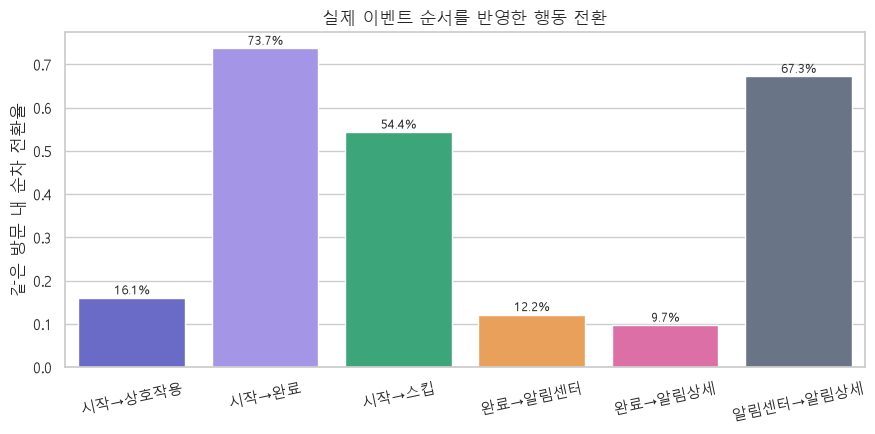

WindowsPath('C:/Users/lucy5/Desktop/team7/analysis/interaction_deep_dive/outputs/figures/32_hackle_ordered_conversions.png')

In [17]:
ordered=con.execute("""
WITH o AS (
  SELECT visit_id,
    MIN(event_order) FILTER(WHERE category='03_질문시작') qstart,
    MIN(event_order) FILTER(WHERE category='04_질문상호작용') qopen,
    MIN(event_order) FILTER(WHERE category='05_질문완료') qcomplete,
    MIN(event_order) FILTER(WHERE category='06_질문스킵') qskip,
    MIN(event_order) FILTER(WHERE category='07_알림센터') alarm,
    MIN(event_order) FILTER(WHERE category='08_알림상세') notice
  FROM hackle_event_labeled GROUP BY 1
)
SELECT
  COUNT(*) FILTER(WHERE qstart IS NOT NULL) start_visits,
  COUNT(*) FILTER(WHERE qstart IS NOT NULL AND qopen>qstart) open_after_start,
  COUNT(*) FILTER(WHERE qstart IS NOT NULL AND qcomplete>qstart) complete_after_start,
  COUNT(*) FILTER(WHERE qstart IS NOT NULL AND qskip>qstart) skip_after_start,
  COUNT(*) FILTER(WHERE qcomplete IS NOT NULL AND alarm>qcomplete) alarm_after_complete,
  COUNT(*) FILTER(WHERE qcomplete IS NOT NULL AND notice>qcomplete) notice_after_complete,
  COUNT(*) FILTER(WHERE alarm IS NOT NULL AND notice>alarm) notice_after_alarm
FROM o
""").df()
ordered_long=pd.DataFrame({
  '전환':['시작→상호작용','시작→완료','시작→스킵','완료→알림센터','완료→알림상세','알림센터→알림상세'],
  '분자':[ordered.open_after_start[0],ordered.complete_after_start[0],ordered.skip_after_start[0],ordered.alarm_after_complete[0],ordered.notice_after_complete[0],ordered.notice_after_alarm[0]],
  '분모':[ordered.start_visits[0],ordered.start_visits[0],ordered.start_visits[0],
         con.execute("SELECT SUM(question_complete_flag) FROM hackle_visit_interaction").fetchone()[0],
         con.execute("SELECT SUM(question_complete_flag) FROM hackle_visit_interaction").fetchone()[0],
         con.execute("SELECT SUM(alarm_center_flag) FROM hackle_visit_interaction").fetchone()[0]]})
ordered_long['rate']=ordered_long['분자']/ordered_long['분모']
display(save_table(ordered_long,'34_hackle_ordered_conversions'))
plt.figure(figsize=(9,4.5))
ax=sns.barplot(data=ordered_long,x='전환',y='rate',palette=COLORS)
ax.set_ylabel('같은 방문 내 순차 전환율'); ax.set_xlabel(''); ax.set_title('실제 이벤트 순서를 반영한 행동 전환')
for p,v in zip(ax.patches,ordered_long.rate): ax.text(p.get_x()+p.get_width()/2,v+.008,f'{v:.1%}',ha='center',fontsize=9)
plt.xticks(rotation=12)
savefig('32_hackle_ordered_conversions')

### 3.4 행동 전이와 이탈


,source_category,target_category,transitions,transition_rate
0,01_진입,EXIT,292283,0.2942
1,01_진입,09_타임라인,134535,0.1354
2,01_진입,04_질문상호작용,113760,0.1145
3,01_진입,03_질문시작,99029,0.0997
4,01_진입,02_질문화면,79363,0.0799
5,02_질문화면,09_타임라인,339274,0.3845
6,02_질문화면,10_랩,199901,0.2266
7,02_질문화면,04_질문상호작용,82691,0.0937
8,02_질문화면,EXIT,78160,0.0886
9,02_질문화면,03_질문시작,47926,0.0543


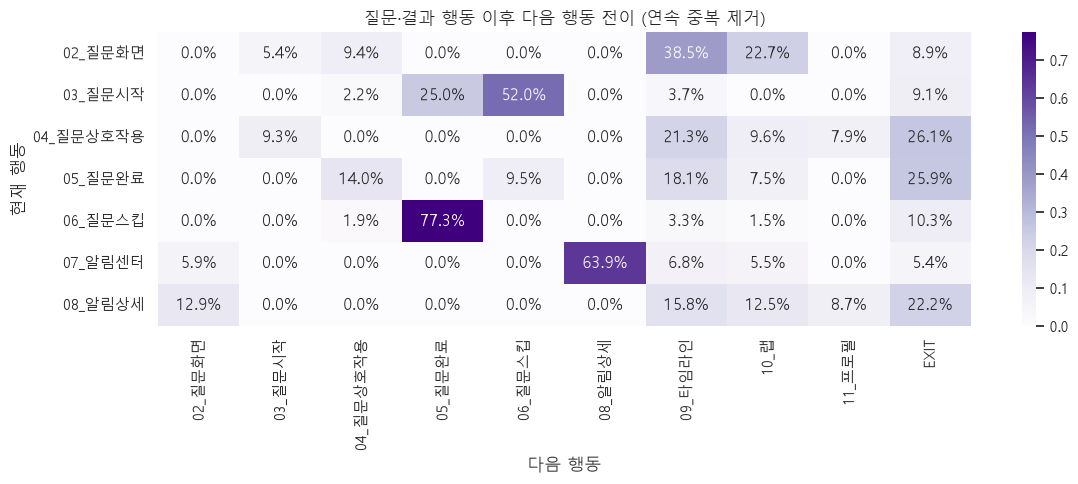

WindowsPath('C:/Users/lucy5/Desktop/team7/analysis/interaction_deep_dive/outputs/figures/33_hackle_transition_heatmap.png')

In [18]:
transitions=con.execute("""
WITH x AS (
  SELECT visit_id,event_order,category,
         LAG(category) OVER(PARTITION BY visit_id ORDER BY event_order,event_sk) prev_category
  FROM hackle_event_labeled
  WHERE category NOT IN ('98_세션종료','99_기타')
), collapsed AS (
  SELECT * FROM x WHERE prev_category IS NULL OR category<>prev_category
), tr AS (
  SELECT category AS source_category,
         LEAD(category) OVER(PARTITION BY visit_id ORDER BY event_order) AS target_category
  FROM collapsed
), counts AS (
  SELECT source_category,COALESCE(target_category,'EXIT') AS target_category,COUNT(*) transitions
  FROM tr GROUP BY 1,2
)
SELECT *, transitions/SUM(transitions) OVER(PARTITION BY source_category) transition_rate
FROM counts QUALIFY ROW_NUMBER() OVER(PARTITION BY source_category ORDER BY transitions DESC)<=5
ORDER BY source_category,transitions DESC
""").df()
display(save_table(transitions,'35_top_behavior_transitions'))
focus=transitions[transitions.source_category.isin(['02_질문화면','03_질문시작','04_질문상호작용','05_질문완료','06_질문스킵','07_알림센터','08_알림상세'])]
pivot=focus.pivot(index='source_category',columns='target_category',values='transition_rate').fillna(0)
plt.figure(figsize=(12,5))
sns.heatmap(pivot,annot=True,fmt='.1%',cmap='Purples',vmin=0,vmax=max(.01,float(pivot.max().max())))
plt.title('질문·결과 행동 이후 다음 행동 전이 (연속 중복 제거)'); plt.xlabel('다음 행동'); plt.ylabel('현재 행동')
savefig('33_hackle_transition_heatmap')

,last_meaningful_action,visits,visit_share
0,11_프로필,101083,0.1647
1,09_타임라인,88702,0.1445
2,10_랩,82129,0.1338
3,02_질문화면,79458,0.1294
4,04_질문상호작용,78927,0.1286
5,05_질문완료,41910,0.0683
6,08_알림상세,36009,0.0587
7,13_대화,34879,0.0568
8,03_질문시작,19854,0.0323
9,06_질문스킵,13593,0.0221


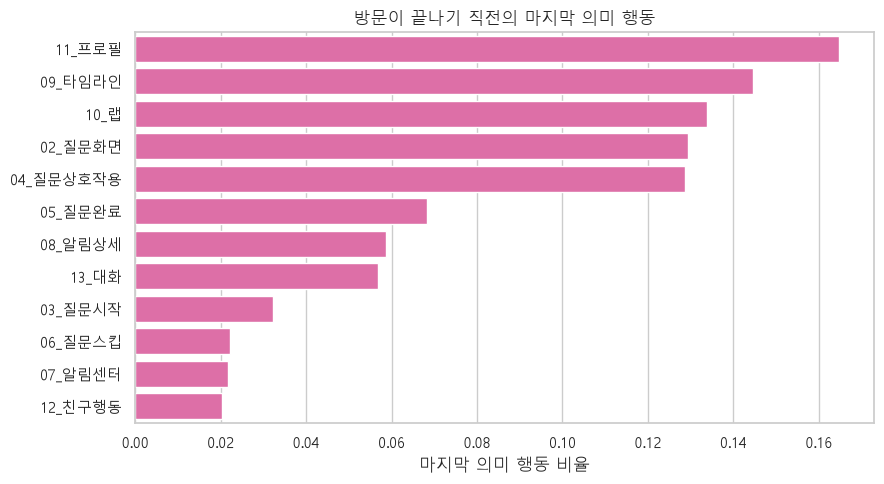

WindowsPath('C:/Users/lucy5/Desktop/team7/analysis/interaction_deep_dive/outputs/figures/34_hackle_last_action.png')

In [19]:
exits=con.execute("""
WITH x AS (
  SELECT visit_id,category,event_order,
         ROW_NUMBER() OVER(PARTITION BY visit_id ORDER BY event_order DESC,event_sk DESC) rn
  FROM hackle_event_labeled WHERE category NOT IN ('01_진입','98_세션종료','99_기타')
)
SELECT category last_meaningful_action,COUNT(*) visits,
       COUNT(*)/SUM(COUNT(*)) OVER() visit_share
FROM x WHERE rn=1 GROUP BY 1 ORDER BY visits DESC
""").df()
display(save_table(exits,'36_last_meaningful_action'))
plt.figure(figsize=(9,5))
top=exits.head(12)
sns.barplot(data=top,y='last_meaningful_action',x='visit_share',color=COLORS[4])
plt.xlabel('마지막 의미 행동 비율'); plt.ylabel(''); plt.title('방문이 끝나기 직전의 마지막 의미 행동')
savefig('34_hackle_last_action')

### 3.5 첫 관측 방문과 이후 방문


,visit_type,visits,users,median_events,median_seconds,question_surface_rate,question_start_rate,question_complete_rate,question_skip_rate,notice_detail_rate,browse_rate
0,이후 방문,486324,80559,7.0000,35.0000,0.3147,0.2651,0.2137,0.1598,0.1129,0.4626
1,첫 관측 방문,140663,140663,10.0000,54.0000,0.5252,0.1888,0.1159,0.0830,0.2136,0.5895


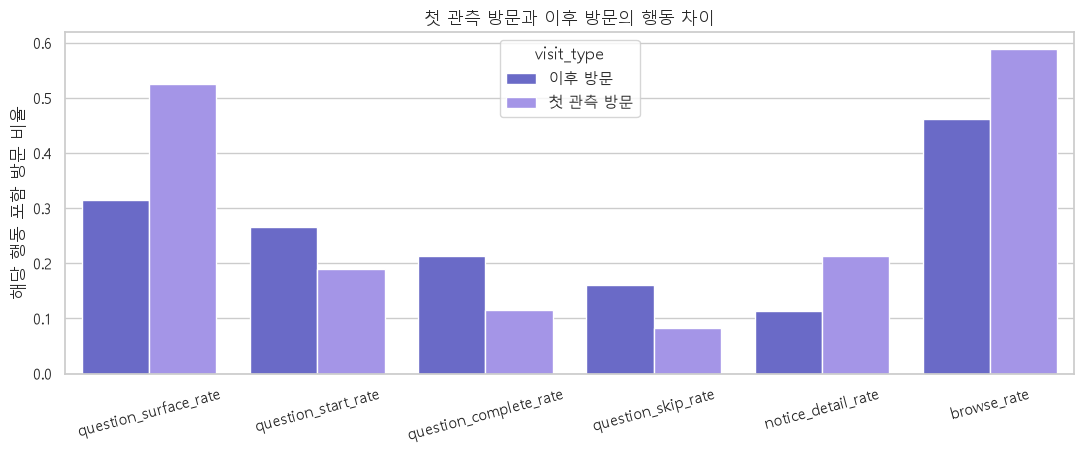

WindowsPath('C:/Users/lucy5/Desktop/team7/analysis/interaction_deep_dive/outputs/figures/35_first_vs_repeat_visit.png')

In [20]:
visit_ordered=con.execute("""
SELECT *, ROW_NUMBER() OVER(PARTITION BY user_id ORDER BY visit_start,visit_id) observed_visit_no,
       LEAD(visit_start) OVER(PARTITION BY user_id ORDER BY visit_start,visit_id) next_visit_start
FROM hackle_visit_interaction
WHERE identity_status='IDENTIFIED_SERVICE_USER' AND user_id IS NOT NULL
  AND COALESCE(is_staff,0)=0 AND COALESCE(is_superuser,0)=0
""").df()
visit_ordered['visit_type']=np.where(visit_ordered.observed_visit_no.eq(1),'첫 관측 방문','이후 방문')
compare=visit_ordered.groupby('visit_type').agg(
  visits=('visit_id','nunique'),users=('user_id','nunique'),
  median_events=('event_count','median'),median_seconds=('duration_seconds','median'),
  question_surface_rate=('question_surface_flag','mean'),question_start_rate=('question_start_flag','mean'),
  question_complete_rate=('question_complete_flag','mean'),question_skip_rate=('question_skip_flag','mean'),
  notice_detail_rate=('notice_detail_flag','mean'),browse_rate=('browse_flag','mean')).reset_index()
display(save_table(compare,'37_first_vs_repeat_visit'))
comp_long=compare.melt(id_vars='visit_type',value_vars=['question_surface_rate','question_start_rate','question_complete_rate','question_skip_rate','notice_detail_rate','browse_rate'],var_name='metric',value_name='rate')
plt.figure(figsize=(11,4.7))
sns.barplot(data=comp_long,x='metric',y='rate',hue='visit_type',palette=COLORS[:2])
plt.ylabel('해당 행동 포함 방문 비율'); plt.xlabel(''); plt.xticks(rotation=15); plt.title('첫 관측 방문과 이후 방문의 행동 차이')
savefig('35_first_vs_repeat_visit')

In [21]:
tests=[]
first=visit_ordered[visit_ordered.visit_type.eq('첫 관측 방문')]
repeat=visit_ordered[visit_ordered.visit_type.eq('이후 방문')]
for col in ['question_start_flag','question_complete_flag','question_skip_flag','notice_detail_flag','browse_flag']:
    tab=pd.crosstab(visit_ordered.visit_type,visit_ordered[col])
    chi2,p,_,_=stats.chi2_contingency(tab)
    tests.append([col,'chi-square',chi2,p,first[col].mean(),repeat[col].mean(),repeat[col].mean()-first[col].mean()])
for col in ['event_count','duration_seconds']:
    a=first[col].dropna().sample(min(50000,first[col].notna().sum()),random_state=42)
    b=repeat[col].dropna().sample(min(50000,repeat[col].notna().sum()),random_state=42)
    u,p=stats.mannwhitneyu(a,b,alternative='two-sided')
    rb=2*u/(len(a)*len(b))-1
    tests.append([col,'Mann-Whitney',u,p,a.median(),b.median(),rb])
test_df=pd.DataFrame(tests,columns=['metric','test','statistic','p_value','first_value','repeat_value','difference_or_rank_biserial'])
display(save_table(test_df,'38_first_repeat_stat_tests'))
print('표본이 매우 크므로 p값보다 비율 차이·중앙값 차이·효과크기를 우선 해석한다.')

,metric,test,statistic,p_value,first_value,repeat_value,difference_or_rank_biserial
0,question_start_flag,chi-square,"3,405.0573",0.0000,0.1888,0.2651,0.0763
1,question_complete_flag,chi-square,"6,728.0825",0.0000,0.1159,0.2137,0.0978
2,question_skip_flag,chi-square,"5,264.3770",0.0000,0.0830,0.1598,0.0768
3,notice_detail_flag,chi-square,"9,444.9656",0.0000,0.2136,0.1129,-0.1007
4,browse_flag,chi-square,"7,026.2165",0.0000,0.5895,0.4626,-0.1269
5,event_count,Mann-Whitney,"1,471,600,757.5000",0.0000,10.0000,7.0000,0.1773
6,duration_seconds,Mann-Whitney,"1,334,346,754.5000",0.0000,54.0000,35.0000,0.0675


표본이 매우 크므로 p값보다 비율 차이·중앙값 차이·효과크기를 우선 해석한다.


### 3.6 첫 관측 방문과 7일 재방문


,window,rate,users
0,24시간,0.2261,117420
1,72시간,0.3662,117420
2,7일,0.4902,117420


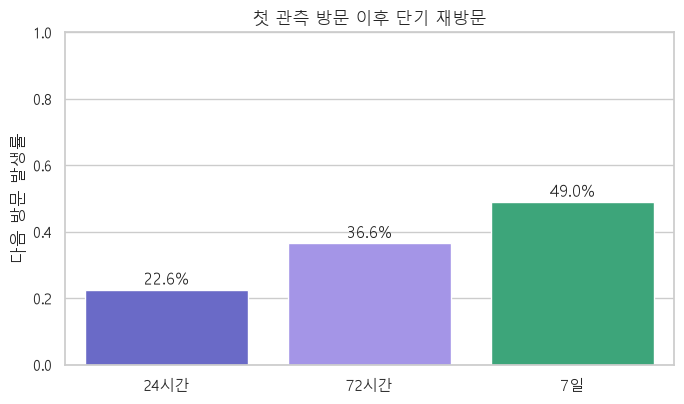

WindowsPath('C:/Users/lucy5/Desktop/team7/analysis/interaction_deep_dive/outputs/figures/36_hackle_revisit_rates.png')

In [22]:
first_visits=visit_ordered[visit_ordered.observed_visit_no.eq(1)].copy()
window_end=pd.Timestamp(visit_ordered.visit_start.max())
first_visits['hours_to_next']=(first_visits.next_visit_start-first_visits.visit_start).dt.total_seconds()/3600
first_visits['next_24h']=(first_visits.hours_to_next<=24).astype(int)
first_visits['next_72h']=(first_visits.hours_to_next<=72).astype(int)
first_visits['next_7d']=(first_visits.hours_to_next<=24*7).astype(int)
first_visits['observable_7d']=first_visits.visit_start<=window_end-pd.Timedelta(days=7)
revisit_cohort=first_visits[first_visits.observable_7d].copy()
revisit_rates=pd.DataFrame({'window':['24시간','72시간','7일'],
  'rate':[revisit_cohort.next_24h.mean(),revisit_cohort.next_72h.mean(),revisit_cohort.next_7d.mean()],
  'users':[len(revisit_cohort)]*3})
display(save_table(revisit_rates,'39_revisit_rates'))
plt.figure(figsize=(7,4.2))
ax=sns.barplot(data=revisit_rates,x='window',y='rate',palette=COLORS[:3])
ax.set_ylim(0,1); ax.set_ylabel('다음 방문 발생률'); ax.set_xlabel(''); ax.set_title('첫 관측 방문 이후 단기 재방문')
for p,v in zip(ax.patches,revisit_rates.rate): ax.text(p.get_x()+p.get_width()/2,v+.015,f'{v:.1%}',ha='center')
savefig('36_hackle_revisit_rates')

,first_visit_behavior,n_without,revisit_without,n_with,revisit_with,pp_difference
2,question_complete_flag,103659,0.4738,13761,0.6136,0.1398
3,question_skip_flag,107592,0.4803,9828,0.5992,0.1189
1,question_start_flag,95546,0.4782,21874,0.5426,0.0644
7,friend_flag,111591,0.4885,5829,0.5239,0.0355
8,chat_flag,98405,0.4958,19015,0.4615,-0.0343
5,notice_detail_flag,95580,0.5030,21840,0.4341,-0.0690
4,alarm_center_flag,83116,0.5255,34304,0.4048,-0.1207
6,browse_flag,50951,0.5592,66469,0.4373,-0.1219
0,question_surface_flag,59062,0.5585,58358,0.4211,-0.1373


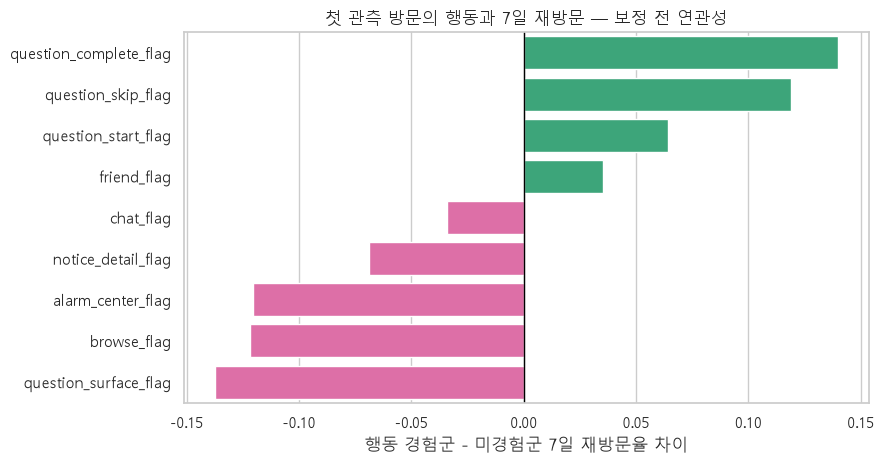

WindowsPath('C:/Users/lucy5/Desktop/team7/analysis/interaction_deep_dive/outputs/figures/37_first_visit_behavior_revisit.png')

In [23]:
behavior_cols=['question_surface_flag','question_start_flag','question_complete_flag','question_skip_flag','alarm_center_flag','notice_detail_flag','browse_flag','friend_flag','chat_flag']
behavior_revisit=[]
for col in behavior_cols:
    g=revisit_cohort.groupby(col).next_7d.agg(['count','mean']).reset_index()
    if set(g[col])=={0,1}:
        behavior_revisit.append([col,int(g.loc[g[col].eq(0),'count'].iloc[0]),g.loc[g[col].eq(0),'mean'].iloc[0],
                                 int(g.loc[g[col].eq(1),'count'].iloc[0]),g.loc[g[col].eq(1),'mean'].iloc[0],
                                 g.loc[g[col].eq(1),'mean'].iloc[0]-g.loc[g[col].eq(0),'mean'].iloc[0]])
br=pd.DataFrame(behavior_revisit,columns=['first_visit_behavior','n_without','revisit_without','n_with','revisit_with','pp_difference'])
br=br.sort_values('pp_difference',ascending=False)
display(save_table(br,'40_first_visit_behavior_revisit'))
plt.figure(figsize=(9,4.8))
sns.barplot(data=br,y='first_visit_behavior',x='pp_difference',palette=[COLORS[2] if x>=0 else COLORS[4] for x in br.pp_difference])
plt.axvline(0,color='black',lw=1); plt.xlabel('행동 경험군 - 미경험군 7일 재방문율 차이'); plt.ylabel('')
plt.title('첫 관측 방문의 행동과 7일 재방문 — 보정 전 연관성')
savefig('37_first_visit_behavior_revisit')

### 3.7 재방문 생존분석


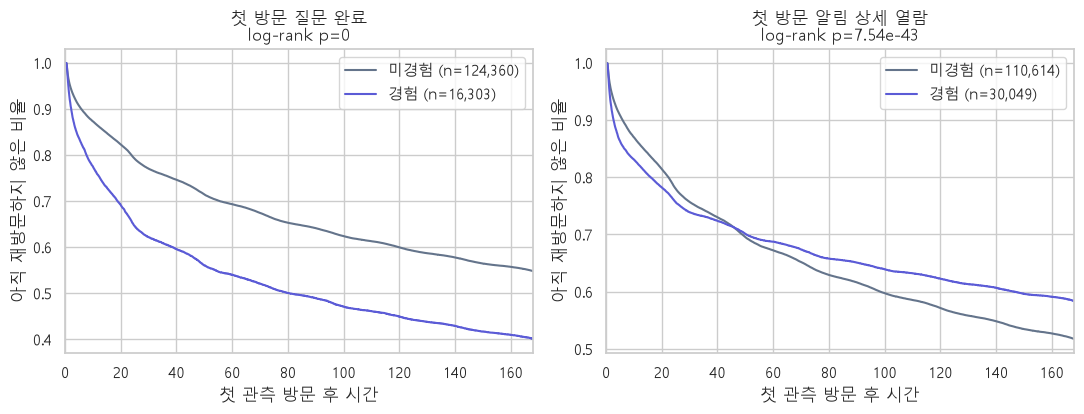

,group_variable,n0,n1,logrank_stat,p_value
0,question_complete_flag,124360,16303,"1,775.7862",0.0000
1,notice_detail_flag,110614,30049,188.2812,0.0000


In [24]:
def km_curve(duration_hours,event,max_hours=24*7):
    d=np.minimum(np.asarray(duration_hours,float),max_hours)
    e=np.asarray(event,int) & (np.asarray(duration_hours,float)<=max_hours)
    times=np.sort(np.unique(d[e.astype(bool)]))
    surv=1.0; rows=[(0.0,1.0)]
    for t in times:
        at_risk=(d>=t).sum(); events=((d==t)&e.astype(bool)).sum()
        if at_risk: surv*=1-events/at_risk
        rows.append((t,surv))
    return pd.DataFrame(rows,columns=['hours','survival'])

def logrank(d1,e1,d2,e2,max_hours=168):
    raw1=np.asarray(d1,float); raw2=np.asarray(d2,float)
    e1=np.asarray(e1,bool)&(raw1<=max_hours); e2=np.asarray(e2,bool)&(raw2<=max_hours)
    d1=np.minimum(raw1,max_hours); d2=np.minimum(raw2,max_hours)
    times=np.sort(np.unique(np.r_[d1[e1],d2[e2]])); oe=0.; var=0.
    for t in times:
        n1=(d1>=t).sum(); n2=(d2>=t).sum(); d_1=((d1==t)&e1).sum(); d_2=((d2==t)&e2).sum(); n=n1+n2; dd=d_1+d_2
        if n>1:
            oe += d_1-dd*n1/n
            var += n1*n2*dd*(n-dd)/(n*n*(n-1))
    z2=oe*oe/var if var>0 else 0; return z2,stats.chi2.sf(z2,1)

survival_base=first_visits.copy()
survival_base['follow_hours']=np.where(survival_base.next_visit_start.notna(),survival_base.hours_to_next,
    (window_end-survival_base.visit_start).dt.total_seconds()/3600)
survival_base['event_observed']=survival_base.next_visit_start.notna().astype(int)
fig,axs=plt.subplots(1,2,figsize=(11,4.3))
surv_tests=[]
for ax,col,title in zip(axs,['question_complete_flag','notice_detail_flag'],['첫 방문 질문 완료','첫 방문 알림 상세 열람']):
    curves=[]
    for val,label,color in [(0,'미경험',COLORS[5]),(1,'경험',COLORS[0])]:
        g=survival_base[survival_base[col].eq(val)]
        km=km_curve(g.follow_hours,g.event_observed); km['group']=label; curves.append(km)
        ax.step(km.hours,km.survival,where='post',label=f'{label} (n={len(g):,})',color=color)
    a=survival_base[survival_base[col].eq(0)]; b=survival_base[survival_base[col].eq(1)]
    stat,p=logrank(a.follow_hours,a.event_observed,b.follow_hours,b.event_observed)
    surv_tests.append([col,len(a),len(b),stat,p])
    ax.set_xlim(0,168); ax.set_xlabel('첫 관측 방문 후 시간'); ax.set_ylabel('아직 재방문하지 않은 비율'); ax.set_title(f'{title}\nlog-rank p={p:.3g}'); ax.legend()
savefig('38_hackle_revisit_survival')
display(save_table(pd.DataFrame(surv_tests,columns=['group_variable','n0','n1','logrank_stat','p_value']),'41_survival_logrank'))

### 3.8 방문 경로 유형

사용자 군집이 아니라 한 번의 방문 경로를 분류한다.


,k,silhouette
0,2,0.3471
1,3,0.3558
2,4,0.3148
3,5,0.3161
4,6,0.3333


,cluster,visits,median_events,median_seconds,question_surface_rate,question_start_rate,question_complete_rate,question_skip_rate,notice_detail_rate,browse_rate,friend_rate,chat_rate,next_7d,journey_type
0,0,43525,4.0000,7.0000,0.0779,0.0438,0.0014,0.0084,0.0304,0.2350,0.0054,0.0372,0.7436,탐색형 C0
1,1,21333,17.0000,105.0000,0.8627,0.1278,0.0256,0.0144,0.3092,0.9494,0.1102,0.2851,0.5943,탐색형 C1
2,2,15142,15.0000,166.0000,0.4748,0.9960,0.9638,0.7040,0.1847,0.5828,0.0578,0.1730,0.8490,질문 완료형 C2


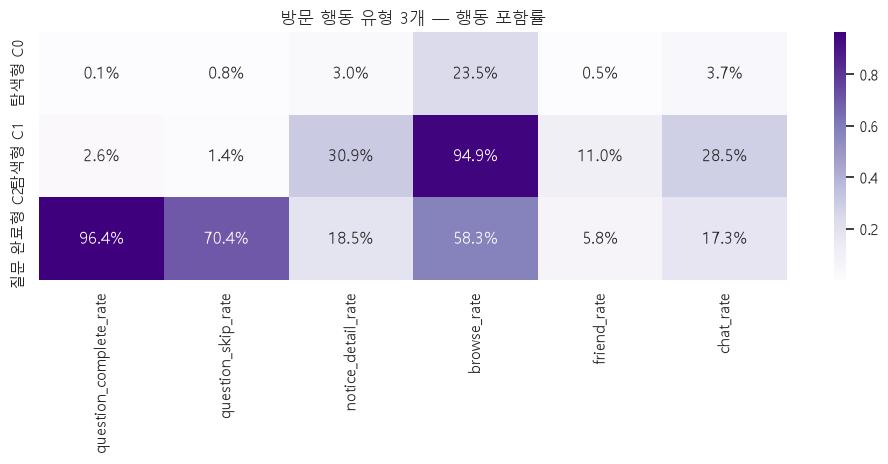

WindowsPath('C:/Users/lucy5/Desktop/team7/analysis/interaction_deep_dive/outputs/figures/39_visit_journey_clusters.png')

In [25]:
cluster_cols=['event_count','duration_seconds','question_surface_events','question_start_events','question_open_events','question_complete_events','question_skip_events','alarm_center_events','notice_detail_events','browse_events','friend_events','chat_events']
cluster_df=visit_ordered[cluster_cols+['visit_id','next_visit_start','visit_start']].copy()
cluster_df[cluster_cols]=cluster_df[cluster_cols].fillna(0)
for c in ['event_count','duration_seconds']+cluster_cols[2:]: cluster_df[c]=np.log1p(cluster_df[c].clip(lower=0))
sample=cluster_df.sample(min(80000,len(cluster_df)),random_state=42)
scaler=StandardScaler(); Xs=scaler.fit_transform(sample[cluster_cols])
sil=[]
for k in range(2,7):
    km=MiniBatchKMeans(n_clusters=k,random_state=42,batch_size=4096,n_init=10).fit(Xs)
    idx=np.random.default_rng(42).choice(len(Xs),size=min(15000,len(Xs)),replace=False)
    sil.append([k,silhouette_score(Xs[idx],km.labels_[idx])])
sil_df=pd.DataFrame(sil,columns=['k','silhouette']); best_k=int(sil_df.loc[sil_df.silhouette.idxmax(),'k'])
display(save_table(sil_df,'42_visit_cluster_k_selection'))
km=MiniBatchKMeans(n_clusters=best_k,random_state=42,batch_size=4096,n_init=20).fit(Xs)
sample['cluster']=km.labels_
# 원자료 단위 평균으로 유형을 읽는다.
raw_sample=visit_ordered.loc[sample.index].copy(); raw_sample['cluster']=sample.cluster
raw_sample['next_7d']=((raw_sample.next_visit_start-raw_sample.visit_start).dt.total_seconds()/3600<=168).astype(int)
centers=raw_sample.groupby('cluster').agg(visits=('visit_id','nunique'),median_events=('event_count','median'),median_seconds=('duration_seconds','median'),
  question_surface_rate=('question_surface_flag','mean'),question_start_rate=('question_start_flag','mean'),question_complete_rate=('question_complete_flag','mean'),
  question_skip_rate=('question_skip_flag','mean'),notice_detail_rate=('notice_detail_flag','mean'),browse_rate=('browse_flag','mean'),
  friend_rate=('friend_flag','mean'),chat_rate=('chat_flag','mean'),next_7d=('next_7d','mean')).reset_index()
action_cols=['question_complete_rate','question_skip_rate','notice_detail_rate','browse_rate','friend_rate','chat_rate']
labels=[]
label_map={'question_complete_rate':'질문 완료형','question_skip_rate':'질문 스킵형','notice_detail_rate':'알림 확인형','browse_rate':'탐색형','friend_rate':'친구 행동형','chat_rate':'대화형'}
for _,r in centers.iterrows(): labels.append(label_map[max(action_cols,key=lambda c:r[c])])
# 중복 이름은 번호로 구분한다.
centers['journey_type']=[f'{lab} C{int(c)}' for lab,c in zip(labels,centers.cluster)]
display(save_table(centers,'43_visit_journey_clusters'))
heat=centers.set_index('journey_type')[action_cols]
plt.figure(figsize=(10,4.8)); sns.heatmap(heat,annot=True,fmt='.1%',cmap='Purples')
plt.title(f'방문 행동 유형 {best_k}개 — 행동 포함률'); plt.xlabel(''); plt.ylabel('')
savefig('39_visit_journey_clusters')

### 3.9 방문 깊이를 통제한 재방문 모형


,model,test_auc,features
0,방문 깊이만,0.5623,3
1,방문 깊이 + 상호작용,0.6275,13


,feature,standardized_coef,odds_ratio_per_1sd
2,distinct_event_count,1.2954,3.6525
10,browse_flag,-0.5927,0.5529
3,question_surface_flag,-0.5080,0.6017
1,duration_seconds,0.4387,1.5507
8,alarm_center_flag,-0.4221,0.6557
0,event_count,-0.3123,0.7318
5,question_open_flag,-0.2088,0.8115
4,question_start_flag,-0.1988,0.8197
12,chat_flag,-0.1227,0.8846
6,question_complete_flag,0.1159,1.1229


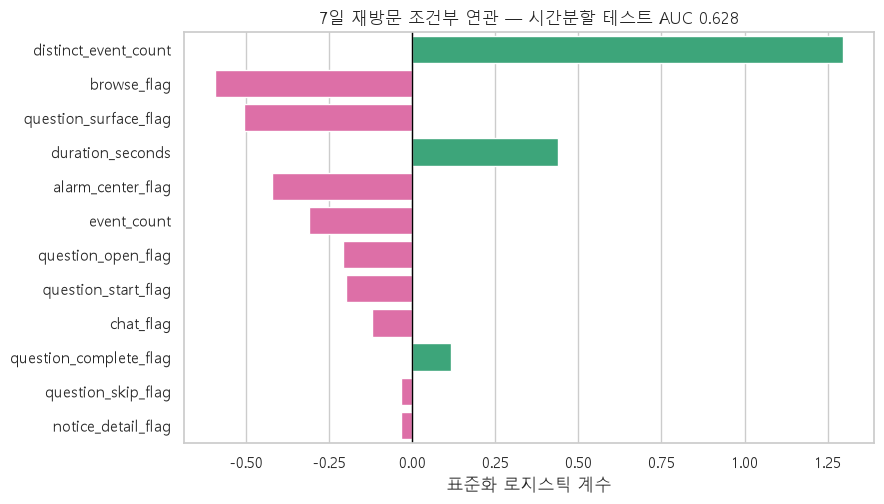

WindowsPath('C:/Users/lucy5/Desktop/team7/analysis/interaction_deep_dive/outputs/figures/40_revisit_model_coefficients.png')

In [26]:
model_df=revisit_cohort.copy()
model_features=['event_count','duration_seconds','distinct_event_count','question_surface_flag','question_start_flag','question_open_flag','question_complete_flag','question_skip_flag','alarm_center_flag','notice_detail_flag','browse_flag','friend_flag','chat_flag']
base_features=['event_count','duration_seconds','distinct_event_count']
cutoff=model_df.visit_start.quantile(.70)
train=model_df.visit_start<=cutoff; test=~train
def fit_auc(cols):
    p=Pipeline([('imp',SimpleImputer(strategy='median')),('scale',StandardScaler()),('model',LogisticRegression(max_iter=3000,class_weight='balanced'))])
    p.fit(model_df.loc[train,cols],model_df.loc[train,'next_7d'])
    return p,roc_auc_score(model_df.loc[test,'next_7d'],p.predict_proba(model_df.loc[test,cols])[:,1])
base_model,base_auc=fit_auc(base_features); full_model,full_auc=fit_auc(model_features)
model_compare=pd.DataFrame({'model':['방문 깊이만','방문 깊이 + 상호작용'],'test_auc':[base_auc,full_auc],
                            'features':[len(base_features),len(model_features)]})
display(save_table(model_compare,'44_revisit_model_comparison'))
coef=pd.DataFrame({'feature':model_features,'standardized_coef':full_model.named_steps['model'].coef_[0]})
coef['odds_ratio_per_1sd']=np.exp(coef.standardized_coef); coef=coef.sort_values('standardized_coef',key=abs,ascending=False)
display(save_table(coef,'45_revisit_model_coefficients'))
plt.figure(figsize=(9,5.2)); top=coef.head(12)
sns.barplot(data=top,y='feature',x='standardized_coef',palette=[COLORS[2] if x>0 else COLORS[4] for x in top.standardized_coef])
plt.axvline(0,color='black',lw=1); plt.title(f'7일 재방문 조건부 연관 — 시간분할 테스트 AUC {full_auc:.3f}')
plt.xlabel('표준화 로지스틱 계수'); plt.ylabel('')
savefig('40_revisit_model_coefficients')

### 3.10 강건성과 해석 한계


In [27]:
robust=con.execute("""
SELECT
  CASE WHEN identity_status='IDENTIFIED_SERVICE_USER' AND user_id IS NOT NULL AND COALESCE(is_staff,0)=0 THEN '식별 비운영 사용자 방문' ELSE '그 외 방문' END population,
  COUNT(*) visits, AVG(question_start_flag) question_start_rate,
  AVG(question_complete_flag) question_complete_rate,
  AVG(question_skip_flag) question_skip_rate,
  AVG(notice_detail_flag) notice_detail_rate,
  AVG(CAST(event_count=1 AS INTEGER)) single_event_visit_rate
FROM hackle_visit_interaction GROUP BY 1
""").df()
display(save_table(robust,'46_population_robustness'))
instrumentation=pd.DataFrame([
  ['Hackle 공식 Ping 열람','open_ping',int(key_check.loc[key_check.event_key.eq('open_ping'),'events'].iloc[0]),'직접 분석 불가'],
  ['결과 확인 대리 경로','click_appbar_alarm_center → click_notice_detail',int(key_check.loc[key_check.event_key.eq('click_notice_detail'),'events'].iloc[0]),'별도 대리경로로만 해석'],
  ['방문 분리','30분 무활동','-', '민감도 기준이 아니라 공식 마트 기준'],
  ['시간대','원시 event_at','-', '+9시간 임의 보정 없음'],
  ['첫 방문','관찰창 내 첫 방문','-', '생애 최초 방문으로 해석 금지']
],columns=['점검항목','정의','관측량','판단'])
display(save_table(instrumentation,'47_instrumentation_limits'))

,population,visits,question_start_rate,question_complete_rate,question_skip_rate,notice_detail_rate,single_event_visit_rate
0,식별 비운영 사용자 방문,626987,0.2480,0.1917,0.1425,0.1355,0.0120
1,그 외 방문,269022,0.1733,0.1113,0.0789,0.1671,0.0263


,점검항목,정의,관측량,판단
0,Hackle 공식 Ping 열람,open_ping,0,직접 분석 불가
1,결과 확인 대리 경로,click_appbar_alarm_center → click_notice_detail,229358,별도 대리경로로만 해석
2,방문 분리,30분 무활동,-,민감도 기준이 아니라 공식 마트 기준
3,시간대,원시 event_at,-,+9시간 임의 보정 없음
4,첫 방문,관찰창 내 첫 방문,-,생애 최초 방문으로 해석 금지


## 4. Content–Interaction–Value 연결

콘텐츠 소비, 완료 이후 행동, 사회적 반응 경험을 하나의 흐름으로 정리한다.


In [28]:
# 실제 계산값으로 결론 요약표를 만든다.
get=lambda df,col: float(df[col].iloc[0])
final_findings=pd.DataFrame([
  ['5월 질문', '생성→1개 이상 투표', float(funnel.loc[funnel.stage.eq('1개 이상 투표 기록'),'share_of_created'].iloc[0]), '바이럴 직후 질문 기능의 실제 사용 연결'],
  ['5월 질문', '생성→10개 완료 대리', float(funnel.loc[funnel.stage.eq('10개 투표 완료 대리'),'share_of_created'].iloc[0]), '질문세트 끝까지 소비 여부'],
  ['5월 질문', '첫 세트→7일 내 다음 세트', float(rates.loc[rates.window.eq('7일'),'next_set_rate'].iloc[0]), '일회성 질문 소비 여부'],
  ['Hackle', '방문 중 질문 시작', get(visit_summary,'question_start_visit_rate'), '7~8월 관측 사용자의 질문 진입'],
  ['Hackle', '방문 중 질문 완료', get(visit_summary,'question_complete_visit_rate'), '질문 행동의 완료'],
  ['Hackle', '첫 관측 방문→7일 내 재방문', float(revisit_rates.loc[revisit_rates.window.eq('7일'),'rate'].iloc[0]), '후속 방문 연결'],
  ['Hackle', '공식 open_ping 관측', int(key_check.loc[key_check.event_key.eq('open_ping'),'events'].iloc[0]), 'Ping 루프는 계측 공백으로 확정 불가']
],columns=['자료','핵심지표','값','판단에 쓰는 질문'])
display(save_table(final_findings,'50_final_findings'))

strongest=br.iloc[0]
display(Markdown(f"""
### 핵심 해석

- **5월은 질문 기능의 활성화와 반복 여부**를 보여주고, **7~8월은 실제 앱 안의 행동 경로와 재방문**을 보여준다.
- Hackle에서 첫 관측 방문 행동 중 7일 재방문율 차이가 가장 큰 항목은 `{strongest.first_visit_behavior}`이며, 경험군과 미경험군 차이는 **{strongest.pp_difference:+.1%}p**다. 다만 이는 인과효과가 아니라 관찰 연관이다.
- 공식 `open_ping`이 0건이므로 **Ping이 약해서 루프가 끊겼다**고 단정할 수 없다. 현재 데이터로 확실히 말할 수 있는 것은 알림센터·알림 상세 경로의 도달과 그 이후 행동뿐이다.
- 따라서 다음 Value 파트에서는 단순 클릭 수가 아니라 **선택받음, 결과 확인, 관계 반응**을 실제로 경험한 사용자를 정의하고 후기 활동과 연결해야 한다.
"""))

,자료,핵심지표,값,판단에 쓰는 질문
0,5월 질문,생성→1개 이상 투표,0.9724,바이럴 직후 질문 기능의 실제 사용 연결
1,5월 질문,생성→10개 완료 대리,0.3315,질문세트 끝까지 소비 여부
2,5월 질문,첫 세트→7일 내 다음 세트,0.9703,일회성 질문 소비 여부
3,Hackle,방문 중 질문 시작,0.2255,7~8월 관측 사용자의 질문 진입
4,Hackle,방문 중 질문 완료,0.1676,질문 행동의 완료
5,Hackle,첫 관측 방문→7일 내 재방문,0.4902,후속 방문 연결
6,Hackle,공식 open_ping 관측,0.0000,Ping 루프는 계측 공백으로 확정 불가



### 핵심 해석

- **5월은 질문 기능의 활성화와 반복 여부**를 보여주고, **7~8월은 실제 앱 안의 행동 경로와 재방문**을 보여준다.
- Hackle에서 첫 관측 방문 행동 중 7일 재방문율 차이가 가장 큰 항목은 `question_complete_flag`이며, 경험군과 미경험군 차이는 **+14.0%p**다. 다만 이는 인과효과가 아니라 관찰 연관이다.
- 공식 `open_ping`이 0건이므로 **Ping이 약해서 루프가 끊겼다**고 단정할 수 없다. 현재 데이터로 확실히 말할 수 있는 것은 알림센터·알림 상세 경로의 도달과 그 이후 행동뿐이다.
- 따라서 다음 Value 파트에서는 단순 클릭 수가 아니라 **선택받음, 결과 확인, 관계 반응**을 실제로 경험한 사용자를 정의하고 후기 활동과 연결해야 한다.


## 5. 제품 해석

- 질문 완료 이후 결과·반응·다음 콘텐츠 연결을 점검한다.
- 첫 방문과 반복 방문의 콘텐츠 역할을 구분한다.
- 의미 중복과 동일 후보 반복을 제한하는 실험이 필요하다.
- `노출 → 후보 → 투표/스킵 → 결과 → 반응 → 다음 콘텐츠` 로그를 연결한다.


## 6. 검증 결과


In [29]:
qa_final=pd.DataFrame([
  ['5월과 7~8월 모집단 분리',True,'통합 비교 없음'],
  ['5월 질문세트·질문조각·투표 eligible 필터',True,'정제 마트 플래그 적용'],
  ['5월 말 7일 후속 관찰 보완',True,'전체 질문세트 이력에서 다음 세트만 추적'],
  ['Hackle 사용자 분석 식별자 제한',True,'IDENTIFIED_SERVICE_USER·비운영 사용자'],
  ['재방문 7일 우측 검열',True,'관찰 종료 7일 이전 첫 방문만 비율 계산'],
  ['이벤트 순서 반영',True,'visit_id + event_order 사용'],
  ['Ping 계측 공백 명시',True,'open_ping 0건, 알림 경로와 분리'],
  ['시간대 임의 보정 금지',True,'원시 시각 유지'],
  ['인과 표현 금지',True,'연관성·대리지표로 표기'],
  ['표·차트 파일 저장',True,f'{TABLE} / {FIG}']
],columns=['check','pass','evidence'])
display(save_table(qa_final,'99_final_qa'))
assert qa_final['pass'].all()
print(f'FINAL QA: PASS {qa_final["pass"].sum()} / FAIL 0')
print(f'표 저장: {len(list(TABLE.glob("*.csv")))}개, 차트 저장: {len(list(FIG.glob("*.png")))}개')

,check,pass,evidence
0,5월과 7~8월 모집단 분리,True,통합 비교 없음
1,5월 질문세트·질문조각·투표 eligible 필터,True,정제 마트 플래그 적용
2,5월 말 7일 후속 관찰 보완,True,전체 질문세트 이력에서 다음 세트만 추적
3,Hackle 사용자 분석 식별자 제한,True,IDENTIFIED_SERVICE_USER·비운영 사용자
4,재방문 7일 우측 검열,True,관찰 종료 7일 이전 첫 방문만 비율 계산
5,이벤트 순서 반영,True,visit_id + event_order 사용
6,Ping 계측 공백 명시,True,"open_ping 0건, 알림 경로와 분리"
7,시간대 임의 보정 금지,True,원시 시각 유지
8,인과 표현 금지,True,연관성·대리지표로 표기
9,표·차트 파일 저장,True,C:\Users\lucy5\Desktop\team7\analysis\interact...


FINAL QA: PASS 10 / FAIL 0
표 저장: 67개, 차트 저장: 39개


# 추가 분석 1. 전환 구조

질문 완료 지표의 데이터 손실, 같은 이용 묶음과 실제 재진입, 완료 이후 결과 도달을 추가로 확인한다.


## 7. 질문세트 완료 지표의 구조 손실


,structure_band,question_sets,set_share,mean_expected_piece_count,any_vote_rate,mean_vote_coverage,complete10_rate
0,0개 연결,1441,0.0101,10.0000,0.0000,NaN,0.0000
1,1~9개 연결,91307,0.6378,10.0000,0.9999,0.9999,0.0000
2,10개 연결,50410,0.3521,10.0000,0.9505,0.9440,0.9416


,total_sets,structurally_incomplete_sets,structurally_complete_sets,behavior_incomplete_among_complete_structure,complete10_sets,behavior_completion_rate_given_structure
0,143158,"92,748.0000","50,410.0000","2,946.0000","47,464.0000",0.9416


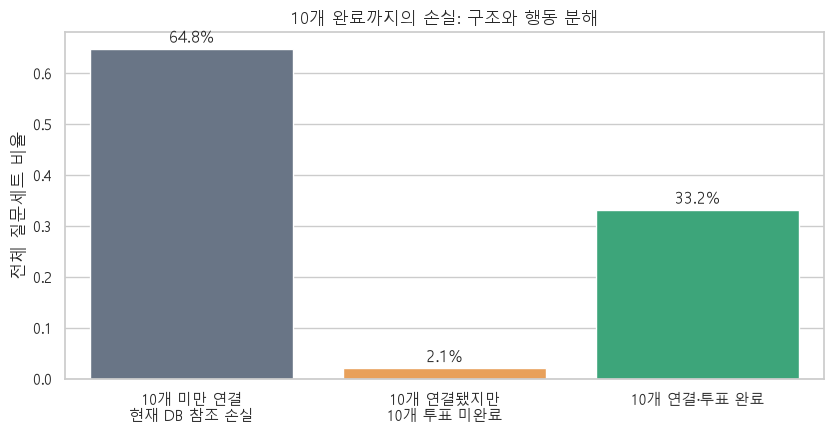

> **해석 경계:** 원천 질문세트의 기대 참조 수는 10개지만 현재 DB에서 연결되는 질문조각이 부족하다. 이는 실제 화면에서 10개 미만이 노출됐다는 증거가 아니라, 과거 질문조각 삭제·스냅샷 손실·참조 무결성 문제일 수 있다. 따라서 33.2%를 사용자 이탈률로 해석하지 않는다.

In [30]:
structure_decomp = con.execute("""
SELECT
  CASE WHEN mapped_pieces=0 THEN '0개 연결'
       WHEN mapped_pieces BETWEEN 1 AND 9 THEN '1~9개 연결'
       WHEN mapped_pieces=10 THEN '10개 연결'
       ELSE '11개 이상 연결' END AS structure_band,
  COUNT(*) question_sets,
  COUNT(*)/SUM(COUNT(*)) OVER() AS set_share,
  AVG(expected_piece_count) mean_expected_piece_count,
  AVG(any_vote_flag) any_vote_rate,
  AVG(vote_coverage) mean_vote_coverage,
  AVG(completed_10_proxy) complete10_rate
FROM may_set_metrics GROUP BY 1
ORDER BY MIN(mapped_pieces)
""").df()
display(save_table(structure_decomp,'60_completion_structure_decomposition'))

loss = con.execute("""
SELECT
  COUNT(*) total_sets,
  SUM(mapped_pieces<10) structurally_incomplete_sets,
  SUM(mapped_pieces>=10) structurally_complete_sets,
  SUM(mapped_pieces>=10 AND voted_pieces<10) behavior_incomplete_among_complete_structure,
  SUM(mapped_pieces>=10 AND voted_pieces>=10) complete10_sets,
  AVG(CASE WHEN mapped_pieces>=10 THEN CAST(voted_pieces>=10 AS INTEGER) END) behavior_completion_rate_given_structure
FROM may_set_metrics
""").df()
display(save_table(loss,'61_completion_loss_decomposition'))

plot_loss=pd.DataFrame({
  '구분':['10개 미만 연결\n현재 DB 참조 손실','10개 연결됐지만\n10개 투표 미완료','10개 연결·투표 완료'],
  'sets':[int(loss.structurally_incomplete_sets.iloc[0]),
          int(loss.behavior_incomplete_among_complete_structure.iloc[0]),
          int(loss.complete10_sets.iloc[0])]})
plot_loss['share']=plot_loss.sets/plot_loss.sets.sum()
plt.figure(figsize=(8.5,4.5)); ax=sns.barplot(data=plot_loss,x='구분',y='share',palette=[COLORS[5],COLORS[3],COLORS[2]])
ax.set_ylabel('전체 질문세트 비율'); ax.set_xlabel(''); ax.set_title('10개 완료까지의 손실: 구조와 행동 분해')
for p,v in zip(ax.patches,plot_loss.share): ax.text(p.get_x()+p.get_width()/2,v+.012,f'{v:.1%}',ha='center')
savefig('50_completion_loss_decomposition')
display(Markdown('> **해석 경계:** 원천 질문세트의 기대 참조 수는 10개지만 현재 DB에서 연결되는 질문조각이 부족하다. 이는 실제 화면에서 10개 미만이 노출됐다는 증거가 아니라, 과거 질문조각 삭제·스냅샷 손실·참조 무결성 문제일 수 있다. 따라서 33.2%를 사용자 이탈률로 해석하지 않는다.'))

## 8. 질문 이용 묶음과 재진입

30분 기준 질문 이용 묶음으로 같은 방문의 연속 소비와 이후 재진입을 구분한다.


In [31]:
con.execute("""
CREATE OR REPLACE TEMP VIEW qset_bursts_all AS
WITH o AS (
  SELECT owner_user_id,question_set_id,set_created_at,school_id,
         LAG(set_created_at) OVER(PARTITION BY owner_user_id ORDER BY set_created_at,question_set_id) prev_at
  FROM question_set_all
  WHERE eligible_set_flag=1 AND owner_user_id IS NOT NULL AND set_created_at IS NOT NULL
), tagged AS (
  SELECT *, CASE WHEN prev_at IS NULL OR set_created_at>prev_at+INTERVAL 30 MINUTE THEN 1 ELSE 0 END new_burst
  FROM o
)
SELECT *, SUM(new_burst) OVER(PARTITION BY owner_user_id ORDER BY set_created_at,question_set_id) AS burst_id
FROM tagged
""")
con.execute("""
CREATE OR REPLACE TEMP VIEW qset_burst_summary_all AS
WITH b AS (
  SELECT owner_user_id,burst_id,MIN(set_created_at) burst_start,MAX(set_created_at) burst_end,
         COUNT(*) qsets_in_burst,COUNT(DISTINCT CAST(set_created_at AS DATE)) active_days,
         ANY_VALUE(school_id) school_id
  FROM qset_bursts_all GROUP BY 1,2
)
SELECT *, LEAD(burst_start) OVER(PARTITION BY owner_user_id ORDER BY burst_start,burst_id) next_burst_start
FROM b
""")
first_may_burst=con.execute("""
WITH x AS (
  SELECT *,ROW_NUMBER() OVER(PARTITION BY owner_user_id ORDER BY burst_start,burst_id) rn_may
  FROM qset_burst_summary_all
  WHERE burst_start>=TIMESTAMP '2023-05-01' AND burst_start<TIMESTAMP '2023-06-01'
)
SELECT *,date_diff('minute',burst_end,next_burst_start)/60.0 hours_to_next_burst,
       CASE WHEN next_burst_start<=burst_end+INTERVAL 24 HOUR THEN 1 ELSE 0 END next_burst_24h,
       CASE WHEN next_burst_start<=burst_end+INTERVAL 72 HOUR THEN 1 ELSE 0 END next_burst_72h,
       CASE WHEN next_burst_start<=burst_end+INTERVAL 7 DAY THEN 1 ELSE 0 END next_burst_7d
FROM x WHERE rn_may=1
""").df()
display(save_table(first_may_burst,'62_first_may_question_burst'))

first_may_day=con.execute("""
WITH days AS (
  SELECT owner_user_id,CAST(set_created_at AS DATE) activity_date,ANY_VALUE(school_id) school_id,
         COUNT(*) qsets_in_day
  FROM question_set_all
  WHERE eligible_set_flag=1 AND owner_user_id IS NOT NULL AND set_created_at IS NOT NULL
  GROUP BY 1,2
), seq AS (
  SELECT *,LEAD(activity_date) OVER(PARTITION BY owner_user_id ORDER BY activity_date) next_activity_date
  FROM days
), may AS (
  SELECT *,ROW_NUMBER() OVER(PARTITION BY owner_user_id ORDER BY activity_date) rn_may
  FROM seq WHERE activity_date BETWEEN DATE '2023-05-01' AND DATE '2023-05-31'
)
SELECT *,CASE WHEN next_activity_date<=activity_date+7 THEN 1 ELSE 0 END next_active_day_7d
FROM may WHERE rn_may=1
""").df()
display(save_table(first_may_day,'62b_first_may_active_day'))

,owner_user_id,burst_id,burst_start,burst_end,qsets_in_burst,active_days,school_id,next_burst_start,rn_may,hours_to_next_burst,next_burst_24h,next_burst_72h,next_burst_7d
0,873256,1.0000,2023-05-02 23:29:49,2023-05-02 23:31:14,2,1,4516,2023-05-03 06:29:30,1,6.9667,1,1,1
1,873368,1.0000,2023-05-03 00:18:03,2023-05-03 00:24:54,2,1,369,2023-05-03 02:22:20,1,1.9667,1,1,1
2,873635,1.0000,2023-05-03 01:51:24,2023-05-03 01:52:55,2,1,369,2023-05-03 04:42:12,1,2.8333,1,1,1
3,874193,1.0000,2023-05-03 04:57:01,2023-05-03 04:57:01,1,1,369,2023-05-03 07:45:24,1,2.8000,1,1,1
4,874195,1.0000,2023-05-03 04:58:36,2023-05-03 04:58:36,1,1,369,2023-05-04 10:30:11,1,29.5333,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4904,1152216,1.0000,2023-05-11 23:17:57,2023-05-11 23:20:06,2,1,5372,2023-05-12 01:23:17,1,2.0500,1,1,1
4905,1152449,1.0000,2023-05-11 23:22:46,2023-05-11 23:22:46,1,1,5372,2023-05-12 02:10:27,1,2.8000,1,1,1
4906,1153519,1.0000,2023-05-11 23:52:25,2023-05-11 23:52:25,1,1,5372,2023-05-14 16:02:58,1,64.1667,0,1,1
4907,1154403,1.0000,2023-05-12 10:06:59,2023-05-12 10:06:59,1,1,5491,2023-05-14 02:14:28,1,40.1333,0,1,1


,owner_user_id,activity_date,school_id,qsets_in_day,next_activity_date,rn_may,next_active_day_7d
0,880518,2023-05-04,369,4,2023-05-05,1,1
1,881024,2023-05-04,271,1,2023-05-21,1,0
2,881242,2023-05-20,4426,3,2023-05-21,1,1
3,881968,2023-05-04,4516,2,2023-05-05,1,1
4,882427,2023-05-05,352,8,2023-05-06,1,1
...,...,...,...,...,...,...,...
4904,988878,2023-05-08,352,7,2023-05-09,1,1
4905,989228,2023-05-08,352,1,NaT,1,0
4906,993496,2023-05-08,1478,8,2023-05-09,1,1
4907,993992,2023-05-09,5520,3,2023-05-11,1,1


,next_qset_band,users,share
0,같은 30분 묶음,3223,0.6565
1,30분~24시간,1361,0.2772
2,1~3일,150,0.0306
3,3~7일,29,0.0059
4,7일 이후,25,0.0051
5,후속 세트 없음,121,0.0246


,지표,rate
0,다음 질문세트 24시간,0.9338
1,다음 질문세트 7일,0.9703
2,다음 30분 묶음 24시간,0.8890
3,다음 30분 묶음 7일,0.9542
4,다음 활성일 7일,0.9411


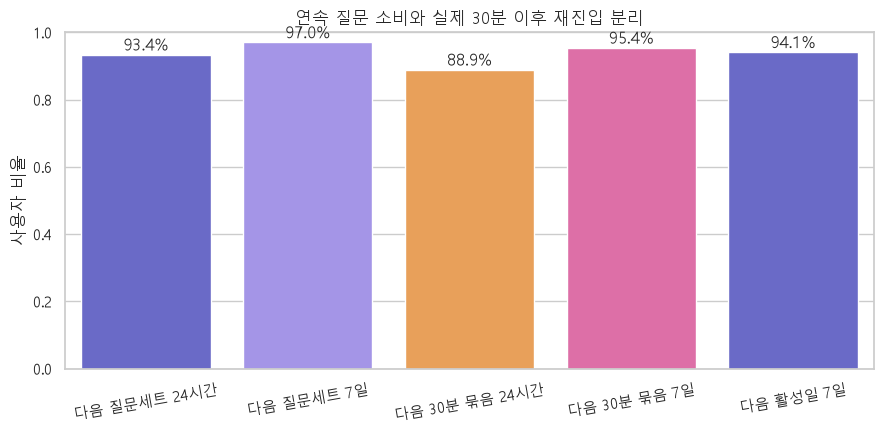

WindowsPath('C:/Users/lucy5/Desktop/team7/analysis/interaction_deep_dive/outputs/figures/51_same_burst_vs_return.png')

In [32]:
first_next=followup[['owner_user_id','hours_to_next','next_24h','next_72h','next_7d']].copy()
first_next['next_qset_band']=pd.cut(first_next.hours_to_next,
  [-np.inf,.5,24,72,168,np.inf],labels=['같은 30분 묶음','30분~24시간','1~3일','3~7일','7일 이후'])
first_next['next_qset_band']=first_next.next_qset_band.astype(object).fillna('후속 세트 없음')
band_order=['같은 30분 묶음','30분~24시간','1~3일','3~7일','7일 이후','후속 세트 없음']
next_band=first_next.groupby('next_qset_band').size().reindex(band_order,fill_value=0).rename('users').reset_index()
next_band['share']=next_band.users/next_band.users.sum()
display(save_table(next_band,'63_next_qset_interval_bands'))

continuation_compare=pd.DataFrame({
  '지표':['다음 질문세트 24시간','다음 질문세트 7일','다음 30분 묶음 24시간','다음 30분 묶음 7일','다음 활성일 7일'],
  'rate':[followup.next_24h.mean(),followup.next_7d.mean(),first_may_burst.next_burst_24h.mean(),first_may_burst.next_burst_7d.mean(),first_may_day.next_active_day_7d.mean()]})
display(save_table(continuation_compare,'64_same_burst_vs_return'))
plt.figure(figsize=(9,4.5)); ax=sns.barplot(data=continuation_compare,x='지표',y='rate',palette=[COLORS[0],COLORS[1],COLORS[3],COLORS[4]])
ax.set_ylim(0,1); ax.set_ylabel('사용자 비율'); ax.set_xlabel(''); ax.set_title('연속 질문 소비와 실제 30분 이후 재진입 분리')
for p,v in zip(ax.patches,continuation_compare.rate): ax.text(p.get_x()+p.get_width()/2,v+.012,f'{v:.1%}',ha='center')
plt.xticks(rotation=10); savefig('51_same_burst_vs_return')

## 9. 콘텐츠 지표와 이후 재진입


In [33]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

content_path=ROOT/'analysis'/'content_deep_dive'/'outputs'/'followup'/'qset_followup_features.csv.gz'
content_qset=pd.read_csv(content_path,parse_dates=['qset_at','next_qset_at'])
content_qset['question_set_id']=content_qset.question_set_id.astype(str)
user_day_outcomes=con.execute("""
WITH days AS (
  SELECT owner_user_id,CAST(set_created_at AS DATE) activity_date,ANY_VALUE(school_id) school_id,COUNT(*) qsets_in_day
  FROM question_set_all WHERE eligible_set_flag=1 AND owner_user_id IS NOT NULL AND set_created_at IS NOT NULL
  GROUP BY 1,2
), seq AS (
  SELECT *,LEAD(activity_date) OVER(PARTITION BY owner_user_id ORDER BY activity_date) next_activity_date FROM days
)
SELECT *,CASE WHEN next_activity_date<=activity_date+7 THEN 1 ELSE 0 END next_active_day_7d
FROM seq WHERE activity_date BETWEEN DATE '2023-05-01' AND DATE '2023-05-31'
""").df()
user_day_outcomes['owner_user_id']=user_day_outcomes.owner_user_id.astype(str)
user_day_outcomes['activity_date']=pd.to_datetime(user_day_outcomes.activity_date)
cq=content_qset[content_qset.month.eq('2023-05')].copy()
cq['owner_user_id']=cq.owner_user_id.astype(str)
cq['activity_date']=cq.qset_at.dt.normalize()
day_content=cq.groupby(['owner_user_id','activity_date']).agg(
  mean_exhaustion=('content_exhaustion_index','mean'),mean_semantic_repeat=('semantic_repeat_rate','mean'),
  mean_theme_diversity=('theme_diversity','mean'),mean_semantic_novelty=('mean_semantic_novelty','mean'),
  mean_candidate_entropy=('candidate_relation_entropy','mean'),mean_candidate_unique=('candidate_unique_ratio','mean'),
  mean_vote_rate=('vote_rate','mean'),content_qsets=('question_set_id','nunique')).reset_index()
burst_content=day_content.merge(user_day_outcomes,on=['owner_user_id','activity_date'],how='inner')
for c in ['mean_exhaustion','mean_semantic_repeat','mean_theme_diversity','mean_semantic_novelty','mean_candidate_entropy','mean_candidate_unique','mean_vote_rate']:
    burst_content['z_'+c]=(burst_content[c]-burst_content[c].mean())/burst_content[c].std()
burst_content['log_qsets']=np.log1p(burst_content.qsets_in_day)
burst_content['start_day']=burst_content.activity_date.dt.day
model_cols=['z_mean_exhaustion','z_mean_semantic_repeat','z_mean_theme_diversity','z_mean_semantic_novelty','z_mean_candidate_entropy','z_mean_candidate_unique','log_qsets','start_day']
bm=burst_content.dropna(subset=['next_active_day_7d']+model_cols).copy()
fit=smf.glm('next_active_day_7d ~ z_mean_exhaustion + z_mean_semantic_repeat + z_mean_theme_diversity + z_mean_semantic_novelty + z_mean_candidate_entropy + z_mean_candidate_unique + log_qsets + start_day + C(school_id)',data=bm,family=sm.families.Binomial()).fit(cov_type='cluster',cov_kwds={'groups':bm.owner_user_id})
keep=[x for x in fit.params.index if x in model_cols]
content_return_model=pd.DataFrame({'feature':keep,'coef':fit.params[keep],'odds_ratio':np.exp(fit.params[keep]),
  'ci_low':np.exp(fit.conf_int().loc[keep,0]),'ci_high':np.exp(fit.conf_int().loc[keep,1]),'p_value':fit.pvalues[keep]}).reset_index(drop=True)
display(save_table(content_return_model,'65_content_to_next_active_day_model'))
exhaustion_row=content_return_model[content_return_model.feature.eq('z_mean_exhaustion')].iloc[0]
novelty_row=content_return_model[content_return_model.feature.eq('z_mean_semantic_novelty')].iloc[0]
display(Markdown(f'> 학교·활동일·당일 이용량을 보정하면 종합 소진 지수(p={exhaustion_row.p_value:.3f})와 의미 신규성(p={novelty_row.p_value:.3f})은 다음 활성일 감소의 유의한 근거가 아니다. 반복·다양성의 양의 계수도 활동적인 사용자의 선택 효과가 남을 수 있으므로 제품 효과로 해석하지 않는다.'))

,feature,coef,odds_ratio,ci_low,ci_high,p_value
0,z_mean_exhaustion,0.0796,1.0828,0.8543,1.3724,0.5105
1,z_mean_semantic_repeat,0.2018,1.2236,1.0734,1.3948,0.0025
2,z_mean_theme_diversity,0.2316,1.2606,1.1169,1.4227,0.0002
3,z_mean_semantic_novelty,-0.0106,0.9894,0.9552,1.0249,0.5547
4,z_mean_candidate_entropy,0.0754,1.0784,1.0195,1.1406,0.0084
5,z_mean_candidate_unique,-0.3094,0.7339,0.6221,0.8658,0.0002
6,log_qsets,1.4597,4.3047,3.8950,4.7576,0.0000
7,start_day,-0.0473,0.9538,0.9470,0.9605,0.0000


> 학교·활동일·당일 이용량을 보정하면 종합 소진 지수(p=0.511)와 의미 신규성(p=0.555)은 다음 활성일 감소의 유의한 근거가 아니다. 반복·다양성의 양의 계수도 활동적인 사용자의 선택 효과가 남을 수 있으므로 제품 효과로 해석하지 않는다.

,exhaustion_quintile,user_days,users,mean_exhaustion,next_active_day_7d,mean_qsets
0,"(0.242, 0.419]",8294,3074,0.3595,0.8406,2.6461
1,"(0.419, 0.478]",8214,3355,0.4506,0.9206,3.5072
2,"(0.478, 0.522]",8254,3521,0.5001,0.9021,3.7674
3,"(0.522, 0.57]",8312,3265,0.5455,0.9155,3.9533
4,"(0.57, 0.929]",8196,2622,0.6168,0.8954,3.4308


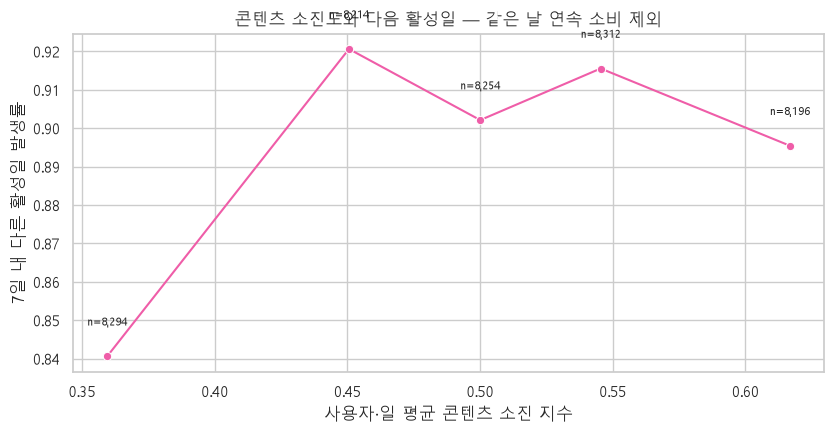

WindowsPath('C:/Users/lucy5/Desktop/team7/analysis/interaction_deep_dive/outputs/figures/52_exhaustion_true_return.png')

In [34]:
burst_content['exhaustion_quintile']=pd.qcut(burst_content.mean_exhaustion,5,duplicates='drop')
exhaustion_return=burst_content.groupby('exhaustion_quintile',observed=True).agg(
  user_days=('activity_date','size'),users=('owner_user_id','nunique'),mean_exhaustion=('mean_exhaustion','mean'),
  next_active_day_7d=('next_active_day_7d','mean'),mean_qsets=('qsets_in_day','mean')).reset_index()
display(save_table(exhaustion_return,'66_exhaustion_and_true_return'))
plt.figure(figsize=(8.5,4.5)); ax=sns.lineplot(data=exhaustion_return,x='mean_exhaustion',y='next_active_day_7d',marker='o',color=COLORS[4])
ax.set_xlabel('사용자·일 평균 콘텐츠 소진 지수'); ax.set_ylabel('7일 내 다른 활성일 발생률')
ax.set_title('콘텐츠 소진도와 다음 활성일 — 같은 날 연속 소비 제외')
for _,r in exhaustion_return.iterrows(): ax.text(r.mean_exhaustion,r.next_active_day_7d+.008,f'n={int(r.user_days):,}',ha='center',fontsize=8)
savefig('52_exhaustion_true_return')

## 10. 첫 투표 수신 전후 질문 재진입


,window,recipients,mean_bursts_before,mean_bursts_after,active_share_difference,wilcoxon_stat,p_value
0,24시간,10225,0.3372,2.1657,0.0248,"111,925.0000",0.0000
1,7일,10225,0.3519,8.2682,0.0473,"22,626.5000",0.0000


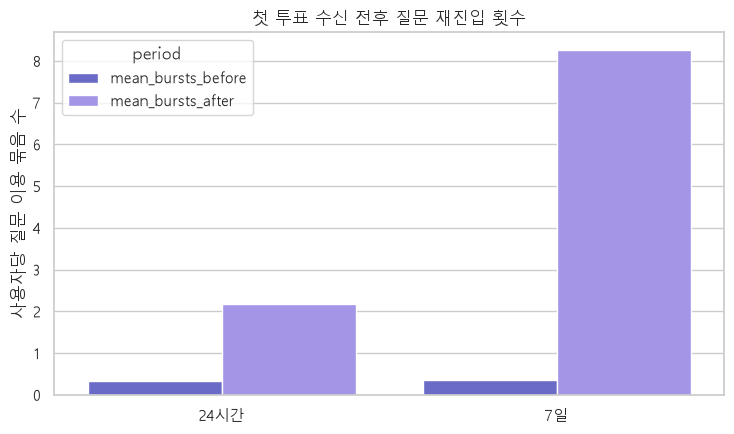

> 투표 수신은 무작위 사건이 아니므로 전후 차이는 인과효과가 아니다. 다만 `선택받음 → 다시 질문 사용` 루프의 시간순 가능성을 확인하는 근거로만 사용한다.

In [35]:
vote_event_study=con.execute("""
WITH r AS (
  SELECT chosen_user_id user_id,MIN(vote_at) first_received_at,COUNT(*) received_votes
  FROM vote_may WHERE eligible_vote_flag=1 AND chosen_user_id IS NOT NULL GROUP BY 1
), eligible_r AS (
  SELECT * FROM r WHERE first_received_at>=TIMESTAMP '2023-05-05' AND first_received_at<TIMESTAMP '2023-05-25'
)
SELECT r.user_id,r.first_received_at,r.received_votes,
  SUM(CASE WHEN b.burst_start>=r.first_received_at-INTERVAL 7 DAY AND b.burst_start<r.first_received_at THEN 1 ELSE 0 END) bursts_before_7d,
  SUM(CASE WHEN b.burst_start>r.first_received_at AND b.burst_start<=r.first_received_at+INTERVAL 7 DAY THEN 1 ELSE 0 END) bursts_after_7d,
  SUM(CASE WHEN b.burst_start>=r.first_received_at-INTERVAL 24 HOUR AND b.burst_start<r.first_received_at THEN 1 ELSE 0 END) bursts_before_24h,
  SUM(CASE WHEN b.burst_start>r.first_received_at AND b.burst_start<=r.first_received_at+INTERVAL 24 HOUR THEN 1 ELSE 0 END) bursts_after_24h
FROM eligible_r r LEFT JOIN qset_burst_summary_all b ON b.owner_user_id=r.user_id
GROUP BY ALL
""").df()
paired=[]
for before,after,window in [('bursts_before_24h','bursts_after_24h','24시간'),('bursts_before_7d','bursts_after_7d','7일')]:
    nz=(vote_event_study[before]!=vote_event_study[after])
    stat,p=stats.wilcoxon(vote_event_study.loc[nz,before],vote_event_study.loc[nz,after]) if nz.any() else (np.nan,np.nan)
    paired.append([window,len(vote_event_study),vote_event_study[before].mean(),vote_event_study[after].mean(),
                   (vote_event_study[after]>0).mean()-(vote_event_study[before]>0).mean(),stat,p])
vote_event_summary=pd.DataFrame(paired,columns=['window','recipients','mean_bursts_before','mean_bursts_after','active_share_difference','wilcoxon_stat','p_value'])
display(save_table(vote_event_summary,'67_first_vote_received_event_study'))
evt=vote_event_summary.melt(id_vars='window',value_vars=['mean_bursts_before','mean_bursts_after'],var_name='period',value_name='mean_bursts')
plt.figure(figsize=(7.5,4.5)); sns.barplot(data=evt,x='window',y='mean_bursts',hue='period',palette=COLORS[:2])
plt.ylabel('사용자당 질문 이용 묶음 수'); plt.xlabel(''); plt.title('첫 투표 수신 전후 질문 재진입 횟수')
savefig('53_vote_received_event_study')
display(Markdown('> 투표 수신은 무작위 사건이 아니므로 전후 차이는 인과효과가 아니다. 다만 `선택받음 → 다시 질문 사용` 루프의 시간순 가능성을 확인하는 근거로만 사용한다.'))

## 11. 질문 시작 이후 결과 유형


,outcome_type,visits,notice_after_complete,share
0,스킵만,11815,0.0001,0.0585
1,완료·스킵 모두,98050,0.0893,0.4852
2,완료·스킵 없음,41240,0.0002,0.2041
3,완료만,50967,0.1119,0.2522


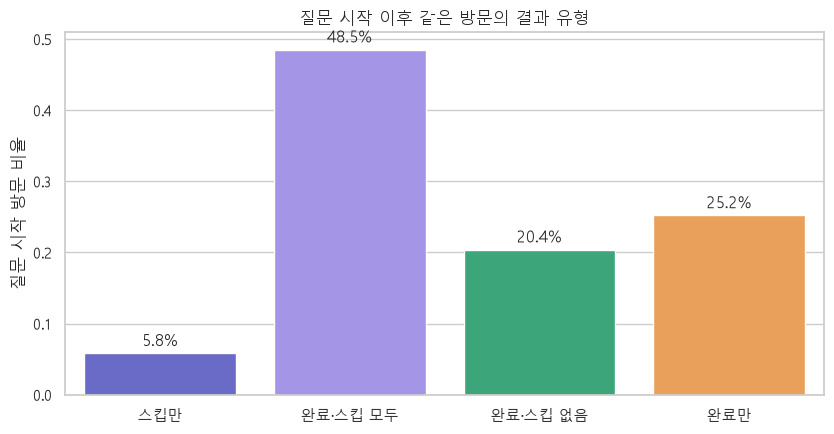

> 완료와 스킵이 모두 있는 방문은 오류가 아니라 한 방문에서 여러 질문을 처리한 결과일 수 있다. 질문 ID로 시작·완료·스킵을 직접 연결할 수 없으므로 이 표는 질문 단위가 아닌 방문 단위 결과다.

In [36]:
question_outcomes=con.execute("""
WITH m AS (
  SELECT visit_id,
    MIN(event_order) FILTER(WHERE category='03_질문시작') start_order,
    MIN(event_order) FILTER(WHERE category='05_질문완료') complete_order,
    MIN(event_order) FILTER(WHERE category='06_질문스킵') skip_order,
    MIN(event_order) FILTER(WHERE category='07_알림센터') alarm_order,
    MIN(event_order) FILTER(WHERE category='08_알림상세') notice_order
  FROM hackle_event_labeled GROUP BY 1
)
SELECT *,
  CASE WHEN complete_order>start_order THEN 1 ELSE 0 END complete_after_start,
  CASE WHEN skip_order>start_order THEN 1 ELSE 0 END skip_after_start,
  CASE WHEN complete_order>start_order AND skip_order>start_order THEN '완료·스킵 모두'
       WHEN complete_order>start_order THEN '완료만'
       WHEN skip_order>start_order THEN '스킵만'
       ELSE '완료·스킵 없음' END outcome_type,
  CASE WHEN complete_order IS NOT NULL AND notice_order>complete_order THEN 1 ELSE 0 END notice_after_complete,
  CASE WHEN complete_order IS NOT NULL AND alarm_order>complete_order THEN 1 ELSE 0 END alarm_after_complete
FROM m WHERE start_order IS NOT NULL
""").df()
outcome_summary=question_outcomes.groupby('outcome_type').agg(visits=('visit_id','nunique'),
  notice_after_complete=('notice_after_complete','mean')).reset_index()
outcome_summary['share']=outcome_summary.visits/outcome_summary.visits.sum()
display(save_table(outcome_summary,'68_question_start_outcome_types'))
plt.figure(figsize=(8.5,4.5)); ax=sns.barplot(data=outcome_summary,x='outcome_type',y='share',palette=COLORS[:len(outcome_summary)])
ax.set_ylabel('질문 시작 방문 비율'); ax.set_xlabel(''); ax.set_title('질문 시작 이후 같은 방문의 결과 유형')
for p,v in zip(ax.patches,outcome_summary.share): ax.text(p.get_x()+p.get_width()/2,v+.01,f'{v:.1%}',ha='center')
savefig('54_question_outcome_types')
display(Markdown('> 완료와 스킵이 모두 있는 방문은 오류가 아니라 한 방문에서 여러 질문을 처리한 결과일 수 있다. 질문 ID로 시작·완료·스킵을 직접 연결할 수 없으므로 이 표는 질문 단위가 아닌 방문 단위 결과다.'))

## 12. 질문·결과 단계 소요시간


,transition_name,transition_count,median_seconds,p75_seconds,p90_seconds
0,알림센터→알림상세,127632,3.0000,4.0000,7.0000
1,질문시작→스킵,109485,15.0000,38.0000,72.0000
2,완료→알림센터,17797,16.0000,91.0000,494.0000
3,완료→알림상세,14156,17.0000,90.0000,514.5000
4,진입→질문시작,200717,18.0000,76.0000,254.0000
5,질문시작→완료,148761,75.0000,100.0000,149.0000


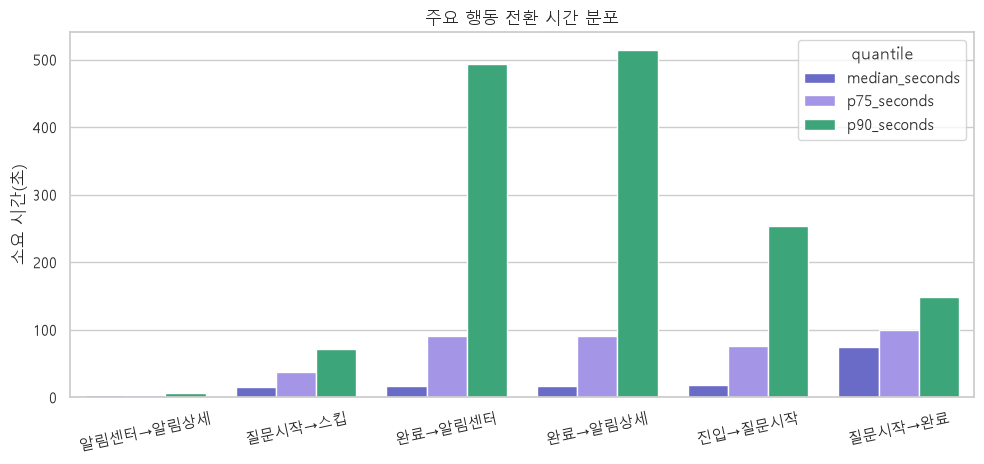

> 한 방문에 동일 이벤트가 여러 번 있을 수 있어 최초 이벤트 간 소요시간으로 계산했다. 개별 질문 한 건의 처리시간으로 해석하지 않는다.

In [37]:
transition_times=con.execute("""
WITH firsts AS (
  SELECT visit_id,
    MIN(event_at) FILTER(WHERE category='03_질문시작') qstart_at,
    MIN(event_at) FILTER(WHERE category='05_질문완료') complete_at,
    MIN(event_at) FILTER(WHERE category='06_질문스킵') skip_at,
    MIN(event_at) FILTER(WHERE category='07_알림센터') alarm_at,
    MIN(event_at) FILTER(WHERE category='08_알림상세') notice_at
  FROM hackle_event_labeled GROUP BY 1
), long AS (
  SELECT '진입→질문시작' AS transition_name,date_diff('second',v.visit_start,f.qstart_at) AS elapsed_seconds
  FROM firsts f JOIN hackle_visit_core v USING(visit_id) WHERE f.qstart_at>=v.visit_start
  UNION ALL SELECT '질문시작→완료',date_diff('second',qstart_at,complete_at) FROM firsts WHERE complete_at>qstart_at
  UNION ALL SELECT '질문시작→스킵',date_diff('second',qstart_at,skip_at) FROM firsts WHERE skip_at>qstart_at
  UNION ALL SELECT '완료→알림센터',date_diff('second',complete_at,alarm_at) FROM firsts WHERE alarm_at>complete_at
  UNION ALL SELECT '완료→알림상세',date_diff('second',complete_at,notice_at) FROM firsts WHERE notice_at>complete_at
  UNION ALL SELECT '알림센터→알림상세',date_diff('second',alarm_at,notice_at) FROM firsts WHERE notice_at>alarm_at
)
SELECT transition_name,COUNT(*) transition_count,median(elapsed_seconds) median_seconds,
       quantile_cont(elapsed_seconds,.75) p75_seconds,quantile_cont(elapsed_seconds,.9) p90_seconds
FROM long WHERE elapsed_seconds BETWEEN 0 AND 1800 GROUP BY 1 ORDER BY median_seconds
""").df()
display(save_table(transition_times,'69_interaction_transition_times'))
tt=transition_times.melt(id_vars=['transition_name','transition_count'],value_vars=['median_seconds','p75_seconds','p90_seconds'],var_name='quantile',value_name='seconds')
plt.figure(figsize=(10,4.8)); sns.barplot(data=tt,x='transition_name',y='seconds',hue='quantile',palette=COLORS[:3])
plt.ylabel('소요 시간(초)'); plt.xlabel(''); plt.xticks(rotation=12); plt.title('주요 행동 전환 시간 분포')
savefig('55_interaction_transition_times')
display(Markdown('> 한 방문에 동일 이벤트가 여러 번 있을 수 있어 최초 이벤트 간 소요시간으로 계산했다. 개별 질문 한 건의 처리시간으로 해석하지 않는다.'))

## 13. 질문 완료 직후 행동


,next_action,visits,action_share
0,EXIT,39308,0.2618
1,09_타임라인,27358,0.1822
2,04_질문상호작용,21095,0.1405
3,06_질문스킵,14267,0.0950
4,10_랩,11362,0.0757
5,02_질문화면,8032,0.0535
6,07_알림센터,8005,0.0533
7,11_프로필,7455,0.0497
8,13_대화,5673,0.0378
9,01_진입,5159,0.0344


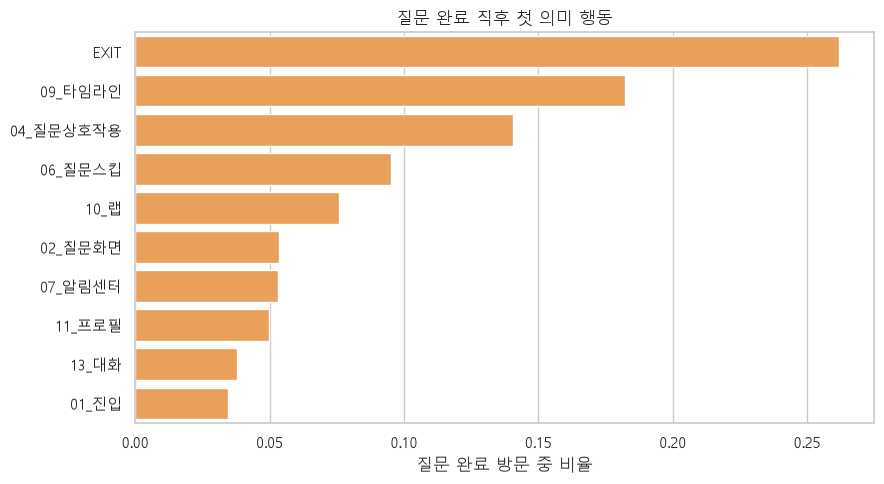

,notice_visits,later_question_start_rate,later_question_complete_rate,later_friend_action_rate
0,129925,0.2210,0.1603,0.0752


In [38]:
post_complete=con.execute("""
WITH c AS (
  SELECT visit_id,MIN(event_order) complete_order FROM hackle_event_labeled
  WHERE category='05_질문완료' GROUP BY 1
), afters AS (
  SELECT e.visit_id,e.category,e.event_order,
         ROW_NUMBER() OVER(PARTITION BY e.visit_id ORDER BY e.event_order,e.event_sk) rn
  FROM c JOIN hackle_event_labeled e USING(visit_id)
  WHERE e.event_order>c.complete_order AND e.category NOT IN ('98_세션종료','99_기타')
)
SELECT COALESCE(a.category,'EXIT') next_action,COUNT(*) visits,
       COUNT(*)/SUM(COUNT(*)) OVER() action_share
FROM c LEFT JOIN afters a ON a.visit_id=c.visit_id AND a.rn=1
GROUP BY 1 ORDER BY visits DESC
""").df()
display(save_table(post_complete,'70_first_action_after_complete'))
plt.figure(figsize=(9,5)); top=post_complete.head(10)
sns.barplot(data=top,y='next_action',x='action_share',color=COLORS[3]); plt.xlabel('질문 완료 방문 중 비율'); plt.ylabel('')
plt.title('질문 완료 직후 첫 의미 행동'); savefig('56_first_action_after_complete')

post_notice=con.execute("""
WITH n AS (
  SELECT visit_id,MIN(event_order) notice_order FROM hackle_event_labeled WHERE category='08_알림상세' GROUP BY 1
)
SELECT COUNT(*) notice_visits,
  AVG(CAST(EXISTS(SELECT 1 FROM hackle_event_labeled e WHERE e.visit_id=n.visit_id AND e.event_order>n.notice_order AND e.category='03_질문시작') AS INTEGER)) later_question_start_rate,
  AVG(CAST(EXISTS(SELECT 1 FROM hackle_event_labeled e WHERE e.visit_id=n.visit_id AND e.event_order>n.notice_order AND e.category='05_질문완료') AS INTEGER)) later_question_complete_rate,
  AVG(CAST(EXISTS(SELECT 1 FROM hackle_event_labeled e WHERE e.visit_id=n.visit_id AND e.event_order>n.notice_order AND e.category='12_친구행동') AS INTEGER)) later_friend_action_rate
FROM n
""").df()
display(save_table(post_notice,'71_action_after_notice_detail'))

## 14. 첫 방문 경로와 7일 재방문


,path_text,users,revisit_7d,ci_low,ci_high
0,01_진입,33558,0.5948,0.5896,0.6001
1,01_진입 → 04_질문상호작용,3179,0.5030,0.4856,0.5204
2,01_진입 → 09_타임라인 → 10_랩 → 11_프로필 → 10_랩,1674,0.4229,0.3995,0.4468
3,01_진입 → 02_질문화면 → 09_타임라인 → 10_랩 → 11_프로필,1615,0.3406,0.3178,0.3640
4,01_진입 → 07_알림센터 → 08_알림상세,1293,0.4470,0.4201,0.4742
5,01_진입 → 02_질문화면,1102,0.3739,0.3458,0.4028
6,01_진입 → 02_질문화면 → 09_타임라인 → 02_질문화면 → 09_타임라인,933,0.3065,0.2778,0.3369
7,01_진입 → 04_질문상호작용 → 09_타임라인 → 10_랩 → 11_프로필,810,0.4432,0.4093,0.4776
8,01_진입 → 09_타임라인 → 10_랩 → 11_프로필,794,0.3829,0.3497,0.4172
9,01_진입 → 09_타임라인 → 02_질문화면 → 10_랩 → 11_프로필,719,0.4381,0.4023,0.4746


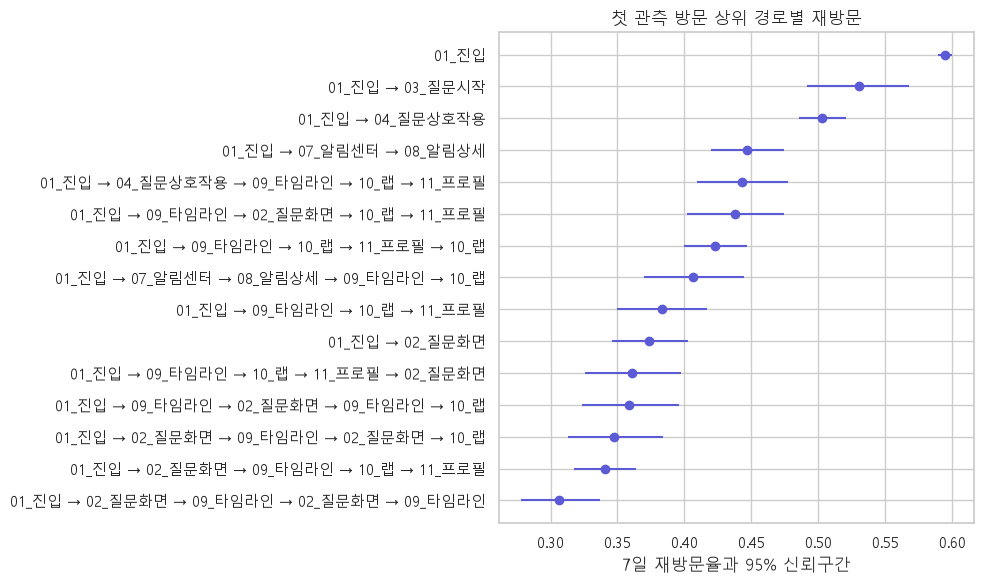

WindowsPath('C:/Users/lucy5/Desktop/team7/analysis/interaction_deep_dive/outputs/figures/57_first_visit_paths_revisit.png')

In [39]:
path_revisit=con.execute("""
WITH iv AS (
  SELECT *,ROW_NUMBER() OVER(PARTITION BY user_id ORDER BY visit_start,visit_id) rn,
         LEAD(visit_start) OVER(PARTITION BY user_id ORDER BY visit_start,visit_id) next_visit
  FROM hackle_visit_core
  WHERE identity_status='IDENTIFIED_SERVICE_USER' AND user_id IS NOT NULL AND COALESCE(is_staff,0)=0 AND COALESCE(is_superuser,0)=0
), firstv AS (SELECT * FROM iv WHERE rn=1), raw AS (
  SELECT e.visit_id,e.event_order,e.category,
         LAG(e.category) OVER(PARTITION BY e.visit_id ORDER BY e.event_order,e.event_sk) prev_cat
  FROM hackle_event_labeled e JOIN firstv f USING(visit_id)
  WHERE e.category NOT IN ('98_세션종료','99_기타')
), collapsed AS (
  SELECT *,ROW_NUMBER() OVER(PARTITION BY visit_id ORDER BY event_order) seq
  FROM raw WHERE prev_cat IS NULL OR category<>prev_cat
), paths AS (
  SELECT visit_id,STRING_AGG(category,' → ' ORDER BY seq) FILTER(WHERE seq<=5) path_text
  FROM collapsed GROUP BY 1
)
SELECT p.path_text,COUNT(*) users,
       AVG(CASE WHEN f.next_visit<=f.visit_start+INTERVAL 7 DAY THEN 1 ELSE 0 END) revisit_7d
FROM paths p JOIN firstv f USING(visit_id)
WHERE f.visit_start<=(SELECT MAX(visit_start)-INTERVAL 7 DAY FROM hackle_visit_core)
GROUP BY 1 HAVING COUNT(*)>=200 ORDER BY users DESC LIMIT 25
""").df()
z=1.96; n=path_revisit.users; ph=path_revisit.revisit_7d
den=1+z*z/n; center=(ph+z*z/(2*n))/den; half=z*np.sqrt(ph*(1-ph)/n+z*z/(4*n*n))/den
path_revisit['ci_low']=center-half; path_revisit['ci_high']=center+half
display(save_table(path_revisit,'72_first_visit_paths_revisit'))
plt.figure(figsize=(10,6)); top=path_revisit.head(15).sort_values('revisit_7d')
plt.errorbar(top.revisit_7d,range(len(top)),xerr=[top.revisit_7d-top.ci_low,top.ci_high-top.revisit_7d],fmt='o',color=COLORS[0])
plt.yticks(range(len(top)),top.path_text); plt.xlabel('7일 재방문율과 95% 신뢰구간'); plt.title('첫 관측 방문 상위 경로별 재방문')
savefig('57_first_visit_paths_revisit')

## 15. 방문 깊이별 완료와 재방문


,event_depth_q,not_complete,complete,n_not_complete,n_complete,pp_difference
0,Q1,0.5662,1.0000,23479,5,0.4338
1,Q2,0.5482,0.6296,22863,621,0.0814
2,Q3,0.4294,0.6408,20825,2659,0.2115
3,Q4,0.3802,0.6119,19745,3739,0.2317
4,Q5,0.4084,0.6020,16747,6737,0.1936


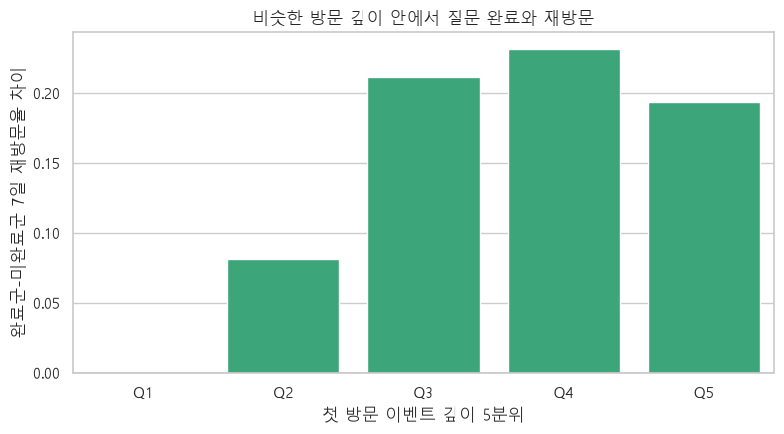

,feature,coef,odds_ratio,ci_low,ci_high,p_value
question_complete_flag,question_complete_flag,0.1897,1.2088,1.1410,1.2807,0.0000
question_skip_flag,question_skip_flag,-0.0983,0.9064,0.8513,0.9651,0.0022
question_surface_flag,question_surface_flag,-0.7407,0.4768,0.4583,0.4960,0.0000
alarm_center_flag,alarm_center_flag,-0.8111,0.4444,0.4249,0.4647,0.0000
notice_detail_flag,notice_detail_flag,0.0429,1.0439,0.9951,1.0951,0.0788
browse_flag,browse_flag,-0.7972,0.4506,0.4314,0.4706,0.0000
friend_flag,friend_flag,0.1629,1.1770,1.1097,1.2484,0.0000
chat_flag,chat_flag,-0.0864,0.9172,0.8831,0.9526,0.0000
log_events,log_events,-0.6232,0.5362,0.5102,0.5637,0.0000
log_duration,log_duration,0.2987,1.3481,1.3334,1.3630,0.0000


> 방문 깊이 층화와 회귀 보정은 관찰 가능한 활동량 차이를 줄이는 검증이다. 질문 완료의 인과효과를 증명하는 분석은 아니다.

In [40]:
adj=revisit_cohort.copy()
adj['event_depth_q']=pd.qcut(adj.event_count.rank(method='first'),5,labels=['Q1','Q2','Q3','Q4','Q5'])
depth_effect=adj.groupby(['event_depth_q','question_complete_flag'],observed=True).agg(
  users=('user_id','nunique'),revisit_7d=('next_7d','mean'),median_events=('event_count','median')).reset_index()
depth_pivot=depth_effect.pivot(index='event_depth_q',columns='question_complete_flag',values='revisit_7d').reset_index()
depth_pivot.columns=['event_depth_q','not_complete','complete']
depth_n=depth_effect.pivot(index='event_depth_q',columns='question_complete_flag',values='users').reset_index()
depth_n.columns=['event_depth_q','n_not_complete','n_complete']
depth_pivot=depth_pivot.merge(depth_n,on='event_depth_q',how='left')
depth_pivot['pp_difference']=depth_pivot.complete-depth_pivot.not_complete
display(save_table(depth_pivot,'73_depth_stratified_completion_revisit'))
depth_plot=depth_pivot[(depth_pivot.n_complete>=100)&(depth_pivot.n_not_complete>=100)].copy()
plt.figure(figsize=(8,4.5)); ax=sns.barplot(data=depth_plot,x='event_depth_q',y='pp_difference',color=COLORS[2])
plt.axhline(0,color='black',lw=1); plt.ylabel('완료군-미완료군 7일 재방문율 차이'); plt.xlabel('첫 방문 이벤트 깊이 5분위')
plt.title('비슷한 방문 깊이 안에서 질문 완료와 재방문')
savefig('58_depth_stratified_completion_revisit')

adj['log_events']=np.log1p(adj.event_count); adj['log_duration']=np.log1p(adj.duration_seconds.clip(lower=0))
formula='next_7d ~ question_complete_flag + question_skip_flag + question_surface_flag + alarm_center_flag + notice_detail_flag + browse_flag + friend_flag + chat_flag + log_events + log_duration + distinct_event_count'
afit=smf.glm(formula,data=adj,family=sm.families.Binomial()).fit(cov_type='HC3')
keep=['question_complete_flag','question_skip_flag','question_surface_flag','alarm_center_flag','notice_detail_flag','browse_flag','friend_flag','chat_flag','log_events','log_duration','distinct_event_count']
adjusted=pd.DataFrame({'feature':keep,'coef':afit.params[keep],'odds_ratio':np.exp(afit.params[keep]),
  'ci_low':np.exp(afit.conf_int().loc[keep,0]),'ci_high':np.exp(afit.conf_int().loc[keep,1]),'p_value':afit.pvalues[keep]})
display(save_table(adjusted,'74_adjusted_revisit_associations'))
display(Markdown('> 방문 깊이 층화와 회귀 보정은 관찰 가능한 활동량 차이를 줄이는 검증이다. 질문 완료의 인과효과를 증명하는 분석은 아니다.'))

## 16. 앱 버전별 강건성


,app_version,visits,question_start_rate,complete_after_start_all_visit_rate,complete_given_start,notice_given_complete
0,MISSING,590419,0.2466,0.1913,0.7757,0.0940
1,2.0.5,253301,0.1983,0.1280,0.6451,0.1066
2,2.0.3,41926,0.1490,0.0878,0.5892,0.1160


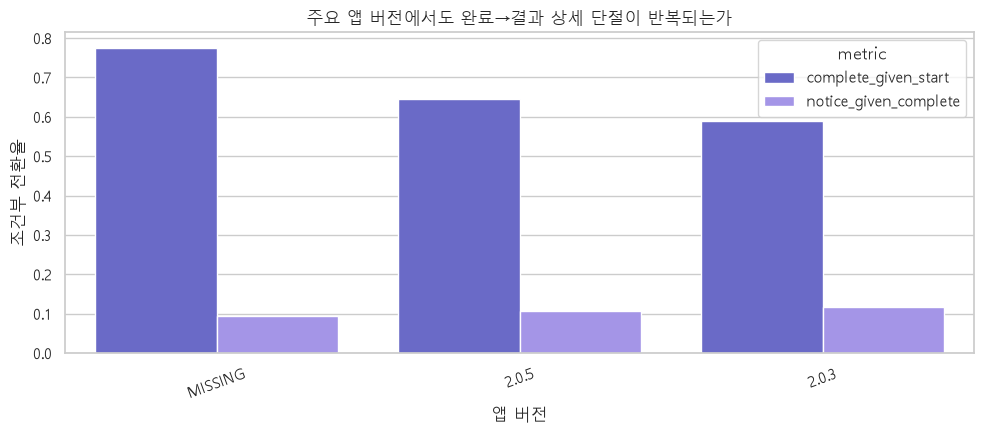

WindowsPath('C:/Users/lucy5/Desktop/team7/analysis/interaction_deep_dive/outputs/figures/59_app_version_flow_robustness.png')

In [41]:
version_flow=con.execute("""
WITH o AS (
  SELECT visit_id,
    MIN(event_order) FILTER(WHERE category='03_질문시작') s,
    MIN(event_order) FILTER(WHERE category='05_질문완료') c,
    MIN(event_order) FILTER(WHERE category='08_알림상세') n
  FROM hackle_event_labeled GROUP BY 1
)
SELECT COALESCE(v.app_version,'MISSING') app_version,COUNT(*) visits,
  AVG(CASE WHEN o.s IS NOT NULL THEN 1 ELSE 0 END) question_start_rate,
  AVG(CASE WHEN o.c>o.s THEN 1 ELSE 0 END) complete_after_start_all_visit_rate,
  AVG(CASE WHEN o.s IS NOT NULL THEN CASE WHEN o.c>o.s THEN 1 ELSE 0 END END) complete_given_start,
  AVG(CASE WHEN o.c IS NOT NULL THEN CASE WHEN o.n>o.c THEN 1 ELSE 0 END END) notice_given_complete
FROM hackle_visit_core v JOIN o USING(visit_id)
GROUP BY 1 HAVING COUNT(*)>=10000 ORDER BY visits DESC
""").df()
display(save_table(version_flow,'75_app_version_flow_robustness'))
vv=version_flow.melt(id_vars=['app_version','visits'],value_vars=['complete_given_start','notice_given_complete'],var_name='metric',value_name='rate')
plt.figure(figsize=(10,4.5)); sns.barplot(data=vv,x='app_version',y='rate',hue='metric',palette=COLORS[:2])
plt.ylabel('조건부 전환율'); plt.xlabel('앱 버전'); plt.xticks(rotation=20); plt.title('주요 앱 버전에서도 완료→결과 상세 단절이 반복되는가')
savefig('59_app_version_flow_robustness')

## 17. 분석 요약


In [42]:
true_return_7d=float(first_may_day.next_active_day_7d.mean())
same_burst=float((first_next.hours_to_next<=.5).mean())
struct_loss=float(loss.structurally_incomplete_sets.iloc[0]/loss.total_sets.iloc[0])
behavior_complete=float(loss.behavior_completion_rate_given_structure.iloc[0])
complete_or=float(adjusted.loc[adjusted.feature.eq('question_complete_flag'),'odds_ratio'].iloc[0])
notice_after=float(post_notice.later_question_start_rate.iloc[0])
advanced_evidence=pd.DataFrame([
  ['완료율 분해',f'현재 DB에서 10개 미만 연결 {struct_loss:.1%}; 10개 연결 세트의 투표 완료 {behavior_complete:.1%}','사용자 이탈 결론 보류, 원천 참조 무결성과 실제 노출 로그 우선 확인'],
  ['연속 소비와 재진입 분리',f'첫 세트 다음 행동 중 같은 30분 묶음 {same_burst:.1%}; 7일 내 다음 활성일 {true_return_7d:.1%}','같은 날 자동 연속과 다른 날 재방문 KPI를 분리'],
  ['Content→Interaction',f'보정 후 종합 소진·신규성은 다음 활성일 감소의 유의한 근거 없음','빈도 제한·다양성 슬롯은 확정안이 아니라 A/B 테스트 가설로 유지'],
  ['선택받음 루프','첫 투표 수신 전후 질문 묶음 변화는 시간순 근거이나 비무작위','투표 수신 알림→결과→반응 이벤트를 새로 계측'],
  ['완료 후 단절',f'알림 상세 후 같은 방문 질문 재시작 {notice_after:.1%}','결과 상세에 다음 질문·되묻기·반응 CTA 배치'],
  ['재방문 연관 강건성',f'활동 깊이 등을 보정한 질문 완료 OR {complete_or:.2f}','완료 자체보다 완료 뒤 가치 경험을 A/B 테스트'],
  ['계측 재설계','open_ping 0건으로 직접 Ping 루프 검증 불가','impression→vote/skip→result→reaction→next_content 공통 키 저장']
],columns=['evidence_block','result','product_decision'])
display(save_table(advanced_evidence,'76_advanced_evidence_to_product'))

advanced_qa=pd.DataFrame([
  ['기존 셀 보존 후 추가',True,'F 절부터 신규 셀'],
  ['5월 완료 DB 참조·행동 손실 분해',True,'expected·mapped·voted pieces 분리, 실제 노출 결론 보류'],
  ['같은 30분 묶음과 재진입 분리',True,'질문세트 30분 gap sessionization'],
  ['Content 지표를 실제 재진입과 연결',True,'7일 내 다음 활성일 + 사용자 cluster SE'],
  ['투표 수신 시간순 분석',True,'첫 수신 전후 동일 사용자'],
  ['질문 시작 결과 상호배타 분류',True,'완료만·스킵만·둘 다·둘 다 없음'],
  ['행동 전환시간',True,'30분 방문 안 0~1800초'],
  ['완료·알림 이후 다음 행동',True,'실제 event_order 사용'],
  ['경로별 재방문 신뢰구간',True,'상위 first-visit collapsed path'],
  ['방문 깊이 강건성',True,'5분위 층화 + HC3 회귀'],
  ['앱 버전 강건성',True,'1만 방문 이상 버전'],
  ['인과 경계 명시',True,'관찰 연관과 실험 제안 분리']
],columns=['check','pass','evidence'])
display(save_table(advanced_qa,'77_advanced_final_qa'))
assert advanced_qa['pass'].all()
print(f'ADVANCED QA: PASS {advanced_qa["pass"].sum()} / FAIL 0')
print(f'누적 표 {len(list(TABLE.glob("*.csv")))}개 / 누적 차트 {len(list(FIG.glob("*.png")))}개')

,evidence_block,result,product_decision
0,완료율 분해,현재 DB에서 10개 미만 연결 64.8%; 10개 연결 세트의 투표 완료 94.2%,"사용자 이탈 결론 보류, 원천 참조 무결성과 실제 노출 로그 우선 확인"
1,연속 소비와 재진입 분리,첫 세트 다음 행동 중 같은 30분 묶음 65.7%; 7일 내 다음 활성일 94.1%,같은 날 자동 연속과 다른 날 재방문 KPI를 분리
2,Content→Interaction,보정 후 종합 소진·신규성은 다음 활성일 감소의 유의한 근거 없음,빈도 제한·다양성 슬롯은 확정안이 아니라 A/B 테스트 가설로 유지
3,선택받음 루프,첫 투표 수신 전후 질문 묶음 변화는 시간순 근거이나 비무작위,투표 수신 알림→결과→반응 이벤트를 새로 계측
4,완료 후 단절,알림 상세 후 같은 방문 질문 재시작 22.1%,결과 상세에 다음 질문·되묻기·반응 CTA 배치
5,재방문 연관 강건성,활동 깊이 등을 보정한 질문 완료 OR 1.21,완료 자체보다 완료 뒤 가치 경험을 A/B 테스트
6,계측 재설계,open_ping 0건으로 직접 Ping 루프 검증 불가,impression→vote/skip→result→reaction→next_cont...


,check,pass,evidence
0,기존 셀 보존 후 추가,True,F 절부터 신규 셀
1,5월 완료 DB 참조·행동 손실 분해,True,"expected·mapped·voted pieces 분리, 실제 노출 결론 보류"
2,같은 30분 묶음과 재진입 분리,True,질문세트 30분 gap sessionization
3,Content 지표를 실제 재진입과 연결,True,7일 내 다음 활성일 + 사용자 cluster SE
4,투표 수신 시간순 분석,True,첫 수신 전후 동일 사용자
5,질문 시작 결과 상호배타 분류,True,완료만·스킵만·둘 다·둘 다 없음
6,행동 전환시간,True,30분 방문 안 0~1800초
7,완료·알림 이후 다음 행동,True,실제 event_order 사용
8,경로별 재방문 신뢰구간,True,상위 first-visit collapsed path
9,방문 깊이 강건성,True,5분위 층화 + HC3 회귀


ADVANCED QA: PASS 12 / FAIL 0
누적 표 67개 / 누적 차트 39개


# 추가 분석 2. 순서와 후속 행동

공유 행동, 완료 이후 가치 행동, 방문 이전 상태, 학교·날짜·방문 회차별 강건성을 확인한다.


## 18. 순서 기반 분석 테이블


In [43]:
# 질문 시작 이후의 완료와 완료 이후 행동을 실제 event_order로 다시 구성한다.
# click_question_share는 기존 대분류에서 99_기타였으므로 별도로 복원한다.
con.execute("""
CREATE OR REPLACE TEMP TABLE visit_order_final_v2 AS
WITH starts AS (
  SELECT visit_id,
         MIN(event_order) FILTER(WHERE category='03_질문시작') qstart_order,
         MIN(event_at) FILTER(WHERE category='03_질문시작') qstart_at,
         MIN(event_order) FILTER(WHERE event_key='click_question_share') first_share_order
  FROM hackle_event_labeled GROUP BY 1
), ordered AS (
  SELECT s.visit_id,s.qstart_order,s.qstart_at,s.first_share_order,
         MIN(e.event_order) FILTER(WHERE e.category='05_질문완료' AND e.event_order>s.qstart_order) qcomplete_order,
         MIN(e.event_at) FILTER(WHERE e.category='05_질문완료' AND e.event_order>s.qstart_order) qcomplete_at,
         MIN(e.event_order) FILTER(WHERE e.category='06_질문스킵' AND e.event_order>s.qstart_order) qskip_order
  FROM starts s JOIN hackle_event_labeled e USING(visit_id)
  GROUP BY ALL
)
SELECT o.*,
       COUNT(*) FILTER(WHERE e.event_order<o.qstart_order) prestart_event_count,
       COUNT(DISTINCT e.category) FILTER(WHERE e.event_order<o.qstart_order AND e.category<>'99_기타') prestart_category_count,
       MAX(CASE WHEN e.event_order<o.qstart_order AND e.category IN ('09_타임라인','10_랩','11_프로필') THEN 1 ELSE 0 END) prestart_browse,
       MAX(CASE WHEN e.event_order<o.qstart_order AND e.category='07_알림센터' THEN 1 ELSE 0 END) prestart_alarm,
       MAX(CASE WHEN e.event_order<o.qstart_order AND e.category='08_알림상세' THEN 1 ELSE 0 END) prestart_notice,
       MAX(CASE WHEN e.event_order<o.qstart_order AND e.category='12_친구행동' THEN 1 ELSE 0 END) prestart_friend,
       MAX(CASE WHEN e.event_order<o.qstart_order AND e.category='13_대화' THEN 1 ELSE 0 END) prestart_chat,
       MAX(CASE WHEN e.event_order>o.qcomplete_order AND e.category='07_알림센터' THEN 1 ELSE 0 END) alarm_after_complete,
       MAX(CASE WHEN e.event_order>o.qcomplete_order AND e.category='08_알림상세' THEN 1 ELSE 0 END) notice_after_complete,
       MAX(CASE WHEN e.event_order>o.qcomplete_order AND e.event_key='click_question_share' THEN 1 ELSE 0 END) share_after_complete,
       MAX(CASE WHEN e.event_order>o.qcomplete_order AND e.category='03_질문시작' THEN 1 ELSE 0 END) qstart_after_complete,
       MAX(CASE WHEN e.event_order>o.qcomplete_order AND e.category='12_친구행동' THEN 1 ELSE 0 END) friend_after_complete,
       MAX(CASE WHEN e.event_order>o.qcomplete_order AND e.category='13_대화' THEN 1 ELSE 0 END) chat_after_complete,
       COUNT(*) FILTER(WHERE e.event_order>o.qcomplete_order) postcomplete_event_count,
       arg_min(e.friend_count,e.event_order) initial_friend_count,
       arg_min(e.votes_count,e.event_order) initial_votes_count
FROM ordered o JOIN hackle_event_labeled e USING(visit_id)
GROUP BY ALL
""")

con.execute("""
CREATE OR REPLACE TEMP TABLE first_visit_final_v2 AS
WITH seq AS (
  SELECT v.*,
         ROW_NUMBER() OVER(PARTITION BY user_id ORDER BY visit_start,visit_id) visit_no,
         LEAD(visit_start) OVER(PARTITION BY user_id ORDER BY visit_start,visit_id) next_visit_start
  FROM hackle_visit_interaction v
  WHERE identity_status='IDENTIFIED_SERVICE_USER' AND user_id IS NOT NULL
    AND COALESCE(is_staff,0)=0 AND COALESCE(is_superuser,0)=0
), firstv AS (
  SELECT *,
         CASE WHEN next_visit_start<=visit_start+INTERVAL 7 DAY THEN 1 ELSE 0 END revisit_7d
  FROM seq WHERE visit_no=1
    AND visit_start<=(SELECT MAX(visit_start)-INTERVAL 7 DAY FROM hackle_visit_core)
), later AS (
  SELECT f.visit_id,
         MAX(n.question_start_flag) next7_question_start,
         MAX(n.question_complete_flag) next7_question_complete,
         MAX(n.notice_detail_flag) next7_notice_detail,
         MAX(n.friend_flag) next7_friend_action,
         MAX(n.chat_flag) next7_chat_action
  FROM firstv f LEFT JOIN hackle_visit_interaction n
    ON n.user_id=f.user_id AND n.visit_start>f.visit_start
   AND n.visit_start<=f.visit_start+INTERVAL 7 DAY
   AND n.identity_status='IDENTIFIED_SERVICE_USER'
   AND COALESCE(n.is_staff,0)=0 AND COALESCE(n.is_superuser,0)=0
  GROUP BY 1
)
SELECT f.*,o.* EXCLUDE(visit_id),
       date_diff('second',f.visit_start,o.qstart_at) seconds_to_question_start,
       GREATEST(0,date_diff('day',f.signup_at,f.visit_start)) signup_tenure_days,
       COALESCE(l.next7_question_start,0) next7_question_start,
       COALESCE(l.next7_question_complete,0) next7_question_complete,
       COALESCE(l.next7_notice_detail,0) next7_notice_detail,
       COALESCE(l.next7_friend_action,0) next7_friend_action,
       COALESCE(l.next7_chat_action,0) next7_chat_action
FROM firstv f JOIN visit_order_final_v2 o USING(visit_id)
LEFT JOIN later l USING(visit_id)
""")

final_scope=con.execute("""
SELECT COUNT(*) observable_first_visits,
       COUNT(*) FILTER(WHERE qstart_order IS NOT NULL) question_start_first_visits,
       COUNT(*) FILTER(WHERE qcomplete_order IS NOT NULL) ordered_complete_first_visits,
       COUNT(*) FILTER(WHERE share_after_complete=1) share_after_complete_first_visits
FROM first_visit_final_v2
""").df()
display(save_table(final_scope,'80_final_analysis_scope'))

,observable_first_visits,question_start_first_visits,ordered_complete_first_visits,share_after_complete_first_visits
0,117420,21874,13741,341


## 19. 질문 공유와 완료 이후 가치 행동


,transition,numerator,denominator,rate
0,질문 시작→완료,149038,202072,0.7375
1,질문 시작→공유,3747,202072,0.0185
2,완료→공유,4508,149038,0.0302
3,완료→알림센터,24156,149038,0.1621
4,완료→알림상세,18561,149038,0.1245
5,완료→다음 질문,3162,149038,0.0212
6,완료→친구/대화,26813,149038,0.1799


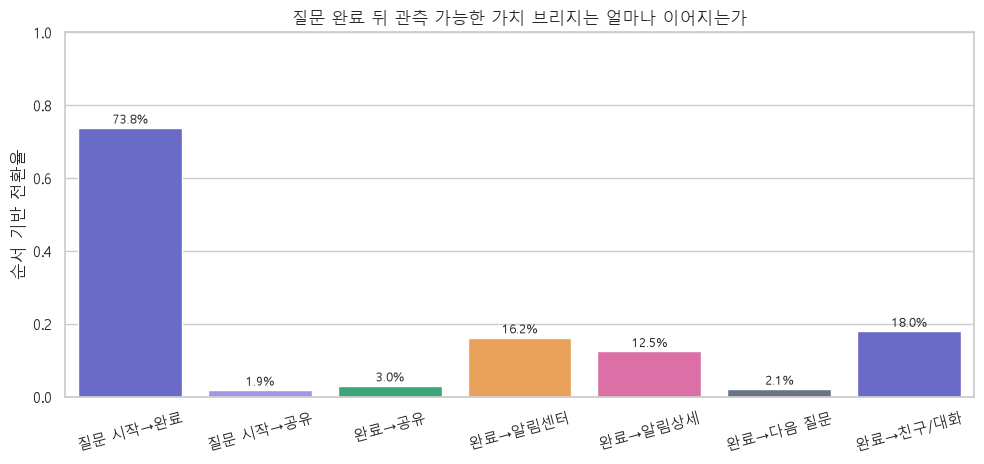

> `click_question_share`를 복원해도 결과·공유·관계 행동은 서로 다른 대리지표다. 공식 `open_ping`이 0건이므로 이 표를 완전한 Ping 가치 루프로 해석하지 않는다.

In [44]:
social_loop=con.execute("""
SELECT * FROM (VALUES
  ('질문 시작→완료',
    (SELECT COUNT(*) FROM visit_order_final_v2 WHERE qcomplete_order IS NOT NULL),
    (SELECT COUNT(*) FROM visit_order_final_v2 WHERE qstart_order IS NOT NULL)),
  ('질문 시작→공유',
    (SELECT COUNT(*) FROM visit_order_final_v2 WHERE first_share_order>qstart_order),
    (SELECT COUNT(*) FROM visit_order_final_v2 WHERE qstart_order IS NOT NULL)),
  ('완료→공유',
    (SELECT COUNT(*) FROM visit_order_final_v2 WHERE share_after_complete=1),
    (SELECT COUNT(*) FROM visit_order_final_v2 WHERE qcomplete_order IS NOT NULL)),
  ('완료→알림센터',
    (SELECT COUNT(*) FROM visit_order_final_v2 WHERE alarm_after_complete=1),
    (SELECT COUNT(*) FROM visit_order_final_v2 WHERE qcomplete_order IS NOT NULL)),
  ('완료→알림상세',
    (SELECT COUNT(*) FROM visit_order_final_v2 WHERE notice_after_complete=1),
    (SELECT COUNT(*) FROM visit_order_final_v2 WHERE qcomplete_order IS NOT NULL)),
  ('완료→다음 질문',
    (SELECT COUNT(*) FROM visit_order_final_v2 WHERE qstart_after_complete=1),
    (SELECT COUNT(*) FROM visit_order_final_v2 WHERE qcomplete_order IS NOT NULL)),
  ('완료→친구/대화',
    (SELECT COUNT(*) FROM visit_order_final_v2 WHERE friend_after_complete=1 OR chat_after_complete=1),
    (SELECT COUNT(*) FROM visit_order_final_v2 WHERE qcomplete_order IS NOT NULL))
) t(transition,numerator,denominator)
""").df()
social_loop['rate']=social_loop.numerator/social_loop.denominator
display(save_table(social_loop,'81_completion_social_loop'))

plt.figure(figsize=(10,4.8))
ax=sns.barplot(data=social_loop,x='transition',y='rate',palette=COLORS+COLORS[:1])
ax.set_ylim(0,1); ax.set_xlabel(''); ax.set_ylabel('순서 기반 전환율')
ax.set_title('질문 완료 뒤 관측 가능한 가치 브리지는 얼마나 이어지는가')
for p,v in zip(ax.patches,social_loop.rate):
    ax.text(p.get_x()+p.get_width()/2,v+.012,f'{v:.1%}',ha='center',fontsize=9)
plt.xticks(rotation=15); savefig('60_completion_social_loop')
display(Markdown('> `click_question_share`를 복원해도 결과·공유·관계 행동은 서로 다른 대리지표다. 공식 `open_ping`이 0건이므로 이 표를 완전한 Ping 가치 루프로 해석하지 않는다.'))

## 20. 첫 방문 활성화와 다음 7일 행동


,activation_stage,users,revisit_7d,next7_question_start,next7_question_complete,next7_notice_detail,next7_friend_action
0,질문 미시작,95546,0.4782,0.1261,0.0913,0.1249,0.0456
1,시작 후 미완료,8133,0.4235,0.1788,0.1371,0.1084,0.0509
2,완료 후 후속행동 없음,9190,0.6055,0.3874,0.3526,0.2091,0.0782
3,완료+다음 질문,13,0.9231,0.6923,0.6923,0.5385,0.2308
4,완료+결과·공유·관계,4538,0.6276,0.4204,0.3825,0.2358,0.1219


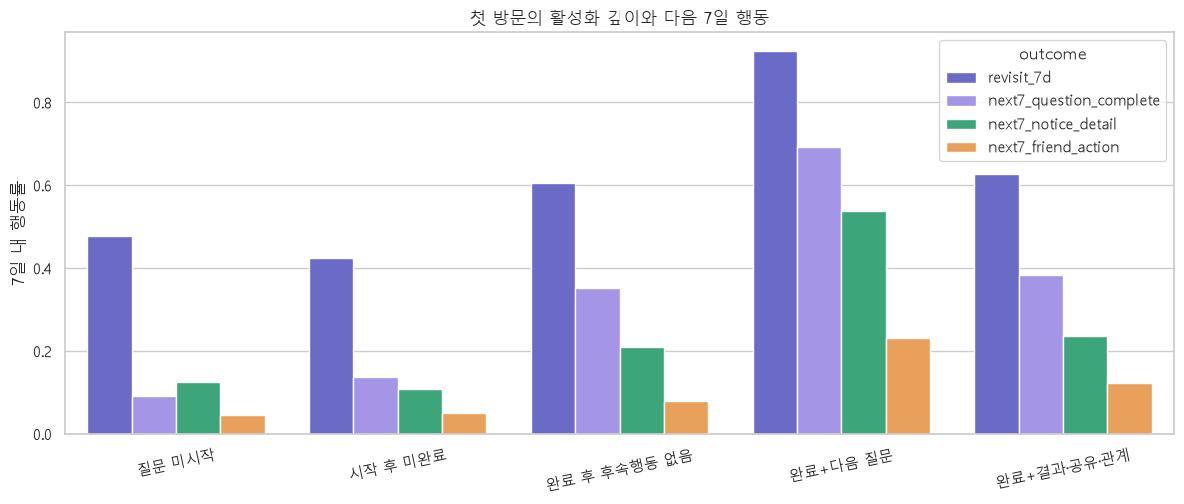

> 단계 간 차이는 제품 루프의 진단 신호다. 활동적인 사용자가 더 깊은 단계까지 갔을 가능성이 있으므로 인과효과로 단정하지 않고, 다음 절에서 완료 이전 상태를 맞춘다.

In [45]:
final_first=con.execute('SELECT * FROM first_visit_final_v2').df()
final_first['activation_stage']=np.select([
  final_first.qstart_order.isna(),
  final_first.qstart_order.notna() & final_first.qcomplete_order.isna(),
  final_first.qcomplete_order.notna() & ((final_first.notice_after_complete==1)|(final_first.alarm_after_complete==1)|(final_first.share_after_complete==1)|(final_first.friend_after_complete==1)|(final_first.chat_after_complete==1)),
  final_first.qcomplete_order.notna() & (final_first.qstart_after_complete==1)
],['질문 미시작','시작 후 미완료','완료+결과·공유·관계','완료+다음 질문'],default='완료 후 후속행동 없음')
stage_order=['질문 미시작','시작 후 미완료','완료 후 후속행동 없음','완료+다음 질문','완료+결과·공유·관계']
stage_outcomes=final_first.groupby('activation_stage').agg(
  users=('user_id','nunique'),revisit_7d=('revisit_7d','mean'),
  next7_question_start=('next7_question_start','mean'),next7_question_complete=('next7_question_complete','mean'),
  next7_notice_detail=('next7_notice_detail','mean'),next7_friend_action=('next7_friend_action','mean')).reindex(stage_order).reset_index()
display(save_table(stage_outcomes,'82_activation_stage_next7d_outcomes'))

stage_long=stage_outcomes.melt(id_vars=['activation_stage','users'],
  value_vars=['revisit_7d','next7_question_complete','next7_notice_detail','next7_friend_action'],
  var_name='outcome',value_name='rate')
plt.figure(figsize=(12,5.2)); sns.barplot(data=stage_long,x='activation_stage',y='rate',hue='outcome',palette=COLORS[:4])
plt.xlabel(''); plt.ylabel('7일 내 행동률'); plt.xticks(rotation=12)
plt.title('첫 방문의 활성화 깊이와 다음 7일 행동')
savefig('61_activation_stage_next7d')
display(Markdown('> 단계 간 차이는 제품 루프의 진단 신호다. 활동적인 사용자가 더 깊은 단계까지 갔을 가능성이 있으므로 인과효과로 단정하지 않고, 다음 절에서 완료 이전 상태를 맞춘다.'))

## 21. 완료 이후 경로와 재방문


,postcomplete_route,users,revisit_7d,next7_question_complete,next7_friend_action,revisit_ci_low,revisit_ci_high
0,기타 이동·종료,9190,0.6055,0.3526,0.0782,0.5955,0.6155
1,다음 질문,13,0.9231,0.6923,0.2308,0.6669,0.9863
2,알림센터까지만,287,0.5331,0.2613,0.0592,0.4753,0.5900
3,알림 상세 도달,1896,0.6013,0.3776,0.1203,0.5790,0.6231
4,질문 공유,224,0.7812,0.5491,0.1384,0.7226,0.8304
5,친구·대화 행동,2131,0.6476,0.3857,0.1300,0.6271,0.6676


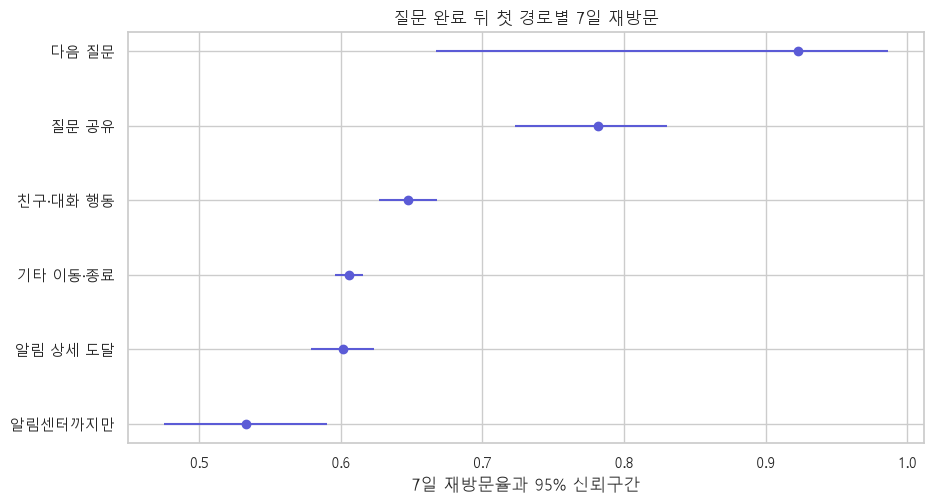

WindowsPath('C:/Users/lucy5/Desktop/team7/analysis/interaction_deep_dive/outputs/figures/62_postcompletion_route_revisit.png')

In [46]:
completed_first=final_first[final_first.qcomplete_order.notna()].copy()
completed_first['postcomplete_route']=np.select([
  completed_first.notice_after_complete.eq(1),
  completed_first.share_after_complete.eq(1),
  completed_first.friend_after_complete.eq(1)|completed_first.chat_after_complete.eq(1),
  completed_first.alarm_after_complete.eq(1),
  completed_first.qstart_after_complete.eq(1)
],['알림 상세 도달','질문 공유','친구·대화 행동','알림센터까지만','다음 질문'],default='기타 이동·종료')
route_order=['기타 이동·종료','다음 질문','알림센터까지만','알림 상세 도달','질문 공유','친구·대화 행동']
route_summary=completed_first.groupby('postcomplete_route').agg(
  users=('user_id','nunique'),revisit_7d=('revisit_7d','mean'),
  next7_question_complete=('next7_question_complete','mean'),
  next7_friend_action=('next7_friend_action','mean')).reindex(route_order).dropna(subset=['users']).reset_index()
z=1.96; n=route_summary.users; p=route_summary.revisit_7d
den=1+z*z/n; center=(p+z*z/(2*n))/den; half=z*np.sqrt(p*(1-p)/n+z*z/(4*n*n))/den
route_summary['revisit_ci_low']=center-half; route_summary['revisit_ci_high']=center+half
display(save_table(route_summary,'83_postcompletion_route_outcomes'))

rp=route_summary.sort_values('revisit_7d')
plt.figure(figsize=(9.5,5.2))
plt.errorbar(rp.revisit_7d,range(len(rp)),
  xerr=[rp.revisit_7d-rp.revisit_ci_low,rp.revisit_ci_high-rp.revisit_7d],fmt='o',color=COLORS[0])
plt.yticks(range(len(rp)),rp.postcomplete_route); plt.xlabel('7일 재방문율과 95% 신뢰구간'); plt.ylabel('')
plt.title('질문 완료 뒤 첫 경로별 7일 재방문')
savefig('62_postcompletion_route_revisit')

## 22. 성향점수 가중 분석

완료 이전의 관측 특성을 맞춘 뒤 질문 완료와 후속 행동의 연관성을 확인한다.


,feature,smd_before,smd_after
0,prestart_event_count,0.0201,0.0105
1,prestart_category_count,-0.0438,-0.0054
2,seconds_to_question_start,0.0749,0.0015
3,signup_tenure_days,-0.1608,-0.0313
4,initial_friend_count,0.0089,-0.0081
5,initial_votes_count,0.0157,-0.0065
6,prestart_browse,-0.0424,-0.0043
7,prestart_alarm,0.0176,-0.0008
8,prestart_notice,0.0675,-0.0005
9,prestart_friend,0.0210,0.0012


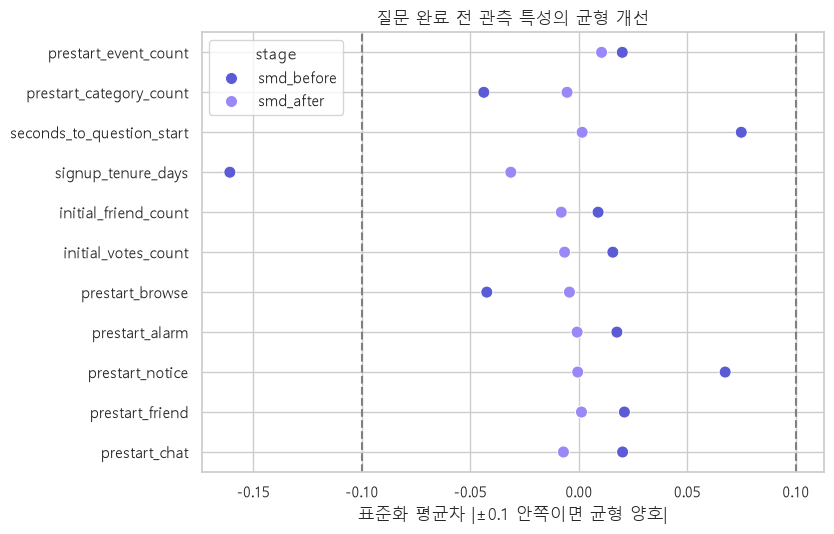

,original_started_visits,common_support_visits,retained_share,completion_rate,propensity_auc,max_abs_smd_before,max_abs_smd_after,effective_sample_size
0,21874,21169,0.9678,0.6261,0.5766,0.1608,0.0313,"20,889.2180"


In [47]:
# 질문을 시작한 첫 방문만 비교한다. 처리변수는 순서상 질문 완료 여부다.
# 완료 이후 이벤트 수·체류시간은 매개변수일 수 있어 성향점수 변수에서 제외한다.
ps=final_first[final_first.qstart_order.notna()].copy()
ps['completed_after_start']=ps.qcomplete_order.notna().astype(int)
ps['seconds_to_question_start']=ps.seconds_to_question_start.clip(lower=0,upper=1800)
ps['signup_tenure_days']=ps.signup_tenure_days.clip(lower=0,upper=3650)
ps_features=['prestart_event_count','prestart_category_count','seconds_to_question_start','signup_tenure_days',
  'initial_friend_count','initial_votes_count','prestart_browse','prestart_alarm','prestart_notice','prestart_friend','prestart_chat']
X=ps[ps_features].replace([np.inf,-np.inf],np.nan).copy()
for c in ps_features:
    X[c]=X[c].fillna(X[c].median() if X[c].notna().any() else 0)
scaler=StandardScaler(); Xs=scaler.fit_transform(X)
propensity_model=LogisticRegression(max_iter=2000,C=1.0,random_state=42)
propensity_model.fit(Xs,ps.completed_after_start)
ps['propensity']=propensity_model.predict_proba(Xs)[:,1]
treated=ps.completed_after_start.eq(1)
lo=max(ps.loc[treated,'propensity'].quantile(.01),ps.loc[~treated,'propensity'].quantile(.01))
hi=min(ps.loc[treated,'propensity'].quantile(.99),ps.loc[~treated,'propensity'].quantile(.99))
ps=ps[ps.propensity.between(lo,hi)].copy()
prevalence=ps.completed_after_start.mean()
ps['iptw']=np.where(ps.completed_after_start.eq(1),prevalence/ps.propensity,(1-prevalence)/(1-ps.propensity))
ps['iptw']=ps.iptw.clip(upper=ps.iptw.quantile(.99))

def weighted_mean_var(values,weights):
    values=np.asarray(values,float); weights=np.asarray(weights,float)
    mean=np.average(values,weights=weights)
    var=np.average((values-mean)**2,weights=weights)
    return mean,var

balance=[]
for c in ps_features:
    a=ps.loc[ps.completed_after_start.eq(1),c].astype(float)
    b=ps.loc[ps.completed_after_start.eq(0),c].astype(float)
    pooled=np.sqrt((a.var()+b.var())/2)
    smd_before=(a.mean()-b.mean())/pooled if pooled>0 else 0
    ma,va=weighted_mean_var(a,ps.loc[ps.completed_after_start.eq(1),'iptw'])
    mb,vb=weighted_mean_var(b,ps.loc[ps.completed_after_start.eq(0),'iptw'])
    pooled_w=np.sqrt((va+vb)/2)
    smd_after=(ma-mb)/pooled_w if pooled_w>0 else 0
    balance.append([c,smd_before,smd_after])
balance=pd.DataFrame(balance,columns=['feature','smd_before','smd_after'])
display(save_table(balance,'84_propensity_balance'))

bal=balance.melt(id_vars='feature',value_vars=['smd_before','smd_after'],var_name='stage',value_name='smd')
plt.figure(figsize=(8.5,5.5)); sns.scatterplot(data=bal,x='smd',y='feature',hue='stage',s=75,palette=COLORS[:2])
plt.axvline(-.1,color='grey',ls='--'); plt.axvline(.1,color='grey',ls='--')
plt.xlabel('표준화 평균차 |±0.1 안쪽이면 균형 양호|'); plt.ylabel(''); plt.title('질문 완료 전 관측 특성의 균형 개선')
savefig('63_propensity_balance')

propensity_diagnostics=pd.DataFrame([{
  'original_started_visits':len(final_first[final_first.qstart_order.notna()]),
  'common_support_visits':len(ps),'retained_share':len(ps)/len(final_first[final_first.qstart_order.notna()]),
  'completion_rate':ps.completed_after_start.mean(),
  'propensity_auc':roc_auc_score(ps.completed_after_start,ps.propensity),
  'max_abs_smd_before':balance.smd_before.abs().max(),
  'max_abs_smd_after':balance.smd_after.abs().max(),
  'effective_sample_size':ps.iptw.sum()**2/(ps.iptw.pow(2).sum())
}])
display(save_table(propensity_diagnostics,'85_propensity_diagnostics'))

,outcome,group,n,weighted_rate
0,revisit_7d,미완료,7916,0.4361
1,revisit_7d,완료,13253,0.5970
2,next7_question_start,미완료,7916,0.1854
3,next7_question_start,완료,13253,0.3782
4,next7_question_complete,미완료,7916,0.1425
5,next7_question_complete,완료,13253,0.3424
6,next7_notice_detail,미완료,7916,0.1102
7,next7_notice_detail,완료,13253,0.2037
8,next7_friend_action,미완료,7916,0.0517
9,next7_friend_action,완료,13253,0.0810


,outcome,weighted_risk_difference,ci_low,ci_high,p_value
0,revisit_7d,0.1609,0.1470,0.1748,0.0000
1,next7_question_start,0.1928,0.1807,0.2049,0.0000
2,next7_question_complete,0.1999,0.1885,0.2113,0.0000
3,next7_notice_detail,0.0935,0.0836,0.1033,0.0000
4,next7_friend_action,0.0293,0.0225,0.0361,0.0000


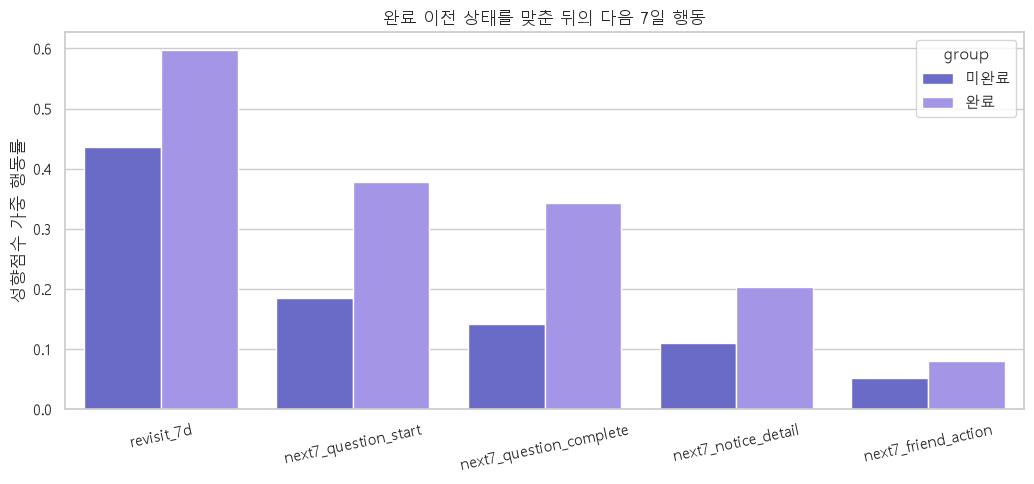

> 성향점수 가중은 관측된 완료 이전 차이를 줄인다. 측정되지 않은 동기·알림 수신·오프라인 친구관계까지 통제하지는 못하므로 최종적으로는 A/B 테스트가 필요하다.

In [48]:
# 가중 위험차: 완료군과 미완료군의 다음 7일 행동률 차이
weighted_results=[]; weighted_rates=[]
outcomes=['revisit_7d','next7_question_start','next7_question_complete','next7_notice_detail','next7_friend_action']
for outcome in outcomes:
    for t,label in [(0,'미완료'),(1,'완료')]:
        g=ps[ps.completed_after_start.eq(t)]
        weighted_rates.append([outcome,label,len(g),np.average(g[outcome],weights=g.iptw)])
    fit=sm.WLS(ps[outcome].astype(float),sm.add_constant(ps.completed_after_start.astype(float)),weights=ps.iptw).fit(cov_type='HC3')
    weighted_results.append([outcome,fit.params['completed_after_start'],fit.conf_int().loc['completed_after_start',0],
      fit.conf_int().loc['completed_after_start',1],fit.pvalues['completed_after_start']])
weighted_rates=pd.DataFrame(weighted_rates,columns=['outcome','group','n','weighted_rate'])
weighted_results=pd.DataFrame(weighted_results,columns=['outcome','weighted_risk_difference','ci_low','ci_high','p_value'])
display(save_table(weighted_rates,'86_iptw_weighted_outcome_rates'))
display(save_table(weighted_results,'87_iptw_completion_next7d_effects'))

plt.figure(figsize=(10.5,5)); sns.barplot(data=weighted_rates,x='outcome',y='weighted_rate',hue='group',palette=COLORS[:2])
plt.xlabel(''); plt.ylabel('성향점수 가중 행동률'); plt.xticks(rotation=12)
plt.title('완료 이전 상태를 맞춘 뒤의 다음 7일 행동')
savefig('64_iptw_completion_next7d')
display(Markdown('> 성향점수 가중은 관측된 완료 이전 차이를 줄인다. 측정되지 않은 동기·알림 수신·오프라인 친구관계까지 통제하지는 못하므로 최종적으로는 A/B 테스트가 필요하다.'))

## 23. 방문 회차별 행동 구조

Hackle 관찰창 안에서 반복 관측된 방문의 행동 구성을 비교한다.


,visit_band,visits,users,median_events,question_start_rate,question_complete_rate,question_skip_rate,notice_detail_rate,friend_action_rate
0,1회,140663,140663,10.0000,0.1888,0.1159,0.0830,0.2136,0.0526
1,2회,80559,80559,7.0000,0.1925,0.1353,0.0978,0.1676,0.0474
2,3회,52683,52683,7.0000,0.2056,0.1522,0.1098,0.1382,0.0473
3,4~5회,66433,37647,7.0000,0.2274,0.1764,0.1284,0.1139,0.0451
4,6~10회,84739,23003,6.0000,0.2556,0.2046,0.1494,0.0939,0.0403
5,11회 이상,201910,11032,6.0000,0.3259,0.2770,0.2121,0.0922,0.0325


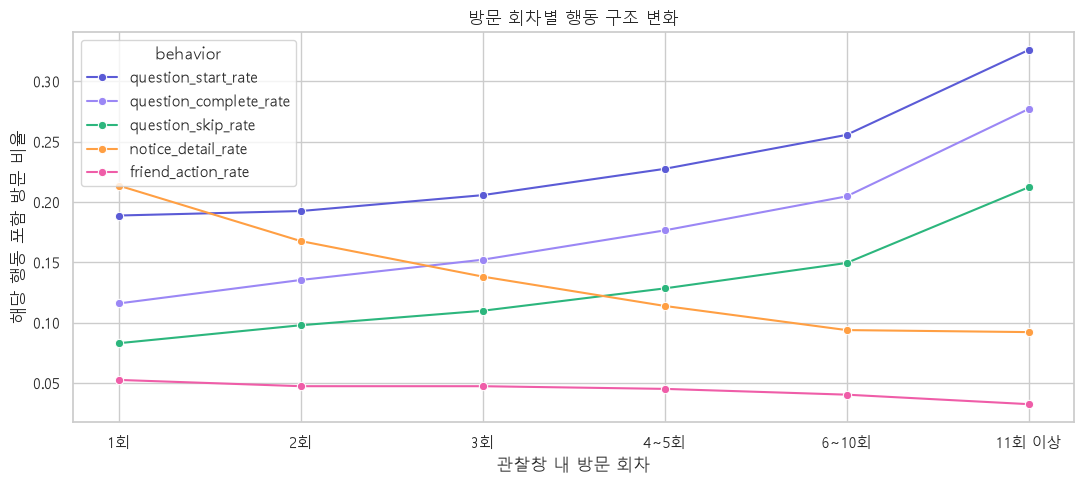

> 첫 방문은 사용자의 생애 첫 방문이 아니라 Hackle 관찰창에서 처음 보인 방문이다. 따라서 온보딩의 순수 효과가 아니라 관찰 초기와 반복 방문의 차이로 해석한다.

In [49]:
lifecycle=visit_ordered.copy()
lifecycle['visit_band']=pd.cut(lifecycle.observed_visit_no,[0,1,2,3,5,10,np.inf],
  labels=['1회','2회','3회','4~5회','6~10회','11회 이상'])
lifecycle_summary=lifecycle.groupby('visit_band',observed=True).agg(
  visits=('visit_id','nunique'),users=('user_id','nunique'),median_events=('event_count','median'),
  question_start_rate=('question_start_flag','mean'),question_complete_rate=('question_complete_flag','mean'),
  question_skip_rate=('question_skip_flag','mean'),notice_detail_rate=('notice_detail_flag','mean'),
  friend_action_rate=('friend_flag','mean')).reset_index()
display(save_table(lifecycle_summary,'88_behavior_by_visit_number'))
life_long=lifecycle_summary.melt(id_vars=['visit_band','visits','users'],
  value_vars=['question_start_rate','question_complete_rate','question_skip_rate','notice_detail_rate','friend_action_rate'],
  var_name='behavior',value_name='rate')
plt.figure(figsize=(11,5)); sns.lineplot(data=life_long,x='visit_band',y='rate',hue='behavior',marker='o',palette=COLORS[:5])
plt.xlabel('관찰창 내 방문 회차'); plt.ylabel('해당 행동 포함 방문 비율'); plt.title('방문 회차별 행동 구조 변화')
savefig('65_behavior_by_visit_number')
display(Markdown('> 첫 방문은 사용자의 생애 첫 방문이 아니라 Hackle 관찰창에서 처음 보인 방문이다. 따라서 온보딩의 순수 효과가 아니라 관찰 초기와 반복 방문의 차이로 해석한다.'))

## 24. 학교·날짜별 강건성


,school_id,visits,start_visits,complete_after_start_visits,notice_after_complete_visits,share_after_start_visits,complete_given_start,notice_given_complete,share_given_start,school_alias
0,4867,4336,2120,1903,580,181,0.8976,0.3048,0.0854,학교 1
1,47,3963,1969,1712,669,193,0.8695,0.3908,0.0980,학교 2
2,400,3830,1704,1450,183,45,0.8509,0.1262,0.0264,학교 3
3,215,3523,1616,1403,536,195,0.8682,0.3820,0.1207,학교 4
4,636,2058,1123,970,177,15,0.8638,0.1825,0.0134,학교 5
5,418,2189,1017,885,49,4,0.8702,0.0554,0.0039,학교 6
6,4030,1755,894,824,35,1,0.9217,0.0425,0.0011,학교 7
7,3829,2189,871,806,159,75,0.9254,0.1973,0.0861,학교 8
8,3592,1901,834,691,146,53,0.8285,0.2113,0.0635,학교 9
9,196,1748,767,675,56,1,0.8801,0.0830,0.0013,학교 10


,metric,schools,weighted_rate,min_rate,median_rate,max_rate,i2
0,시작→완료,24,0.8708,0.7677,0.8751,0.9254,0.9019
1,완료→알림상세,24,0.1939,0.0404,0.1415,0.3908,0.9881
2,시작→공유,24,0.0466,0.0000,0.0286,0.1207,0.9790


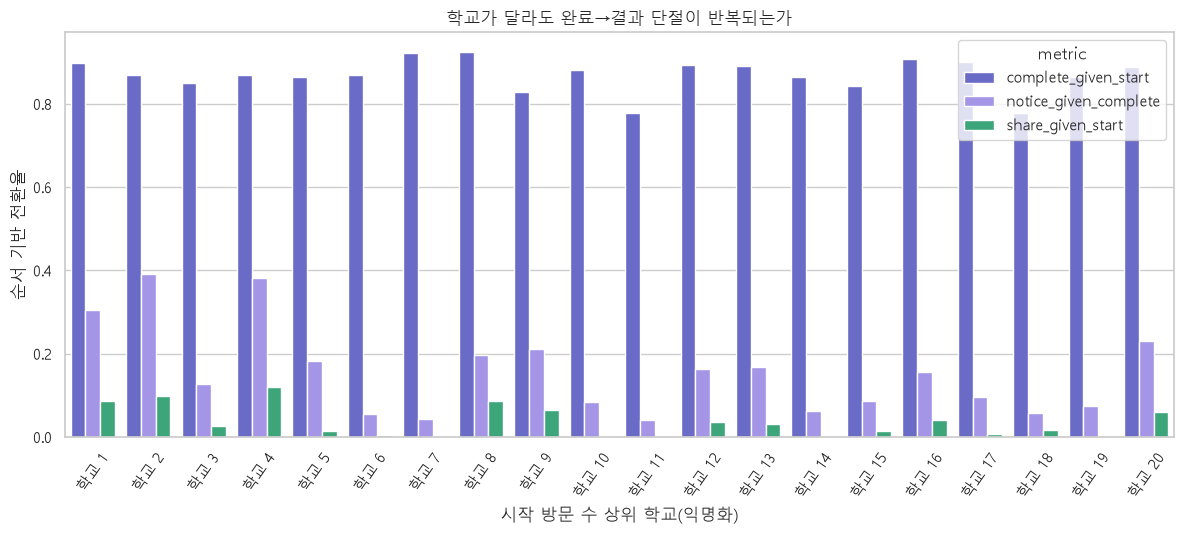

WindowsPath('C:/Users/lucy5/Desktop/team7/analysis/interaction_deep_dive/outputs/figures/66_school_flow_robustness.png')

In [50]:
school_flow=con.execute("""
SELECT v.school_id,COUNT(*) visits,
       COUNT(*) FILTER(WHERE o.qstart_order IS NOT NULL) start_visits,
       COUNT(*) FILTER(WHERE o.qcomplete_order IS NOT NULL) complete_after_start_visits,
       COUNT(*) FILTER(WHERE o.notice_after_complete=1) notice_after_complete_visits,
       COUNT(*) FILTER(WHERE o.first_share_order>o.qstart_order) share_after_start_visits
FROM hackle_visit_interaction v JOIN visit_order_final_v2 o USING(visit_id)
WHERE v.school_id IS NOT NULL AND TRIM(v.school_id)<>''
GROUP BY 1 HAVING COUNT(*) FILTER(WHERE o.qstart_order IS NOT NULL)>=500
ORDER BY start_visits DESC
""").df()
school_flow['complete_given_start']=school_flow.complete_after_start_visits/school_flow.start_visits
school_flow['notice_given_complete']=school_flow.notice_after_complete_visits/school_flow.complete_after_start_visits
school_flow['share_given_start']=school_flow.share_after_start_visits/school_flow.start_visits
school_flow['school_alias']=['학교 '+str(i+1) for i in range(len(school_flow))]
display(save_table(school_flow,'89_school_flow_robustness'))

def heterogeneity_row(df,rate_col,n_col,label):
    p=df[rate_col].clip(1e-6,1-1e-6); n=df[n_col].clip(lower=1)
    var=p*(1-p)/n; w=1/var
    pooled=np.average(p,weights=n)
    q=np.sum(w*(p-np.average(p,weights=w))**2); dfree=max(len(df)-1,1)
    i2=max(0,(q-dfree)/q) if q>0 else 0
    return [label,len(df),pooled,p.min(),p.median(),p.max(),i2]
heterogeneity=pd.DataFrame([
  heterogeneity_row(school_flow,'complete_given_start','start_visits','시작→완료'),
  heterogeneity_row(school_flow,'notice_given_complete','complete_after_start_visits','완료→알림상세'),
  heterogeneity_row(school_flow,'share_given_start','start_visits','시작→공유')
],columns=['metric','schools','weighted_rate','min_rate','median_rate','max_rate','i2'])
display(save_table(heterogeneity,'90_school_flow_heterogeneity'))

top_school=school_flow.head(20).copy()
sf=top_school.melt(id_vars=['school_alias','start_visits'],
  value_vars=['complete_given_start','notice_given_complete','share_given_start'],var_name='metric',value_name='rate')
plt.figure(figsize=(12,5.5)); sns.barplot(data=sf,x='school_alias',y='rate',hue='metric',palette=COLORS[:3])
plt.xlabel('시작 방문 수 상위 학교(익명화)'); plt.ylabel('순서 기반 전환율'); plt.xticks(rotation=55)
plt.title('학교가 달라도 완료→결과 단절이 반복되는가')
savefig('66_school_flow_robustness')

,visit_date,visits,start_visits,complete_after_start_visits,notice_after_complete_visits,share_after_start_visits,complete_given_start,notice_given_complete,share_given_start
0,2023-07-18,54479,12163,9192,1530,363,0.7557,0.1664,0.0298
1,2023-07-19,43666,10806,8338,1103,289,0.7716,0.1323,0.0267
2,2023-07-20,57418,13543,10054,1520,298,0.7424,0.1512,0.0220
3,2023-07-21,59061,13735,10182,1451,285,0.7413,0.1425,0.0207
4,2023-07-22,40433,9465,7458,832,212,0.7880,0.1116,0.0224
5,2023-07-23,50034,11846,8843,1111,226,0.7465,0.1256,0.0191
6,2023-07-24,37569,8978,6854,731,163,0.7634,0.1067,0.0182
7,2023-07-25,33426,8136,6255,694,162,0.7688,0.1110,0.0199
8,2023-07-26,31204,7466,5691,627,154,0.7623,0.1102,0.0206
9,2023-07-27,44953,9560,6787,913,182,0.7099,0.1345,0.0190


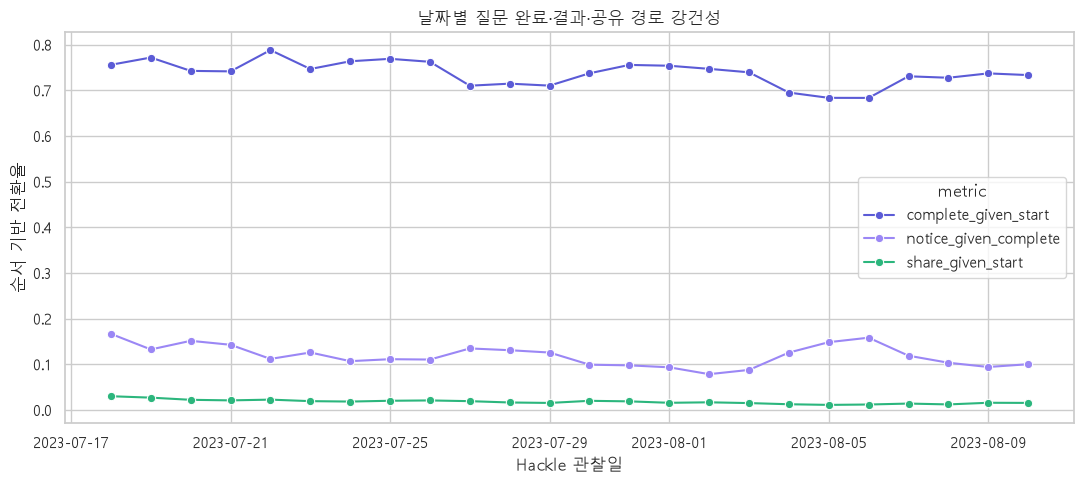

WindowsPath('C:/Users/lucy5/Desktop/team7/analysis/interaction_deep_dive/outputs/figures/67_daily_flow_robustness.png')

In [51]:
daily_flow=con.execute("""
SELECT v.visit_date,COUNT(*) visits,
       COUNT(*) FILTER(WHERE o.qstart_order IS NOT NULL) start_visits,
       COUNT(*) FILTER(WHERE o.qcomplete_order IS NOT NULL) complete_after_start_visits,
       COUNT(*) FILTER(WHERE o.notice_after_complete=1) notice_after_complete_visits,
       COUNT(*) FILTER(WHERE o.first_share_order>o.qstart_order) share_after_start_visits
FROM hackle_visit_interaction v JOIN visit_order_final_v2 o USING(visit_id)
GROUP BY 1 HAVING COUNT(*) FILTER(WHERE o.qstart_order IS NOT NULL)>=500 ORDER BY 1
""").df()
daily_flow['complete_given_start']=daily_flow.complete_after_start_visits/daily_flow.start_visits
daily_flow['notice_given_complete']=daily_flow.notice_after_complete_visits/daily_flow.complete_after_start_visits
daily_flow['share_given_start']=daily_flow.share_after_start_visits/daily_flow.start_visits
display(save_table(daily_flow,'91_daily_flow_robustness'))
dl=daily_flow.melt(id_vars=['visit_date','start_visits'],
  value_vars=['complete_given_start','notice_given_complete','share_given_start'],var_name='metric',value_name='rate')
plt.figure(figsize=(11,5)); sns.lineplot(data=dl,x='visit_date',y='rate',hue='metric',marker='o',palette=COLORS[:3])
plt.xlabel('Hackle 관찰일'); plt.ylabel('순서 기반 전환율'); plt.title('날짜별 질문 완료·결과·공유 경로 강건성')
savefig('67_daily_flow_robustness')

## 25. 활성화 단계별 재방문 시간


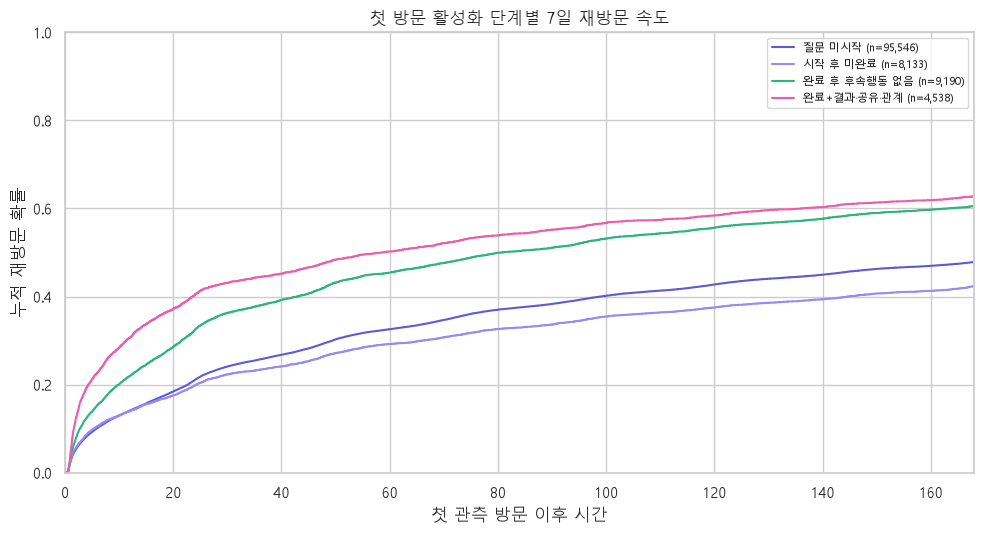

,activation_stage,users,revisit_7d,median_hours_among_returners
0,질문 미시작,95546,0.4782,29.4614
1,시작 후 미완료,8133,0.4235,26.3982
2,완료 후 후속행동 없음,9190,0.6055,21.7917
3,완료+결과·공유·관계,4538,0.6276,12.5497


In [52]:
survival_final=final_first.copy()
survival_final['hours_to_next']=(survival_final.next_visit_start-survival_final.visit_start).dt.total_seconds()/3600
survival_final['event_7d']=(survival_final.hours_to_next<=168).astype(int)
survival_final['follow_hours']=np.where(survival_final.event_7d.eq(1),survival_final.hours_to_next,168)
plt.figure(figsize=(10,5.5))
survival_rates=[]
for stage,color in zip(stage_order,COLORS[:5]):
    g=survival_final[survival_final.activation_stage.eq(stage)]
    if len(g)<100: continue
    km=km_curve(g.follow_hours,g.event_7d,max_hours=168)
    plt.step(km.hours,1-km.survival,where='post',label=f'{stage} (n={len(g):,})',color=color)
    survival_rates.append([stage,len(g),g.event_7d.mean(),g.loc[g.event_7d.eq(1),'hours_to_next'].median()])
plt.xlim(0,168); plt.ylim(0,1); plt.xlabel('첫 관측 방문 이후 시간'); plt.ylabel('누적 재방문 확률')
plt.title('첫 방문 활성화 단계별 7일 재방문 속도'); plt.legend(fontsize=8)
savefig('68_activation_stage_revisit_survival')
survival_rates=pd.DataFrame(survival_rates,columns=['activation_stage','users','revisit_7d','median_hours_among_returners'])
display(save_table(survival_rates,'92_activation_stage_survival_summary'))

## 26. 관측 병목과 실험 규모


,scenario,assumed_notice_given_complete,result_reaches_per_10k_starts,additional_vs_current
0,현재 관측,0.1245,918.5340,0.0000
1,완료→결과 15%,0.1500,"1,106.3235",187.7895
2,완료→결과 20%,0.2000,"1,475.0980",556.5640
3,완료→결과 30%,0.3000,"2,212.6470","1,294.1130"


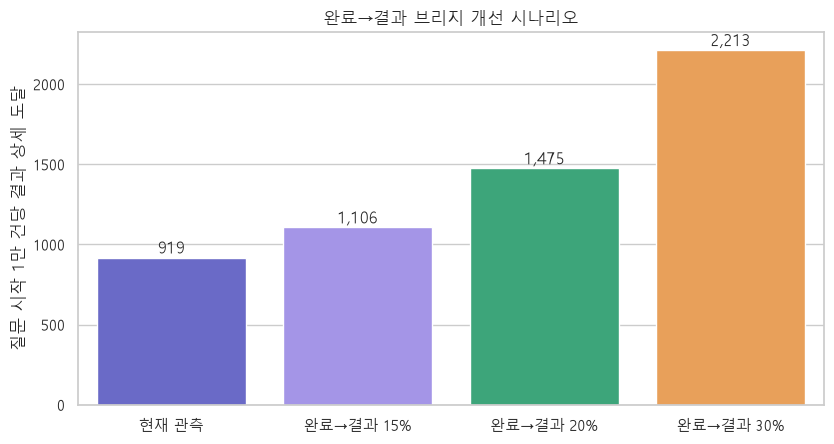

> 이 그래프는 예측된 리텐션 효과가 아니라 현재 완료율을 고정한 단순 운영 시나리오다. 실제 효과는 완료 화면 결과 카드·반응 CTA 실험으로 검증해야 한다.

In [53]:
start_n=int(social_loop.loc[social_loop.transition.eq('질문 시작→완료'),'denominator'].iloc[0])
complete_rate=float(social_loop.loc[social_loop.transition.eq('질문 시작→완료'),'rate'].iloc[0])
notice_rate=float(social_loop.loc[social_loop.transition.eq('완료→알림상세'),'rate'].iloc[0])
scenarios=pd.DataFrame({'scenario':['현재 관측','완료→결과 15%','완료→결과 20%','완료→결과 30%'],
  'assumed_notice_given_complete':[notice_rate,.15,.20,.30]})
scenarios['result_reaches_per_10k_starts']=10000*complete_rate*scenarios.assumed_notice_given_complete
scenarios['additional_vs_current']=scenarios.result_reaches_per_10k_starts-scenarios.result_reaches_per_10k_starts.iloc[0]
display(save_table(scenarios,'93_result_bridge_scenario'))
plt.figure(figsize=(8.5,4.6)); ax=sns.barplot(data=scenarios,x='scenario',y='result_reaches_per_10k_starts',palette=COLORS[:4])
plt.xlabel(''); plt.ylabel('질문 시작 1만 건당 결과 상세 도달'); plt.title('완료→결과 브리지 개선 시나리오')
for p,v in zip(ax.patches,scenarios.result_reaches_per_10k_starts):
    ax.text(p.get_x()+p.get_width()/2,v+25,f'{v:,.0f}',ha='center')
savefig('69_result_bridge_scenario')
display(Markdown('> 이 그래프는 예측된 리텐션 효과가 아니라 현재 완료율을 고정한 단순 운영 시나리오다. 실제 효과는 완료 화면 결과 카드·반응 CTA 실험으로 검증해야 한다.'))

## 27. 근거와 실험 우선순위


In [54]:
iptw_revisit=weighted_results.loc[weighted_results.outcome.eq('revisit_7d')].iloc[0]
iptw_next_complete=weighted_results.loc[weighted_results.outcome.eq('next7_question_complete')].iloc[0]
share_row=social_loop.loc[social_loop.transition.eq('완료→공유')].iloc[0]
notice_row=social_loop.loc[social_loop.transition.eq('완료→알림상세')].iloc[0]
final_evidence=pd.DataFrame([
  ['완료 이후 결과 브리지',f'순서 기반 완료→알림상세 {notice_row.rate:.1%}','완료 화면에서 결과를 바로 보여주고 알림센터 우회를 줄이는 실험','최우선'],
  ['공유 루프',f'완료→질문공유 {share_row.rate:.1%}','결과 카드 공유와 공유 후 친구 반응을 하나의 추적 가능한 루프로 연결','최우선'],
  ['다음 방문 연관',f'완료 이전 상태 가중 후 7일 재방문 위험차 {iptw_revisit.weighted_risk_difference*100:+.1f}%p','질문 완료 여부가 아니라 완료 뒤 결과·반응 경험을 무작위 실험','최우선'],
  ['다음 방문의 질',f'가중 후 다음 7일 질문완료 위험차 {iptw_next_complete.weighted_risk_difference*100:+.1f}%p','재방문 KPI와 다음 질문완료 KPI를 함께 사용','높음'],
  ['반복 방문 설계','방문 회차별 질문·결과·관계 행동 구조가 다름','첫 관측 방문과 반복 방문의 홈·CTA·콘텐츠를 분리','높음'],
  ['학교 강건성',f'{len(school_flow):,}개 충분표본 학교에서 전환 경로 재검증','학교별 별도 제품보다 공통 병목을 먼저 고치고 편차 큰 학교만 후속 진단','높음'],
  ['계측 공백','공식 open_ping 0건','question_set_id·question_piece_id·result_id·notification_id를 공통 키로 저장','필수']
],columns=['evidence','result','product_test_or_decision','priority'])
display(save_table(final_evidence,'94_final_evidence_and_experiments'))

final_qa=pd.DataFrame([
  ['기존 셀 보존',True,'G 절만 하단에 추가'],
  ['질문 공유 이벤트 복원',True,'click_question_share 99_기타에서 별도 추출'],
  ['순서 기반 완료·후속 행동',True,'event_order로 시작<완료<후속행동 확인'],
  ['다음 7일 행동의 질',True,'재방문·질문시작·질문완료·알림상세·친구행동'],
  ['성향점수 공통지지영역',bool(len(ps)>0 and propensity_diagnostics.retained_share.iloc[0]>.5),'완료 이전 변수만 사용'],
  ['가중 후 균형 확인',bool(balance.smd_after.abs().max()<.25),'절대 SMD 점검'],
  ['학교 강건성',bool(len(school_flow)>=3),'학교별 시작 방문 500건 이상'],
  ['날짜 강건성',bool(len(daily_flow)>=7),'일별 시작 방문 500건 이상'],
  ['우측 검열',True,'7일 관찰 가능한 첫 방문만 사용'],
  ['Ping 과대해석 방지',True,'알림 상세는 대리경로로만 사용'],
  ['인과 경계',True,'관찰 연관과 A/B 테스트 분리'],
  ['표·차트 저장',True,'80~94 표, 60~69 차트']
],columns=['check','pass','evidence'])
display(save_table(final_qa,'95_final_extension_qa'))
assert final_qa['pass'].all(), final_qa.loc[~final_qa['pass']]
print(f'FINAL EXTENSION QA: PASS {final_qa["pass"].sum()} / FAIL 0')
print(f'누적 표 {len(list(TABLE.glob("*.csv")))}개 / 누적 차트 {len(list(FIG.glob("*.png")))}개')

,evidence,result,product_test_or_decision,priority
0,완료 이후 결과 브리지,순서 기반 완료→알림상세 12.5%,완료 화면에서 결과를 바로 보여주고 알림센터 우회를 줄이는 실험,최우선
1,공유 루프,완료→질문공유 3.0%,결과 카드 공유와 공유 후 친구 반응을 하나의 추적 가능한 루프로 연결,최우선
2,다음 방문 연관,완료 이전 상태 가중 후 7일 재방문 위험차 +16.1%p,질문 완료 여부가 아니라 완료 뒤 결과·반응 경험을 무작위 실험,최우선
3,다음 방문의 질,가중 후 다음 7일 질문완료 위험차 +20.0%p,재방문 KPI와 다음 질문완료 KPI를 함께 사용,높음
4,반복 방문 설계,방문 회차별 질문·결과·관계 행동 구조가 다름,첫 관측 방문과 반복 방문의 홈·CTA·콘텐츠를 분리,높음
5,학교 강건성,24개 충분표본 학교에서 전환 경로 재검증,학교별 별도 제품보다 공통 병목을 먼저 고치고 편차 큰 학교만 후속 진단,높음
6,계측 공백,공식 open_ping 0건,question_set_id·question_piece_id·result_id·no...,필수


,check,pass,evidence
0,기존 셀 보존,True,G 절만 하단에 추가
1,질문 공유 이벤트 복원,True,click_question_share 99_기타에서 별도 추출
2,순서 기반 완료·후속 행동,True,event_order로 시작<완료<후속행동 확인
3,다음 7일 행동의 질,True,재방문·질문시작·질문완료·알림상세·친구행동
4,성향점수 공통지지영역,True,완료 이전 변수만 사용
5,가중 후 균형 확인,True,절대 SMD 점검
6,학교 강건성,True,학교별 시작 방문 500건 이상
7,날짜 강건성,True,일별 시작 방문 500건 이상
8,우측 검열,True,7일 관찰 가능한 첫 방문만 사용
9,Ping 과대해석 방지,True,알림 상세는 대리경로로만 사용


FINAL EXTENSION QA: PASS 12 / FAIL 0
누적 표 69개 / 누적 차트 39개
